# Chương 3 — Text Classification & Sentiment Analysis
Notebook này được thiết kế để sinh viên thực hành xây dựng và so sánh nhiều hệ thống phân loại văn bản:

1. **Rule-based baseline**
2. **TF-IDF + Multinomial Naive Bayes**
3. **TF-IDF + Logistic Regression**
4. **TF-IDF + Linear SVM**
5. **Decision Tree / Random Forest** ở mức tham khảo
6. **Lexicon-based Sentiment Analysis**
7. **PhoBERT / ViSoBERT** ở mức mở rộng

### Mục tiêu
Sinh viên phải trả lời được:

- Văn bản được biến thành vector như thế nào?
- Vì sao TF-IDF thường mạnh hơn Bag of Words thô?
- Naive Bayes, Logistic Regression và SVM khác nhau ra sao?
- Accuracy có đủ để đánh giá mô hình không?
- Khi dữ liệu mất cân bằng nên dùng metric nào?
- Vì sao sentiment analysis khó với phủ định, sarcasm, emoji và domain shift?
- Mô hình pretrained cải thiện điểm gì và đánh đổi điều gì?

> Notebook có dữ liệu demo nhỏ nhúng sẵn để chạy độc lập. Tuy nhiên, khi thực hiện bài thực hành sinh viên cần thay bằng UIT-VSFC, UIT-VSMEC hoặc dữ liệu tương đương.

# KHÔNG ĐƯỢC CHẠY LẠI (Không Run All)

# 0. Chuẩn bị môi trường

Notebook dùng các thư viện phổ biến:
- pandas
- numpy
- scikit-learn
- matplotlib


In [16]:
import re
import time
import math
import random
import unicodedata
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer, HashingVectorizer
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
print("Environment ready.")

Environment ready.


# 1. Dữ liệu mẫu

Ta dùng một dataset nhỏ gồm:
- `text`: câu tiếng Việt
- `sentiment`: `positive / negative / neutral`
- `topic`: `teaching / facility / administration / technology`

Mục đích:
- sentiment → bài toán **multiclass classification**
- topic → một bài toán classification khác trên cùng văn bản
- về sau có thể mở rộng thành multilabel.

In [17]:
positive_templates = [
    ("Giảng viên dạy rất dễ hiểu và nhiệt tình", "teaching"),
    ("Bài giảng rõ ràng, ví dụ thực tế rất hữu ích", "teaching"),
    ("Phòng học sạch sẽ và máy lạnh hoạt động tốt", "facility"),
    ("Thư viện rộng, yên tĩnh và có nhiều tài liệu", "facility"),
    ("Phòng đào tạo hỗ trợ sinh viên rất nhanh", "administration"),
    ("Thủ tục đăng ký môn học khá thuận tiện", "administration"),
    ("Hệ thống học trực tuyến chạy ổn định và dễ sử dụng", "technology"),
    ("Website mới nhanh hơn và ít lỗi hơn trước", "technology"),
    ("Mình rất hài lòng với môn học này", "teaching"),
    ("Wifi trong trường hôm nay rất tốt", "technology"),
]

negative_templates = [
    ("Giảng viên giảng quá nhanh nên tôi không theo kịp", "teaching"),
    ("Bài tập quá nhiều nhưng hướng dẫn chưa rõ", "teaching"),
    ("Phòng học nóng và máy lạnh thường xuyên hỏng", "facility"),
    ("Nhà vệ sinh chưa sạch và thiếu giấy", "facility"),
    ("Phòng đào tạo xử lý hồ sơ quá chậm", "administration"),
    ("Thủ tục đăng ký rườm rà và mất nhiều thời gian", "administration"),
    ("Website thường xuyên lỗi khi đăng ký môn học", "technology"),
    ("Hệ thống học trực tuyến rất chậm và hay bị treo", "technology"),
    ("Tôi không hài lòng với cách tổ chức lớp", "teaching"),
    ("Wifi yếu, kết nối chập chờn cả buổi", "technology"),
]

neutral_templates = [
    ("Môn học có ba tín chỉ và học vào thứ hai", "teaching"),
    ("Giảng viên đăng tài liệu lên hệ thống mỗi tuần", "teaching"),
    ("Phòng học nằm ở tầng ba của tòa nhà", "facility"),
    ("Thư viện mở cửa từ sáng đến tối", "facility"),
    ("Phòng đào tạo tiếp nhận hồ sơ tại quầy số hai", "administration"),
    ("Sinh viên đăng ký môn học qua cổng thông tin", "administration"),
    ("Hệ thống học trực tuyến có phiên bản web", "technology"),
    ("Website yêu cầu đăng nhập bằng tài khoản sinh viên", "technology"),
    ("Lớp có khoảng bốn mươi sinh viên", "teaching"),
    ("Trường có nhiều điểm phát wifi", "technology"),
]

augment_prefix = [
    "", "Theo mình, ", "Cá nhân mình thấy ", "Hôm nay ", "Trong học kỳ này, "
]
augment_suffix = [
    "", ".", "!", " :)", " 👍", " 😐"
]

rows = []
for sentiment, templates in [
    ("positive", positive_templates),
    ("negative", negative_templates),
    ("neutral", neutral_templates),
]:
    for base, topic in templates:
        for i in range(4):
            text = random.choice(augment_prefix) + base + random.choice(augment_suffix)
            rows.append((text, sentiment, topic))

df = pd.DataFrame(rows, columns=["text", "sentiment", "topic"])
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(df.shape)
display(df.head(10))
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())
print("\nTopic distribution:")
print(df["topic"].value_counts())

(120, 3)


,text,sentiment,topic
0,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,negative,teaching
1,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,negative,teaching
2,"Trong học kỳ này, Bài giảng rõ ràng, ví dụ thự...",positive,teaching
3,Cá nhân mình thấy Nhà vệ sinh chưa sạch và thi...,negative,facility
4,Cá nhân mình thấy Hệ thống học trực tuyến chạy...,positive,technology
5,Hôm nay Website thường xuyên lỗi khi đăng ký m...,negative,technology
6,Cá nhân mình thấy Tôi không hài lòng với cách ...,negative,teaching
7,"Trong học kỳ này, Phòng học sạch sẽ và máy lạn...",positive,facility
8,"Theo mình, Giảng viên giảng quá nhanh nên tôi ...",negative,teaching
9,"Theo mình, Hệ thống học trực tuyến có phiên bả...",neutral,technology



Sentiment distribution:
sentiment
negative    40
positive    40
neutral     40
Name: count, dtype: int64

Topic distribution:
topic
teaching          36
technology        36
facility          24
administration    24
Name: count, dtype: int64


## Task 1 — Bài toán phân loại

### Code mẫu
- sentiment: **multiclass** với 3 nhãn.
- topic: **multiclass** với 4 nhãn.

### Yêu cầu sinh viên
1. Chuyển một phần dữ liệu thành **binary classification**: positive vs non-positive.
2. Thiết kế một ví dụ **multilabel**: một phản hồi có thể vừa nói về `teaching` vừa nói về `facility`.
3. Đề xuất một taxonomy **hierarchical classification**:
   - `academic`
     - teaching
     - curriculum
   - `service`
     - administration
     - facility
4. Giải thích khác biệt giữa:
   - text classification,
   - sequence labeling.

### TODO

In [18]:
from pathlib import Path

DATA_DIR = Path("data")
DATA_FILES = {"train": DATA_DIR / "train.xlsx",
              "validation": DATA_DIR / "valid.xlsx",
              "test": DATA_DIR / "test.xlsx"}

EXPECTED_EMOTIONS = {"Anger", "Disgust", "Enjoyment", "Fear",
                     "Other", "Sadness", "Surprise"}
POSITIVE_EMOTIONS = {"Enjoyment"}

def load_emotion_split(file_path, split_name):
    #Đọc một split và chỉ giữ các cột có ý nghĩa cho bài toán
    raw_data = pd.read_excel(file_path)
    required_columns = {"Emotion", "Sentence"}
    missing_columns = required_columns - set(raw_data.columns)
    if missing_columns:
        raise ValueError(f"{file_path.name} thiếu cột: {sorted(missing_columns)}")

    data = (raw_data.loc[:, ["Emotion", "Sentence"]].rename(columns={"Emotion": "emotion", "Sentence": "text"}).copy())
    if data.isna().any().any():
        raise ValueError(f"{file_path.name} có giá trị thiếu.")
    # Kiểm tra xem coi có cảm xúc lạ không
    unknown_emotions = set(data["emotion"].unique()) - EXPECTED_EMOTIONS
    if unknown_emotions:
        raise ValueError(f"{file_path.name} có nhãn lạ: {sorted(unknown_emotions)}")
    data.insert(0, "split", split_name)
    return data

emotion_splits = {split_name: load_emotion_split(file_path, split_name)
    for split_name, file_path in DATA_FILES.items()}
for split_name, split_data in emotion_splits.items():
    print(f"{split_name}: {len(split_data)} câu")

train: 5548 câu
validation: 686 câu
test: 693 câu


In [19]:
# TODO 1: tạo cột binary_sentiment
df["binary_sentiment"] = df["sentiment"].apply(
    lambda x: "positive" if x == "positive" else "non_positive")

display(df[["text", "sentiment", "binary_sentiment"]].head())

,text,sentiment,binary_sentiment
0,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,negative,non_positive
1,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,negative,non_positive
2,"Trong học kỳ này, Bài giảng rõ ràng, ví dụ thự...",positive,positive
3,Cá nhân mình thấy Nhà vệ sinh chưa sạch và thi...,negative,non_positive
4,Cá nhân mình thấy Hệ thống học trực tuyến chạy...,positive,positive


**1. Chuyển một phần dữ liệu thành **binary classification**: positive vs non-positive.**

In [20]:
def add_binary_sentiment(data):
    #Ánh xạ Enjoyment thành positive, các cảm xúc khác thành non_positive
    result = data.copy()
    is_positive = result["emotion"].isin(POSITIVE_EMOTIONS)
    result["binary_sentiment"] = np.where(is_positive, "positive", "non_positive")
    return result

task1_splits = {split_name: add_binary_sentiment(split_data)
                for split_name, split_data in emotion_splits.items()}

task1_train = task1_splits["train"]
task1_validation = task1_splits["validation"]
task1_test = task1_splits["test"]

for split_name in ["train", "validation", "test"]:
    print(f"\nCác câu trong tập {split_name}:")
    display(task1_splits[split_name][["text", "emotion", "binary_sentiment"]].head(10))

task1_all = pd.concat(task1_splits.values(), ignore_index=True)
binary_distribution = (task1_all.groupby(["split", "binary_sentiment"], observed=True).size().rename("count").reset_index())
print("\nPhân phối nhãn nhị phân theo từng tập:")
display(binary_distribution)


df["binary_sentiment"] = np.where(df["sentiment"].eq("positive"), "positive", "non_positive")


Các câu trong tập train:


,text,emotion,binary_sentiment
0,cho mình xin bài nhạc tên là gì với ạ,Other,non_positive
1,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,Disgust,non_positive
2,lo học đi . yêu đương lol gì hay lại thích học...,Disgust,non_positive
3,uớc gì sau này về già vẫn có thể như cụ này :)),Enjoyment,positive
4,mỗi lần có video của con là cứ coi đi coi lại ...,Enjoyment,positive
5,thằng kia sao mày bắt vợ với bồ tao dọn thế ki...,Anger,non_positive
6,một lí do trog muôn vàn lí do,Other,non_positive
7,thật hay đùa ác vậy . không thể tin được,Surprise,non_positive
8,"ko phải con mình , mà xem còn thấy đau như vậy...",Anger,non_positive
9,per nghe đi rồi khóc 1 trận cho thoải mái . đừ...,Sadness,non_positive



Các câu trong tập validation:


,text,emotion,binary_sentiment
0,"tính tao tao biết , chẳng có chuyện gì có thể ...",Other,non_positive
1,"lại là lào cai , tự hào quê mình quá :))",Enjoyment,positive
2,bị từ chối rồi,Sadness,non_positive
3,tam đảo trời đẹp các mem à,Enjoyment,positive
4,đọc bình luận của thằng đó không thiếu chữ nào 😂😂,Other,non_positive
5,crush tao vẫn còn trinh nhé 😘,Enjoyment,positive
6,nó nói không đúg ư . đg của nhà bà ư . nó đóg ...,Anger,non_positive
7,gap kiểu này chắc đái ra quần quá,Fear,non_positive
8,yêu em mọa mọa 😘😘,Enjoyment,positive
9,có ai như tao không đọc đề thì quen nhưng lại ...,Sadness,non_positive



Các câu trong tập test:


,text,emotion,binary_sentiment
0,người ta có bạn bè nhìn vui thật,Sadness,non_positive
1,cho nghỉ viêc mói đúng sao goi là kỷ luật,Surprise,non_positive
2,kinh vãi 😡,Disgust,non_positive
3,nhà thì không xa lắm nhưng chưa bao giờ đi vì ...,Fear,non_positive
4,bố không thích nộp đấy mày thích ý kiến không,Anger,non_positive
5,bắt cóc bỏ đĩa . quanh đi quẩn lại chỉ khổ dân...,Other,non_positive
6,per khi nào bạn có bằng xe ôtô thì bạn mới hiể...,Other,non_positive
7,một hành động đẹp đầy tính nhân văn ☺️☺️,Enjoyment,positive
8,anh nhỏ nhẹ xin 100k rồi trước khi đi còn chào...,Other,non_positive
9,per trình mày vẫn còn thấp chán =)),Other,non_positive



Phân phối nhãn nhị phân theo từng tập:


,split,binary_sentiment,count
0,test,non_positive,500
1,test,positive,193
2,train,non_positive,3990
3,train,positive,1558
4,validation,non_positive,472
5,validation,positive,214


**2. Thiết kế một ví dụ **multilabel**: một phản hồi có thể vừa nói về `teaching` vừa nói về `facility`.**

In [21]:
TOPIC_KEYWORDS = {
    "teaching": ["giảng viên", "giáo viên", "bài giảng", "giảng dạy", "dạy"],
    "curriculum": ["chương trình học", "chương trình đào tạo", "giáo trình", "môn học", "học phần", "tín chỉ"],
    "administration": ["phòng đào tạo", "thủ tục", "hồ sơ", "đăng ký môn", "học phí"],
    "facility": ["cơ sở vật chất", "phòng học", "điều hòa", "máy lạnh", "thư viện", "nhà vệ sinh", "wifi"]
}

def assign_topic_labels(text):
    # Một câu có thể khớp nhiều nhóm từ khóa nên kết quả là một danh sách nhãn.
    normalized_text = str(text).casefold().strip()
    labels = [topic for topic, keywords in TOPIC_KEYWORDS.items()
              if any(keyword in normalized_text for keyword in keywords)]
    return labels if labels else ["other"]

def add_multilabel_topics(data):
    result = data.copy()
    result["topic_labels"] = result["text"].map(assign_topic_labels)
    for topic in TOPIC_KEYWORDS:
        result[topic] = result["topic_labels"].map(lambda labels: int(topic in labels))
    return result

# Áp dụng cùng một quy tắc cho toàn bộ câu trong train/validation/test.
task1_topic_splits = {split_name: add_multilabel_topics(split_data)
                      for split_name, split_data in task1_splits.items()}

topic_summary = pd.concat(task1_topic_splits.values(), ignore_index=True)
print("Số câu theo từng topic (một câu có thể được tính ở nhiều topic):")
print(topic_summary[[*TOPIC_KEYWORDS]].sum().sort_values(ascending=False))
print("Số câu không khớp taxonomy:",
      topic_summary["topic_labels"].map(lambda labels: labels == ["other"]).sum())

teacher_example = pd.DataFrame({
    "text": ["Giảng viên dạy rất tốt nhưng phòng học quá nóng."]
})
teacher_example = add_multilabel_topics(teacher_example)
display(teacher_example)

Số câu theo từng topic (một câu có thể được tính ở nhiều topic):
teaching          66
curriculum         1
administration     1
facility           1
dtype: int64
Số câu không khớp taxonomy: 6858


,text,topic_labels,teaching,curriculum,administration,facility
0,Giảng viên dạy rất tốt nhưng phòng học quá nóng.,"[teaching, facility]",1,0,0,1


**3. Hierarchical classification\
Taxonomy có hai tầng academic là nhãn cha của teaching và curriculum\
 service là nhãn cha của administration và facility.**

In [22]:
hierarchical_taxonomy = {
    "academic": ["teaching", "curriculum"],
    "service": ["administration", "facility"],
    "other": ["other"]
}

taxonomy_table = pd.DataFrame(
    [
        {"level_1": parent, "level_2": child, "path": f"{parent}/{child}"}
        for parent, children in hierarchical_taxonomy.items()
        for child in children
    ]
)
display(taxonomy_table)

PARENT_BY_TOPIC = {child: parent
                   for parent, children in hierarchical_taxonomy.items()
                   for child in children}

def assign_hierarchical_labels(topic_labels):
    return [f"{PARENT_BY_TOPIC[topic]}/{topic}" for topic in topic_labels]

def add_hierarchical_topics(data):
    result = data.copy()
    result["hierarchical_labels"] = result["topic_labels"].map(assign_hierarchical_labels)
    return result

# Gắn đường dẫn phân cấp cho tất cả câu trong ba tập dữ liệu.
task1_hierarchical_splits = {
    split_name: add_hierarchical_topics(split_data)
    for split_name, split_data in task1_topic_splits.items()
}

teacher_example = add_hierarchical_topics(teacher_example)
print("Kết quả ví dụ của cô:")
display(teacher_example[["text", "topic_labels", "hierarchical_labels"]])

,level_1,level_2,path
0,academic,teaching,academic/teaching
1,academic,curriculum,academic/curriculum
2,service,administration,service/administration
3,service,facility,service/facility
4,other,other,other/other


Kết quả ví dụ của cô:


,text,topic_labels,hierarchical_labels
0,Giảng viên dạy rất tốt nhưng phòng học quá nóng.,"[teaching, facility]","[academic/teaching, service/facility]"


**4. Khác biệt giữa text classification và sequence labeling:**

**text classification gán nhãn trên toàn bộ câu, đoạn, tài liệu**

-đầu ra là 1 nhãn hoặc 1 tập cho cả văn bản\
-feature đại diện cho cả document\
**sequence labeling gán nhãn từng token, từng từ trong chuỗi**

-đầu ra 1 nhãn cho từng từ, token\
-feature đại diện cho từng token + context của câu**

# 2. Tiền xử lý tối thiểu

Với các mô hình truyền thống, ta thường:
- Unicode normalization
- lowercase
- chuẩn hóa khoảng trắng

Không nên xóa quá nhiều thông tin khi làm sentiment:
- dấu chấm than,
- emoji,
- từ phủ định
có thể mang tín hiệu cảm xúc.

In [23]:
def normalize_text(text):
    text = unicodedata.normalize("NFC", str(text))
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text
df["text_norm"] = df["text"].map(normalize_text)
display(df[["text", "text_norm"]].head())

,text,text_norm
0,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,cá nhân mình thấy bài tập quá nhiều nhưng hướn...
1,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,cá nhân mình thấy bài tập quá nhiều nhưng hướn...
2,"Trong học kỳ này, Bài giảng rõ ràng, ví dụ thự...","trong học kỳ này, bài giảng rõ ràng, ví dụ thự..."
3,Cá nhân mình thấy Nhà vệ sinh chưa sạch và thi...,cá nhân mình thấy nhà vệ sinh chưa sạch và thi...
4,Cá nhân mình thấy Hệ thống học trực tuyến chạy...,cá nhân mình thấy hệ thống học trực tuyến chạy...


## Task 2: Cải tiến preprocessing
1. So sánh:
   - giữ dấu câu,
   - bỏ dấu câu.
2. So sánh:
   - giữ emoji,
   - bỏ emoji.
3. Thử chuẩn hóa:
   - `ko`, `k`, `khum` → `không`
   - `dc` → `được`
4. Phân tích trường hợp preprocessing làm **mất tín hiệu sentiment**.

In [24]:
task2_data = task1_train[["text", "emotion"]].copy()
print(f"Số câu dùng cho Task 2: {len(task2_data)}")
display(task2_data.head(10))

Số câu dùng cho Task 2: 5548


,text,emotion
0,cho mình xin bài nhạc tên là gì với ạ,Other
1,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,Disgust
2,lo học đi . yêu đương lol gì hay lại thích học...,Disgust
3,uớc gì sau này về già vẫn có thể như cụ này :)),Enjoyment
4,mỗi lần có video của con là cứ coi đi coi lại ...,Enjoyment
5,thằng kia sao mày bắt vợ với bồ tao dọn thế ki...,Anger
6,một lí do trog muôn vàn lí do,Other
7,thật hay đùa ác vậy . không thể tin được,Surprise
8,"ko phải con mình , mà xem còn thấy đau như vậy...",Anger
9,per nghe đi rồi khóc 1 trận cho thoải mái . đừ...,Sadness


**1. Giữ dấu câu và bỏ dấu câu**

In [25]:
# hàm kiểm tra câu có dấu câu
def contains_punctuation(text):
    return any(unicodedata.category(character).startswith("P")
        for character in str(text))
# hàm xóa dấu câu
def remove_punctuation(text):
    normalized = normalize_text(text)
    characters = [" " if unicodedata.category(character).startswith("P") else character
        for character in normalized]
    return re.sub(r"\s+", " ", "".join(characters)).strip()

punctuation_mask = task2_data["text"].map(contains_punctuation)
punctuation_comparison = task2_data.loc[punctuation_mask].copy()

punctuation_comparison["keep_punctuation"] = (punctuation_comparison["text"].map(normalize_text))
punctuation_comparison["remove_punctuation"] = (punctuation_comparison["text"].map(remove_punctuation))

print(f"Số câu train có dấu câu: {punctuation_mask.sum()}")
display(punctuation_comparison[["emotion", "keep_punctuation", "remove_punctuation"]].head(10))

Số câu train có dấu câu: 3217


,emotion,keep_punctuation,remove_punctuation
1,Disgust,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,cho đáng đời con quỷ về nhà lôi con nhà mày ra...
2,Disgust,lo học đi . yêu đương lol gì hay lại thích học...,lo học đi yêu đương lol gì hay lại thích học s...
3,Enjoyment,uớc gì sau này về già vẫn có thể như cụ này :)),uớc gì sau này về già vẫn có thể như cụ này
4,Enjoyment,mỗi lần có video của con là cứ coi đi coi lại ...,mỗi lần có video của con là cứ coi đi coi lại ...
5,Anger,thằng kia sao mày bắt vợ với bồ tao dọn thế ki...,thằng kia sao mày bắt vợ với bồ tao dọn thế ki...
7,Surprise,thật hay đùa ác vậy . không thể tin được,thật hay đùa ác vậy không thể tin được
8,Anger,"ko phải con mình , mà xem còn thấy đau như vậy...",ko phải con mình mà xem còn thấy đau như vậy h...
9,Sadness,per nghe đi rồi khóc 1 trận cho thoải mái . đừ...,per nghe đi rồi khóc 1 trận cho thoải mái đừng...
12,Other,trời nắng nóng thế này mình muốn bán nước khôn...,trời nắng nóng thế này mình muốn bán nước khôn...
14,Disgust,mấy thằng củ lol việt nam nhảm nhí :)),mấy thằng củ lol việt nam nhảm nhí


**2. Giữ emoji và bỏ emoji**

In [26]:
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F1E6-\U0001F1FF"  # cờ
    "\U0001F300-\U0001FAFF"  # emoji và pictograph
    "\u2600-\u26FF"          # ký hiệu khác
    "\u2700-\u27BF"
    "]",flags=re.UNICODE)

def contains_emoji(text):
    return bool(EMOJI_PATTERN.search(str(text)))

def remove_emoji(text):
    normalized = normalize_text(text)
    without_emoji = EMOJI_PATTERN.sub(" ", normalized)
    without_emoji = without_emoji.replace("\u200d", "").replace("\ufe0f", "")
    return re.sub(r"\s+", " ", without_emoji).strip()

emoji_mask = task2_data["text"].map(contains_emoji)
emoji_comparison = task2_data.loc[emoji_mask].copy()
emoji_comparison["keep_emoji"] = emoji_comparison["text"].map(normalize_text)
emoji_comparison["remove_emoji"] = emoji_comparison["text"].map(remove_emoji)

print(f"Số câu train có emoji: {emoji_mask.sum()}")
display(emoji_comparison[["emotion", "keep_emoji", "remove_emoji"]].head(10))

Số câu train có emoji: 957


,emotion,keep_emoji,remove_emoji
1,Disgust,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,cho đáng đời con quỷ . về nhà lôi con nhà mày ...
8,Anger,"ko phải con mình , mà xem còn thấy đau như vậy...","ko phải con mình , mà xem còn thấy đau như vậy..."
11,Disgust,đòn tấn công cực gắt và cục sút của anh 😂😂😂,đòn tấn công cực gắt và cục sút của anh
19,Enjoyment,sau em này mà làm cô giáo ngồi kể chuyện hs lạ...,sau em này mà làm cô giáo ngồi kể chuyện hs lạ...
22,Enjoyment,chả mong gì nhiều chỉ mong về già được như hai...,chả mong gì nhiều chỉ mong về già được như hai...
24,Sadness,mày định lướt qua rồi nhưng khi đọc bình luận ...,mày định lướt qua rồi nhưng khi đọc bình luận ...
27,Fear,từ đầu năm giờ chắc chụp 10 lần rồi huhu sợ qu...,từ đầu năm giờ chắc chụp 10 lần rồi huhu sợ quá
32,Sadness,"hồi học lớp 5 bảo bố đi mua sgk cho , xong bố ...","hồi học lớp 5 bảo bố đi mua sgk cho , xong bố ..."
39,Enjoyment,khi nào phường có chế độ phát chồng khi mang t...,khi nào phường có chế độ phát chồng khi mang t...
40,Anger,đéo được tích sự gì 😂,đéo được tích sự gì


**3. Chuẩn hóa teencode**

In [27]:
TEENCODE_MAP = {
    "ko": "không",
    "k": "không",
    "khum": "không",
    "dc": "được"}

TEENCODE_PATTERN = re.compile(r"\b(?:ko|k|khum|dc)\b",flags=re.IGNORECASE,)
def replace_teencode(match):
    #Trả về dạng đầy đủ của một từ teencode đã khớp
    teencode = match.group(0).lower()
    return TEENCODE_MAP[teencode]

def normalize_teencode(text):
    #Chuẩn hóa văn bản và thay các từ teencode có trong bảng ánh xạ
    normalized = normalize_text(text)
    return TEENCODE_PATTERN.sub(replace_teencode, normalized)

def contains_teencode(text):
    #Kiểm tra văn bản có chứa teencode trong bảng ánh xạ hay không
    return bool(TEENCODE_PATTERN.search(str(text)))

teencode_mask = task2_data["text"].map(contains_teencode)
teencode_comparison = task2_data.loc[teencode_mask].copy()
teencode_comparison["before"] = teencode_comparison["text"].map(normalize_text)
teencode_comparison["after"] = teencode_comparison["text"].map(normalize_teencode)

print(f"Số câu train chứa teencode trong bảng ánh xạ: {teencode_mask.sum()}")
display(teencode_comparison[["emotion", "before", "after"]].head(10))

Số câu train chứa teencode trong bảng ánh xạ: 27


,emotion,before,after
8,Anger,"ko phải con mình , mà xem còn thấy đau như vậy...","không phải con mình , mà xem còn thấy đau như ..."
104,Disgust,k phải là trời không cho mày yêu . vì m quá ng...,không phải là trời không cho mày yêu . vì m qu...
471,Anger,tô ́ tao nhất là chết luôn đi ko chết sau này ...,tô ́ tao nhất là chết luôn đi không chết sau n...
473,Sadness,buôn bỏ nhưng tình cảm ko thuoc về mình nua . ...,buôn bỏ nhưng tình cảm không thuoc về mình nua...
1441,Disgust,"tao bảo 99 , 99999 % là mấy ông ngoài bắc và k...","tao bảo 99 , 99999 % là mấy ông ngoài bắc và k..."
1517,Disgust,k chăm được thì đừng nuôi nhìn tội quá ??,không chăm được thì đừng nuôi nhìn tội quá ??
1836,Disgust,ko biết đúng sai như thế nào giờ báo đài ai cũ...,không biết đúng sai như thế nào giờ báo đài ai...
2088,Fear,ko sợ gì chỉ sợ con ml ý 😞,không sợ gì chỉ sợ con ml ý 😞
2125,Anger,ko như thằng per năm ấy ngồi cạnh tao một hai ...,không như thằng per năm ấy ngồi cạnh tao một h...
2574,Fear,"k có con gì ác bằng con người , các con bé như...","không có con gì ác bằng con người , các con bé..."


**4.Phân tích trường hợp preprocessing làm **mất tín hiệu sentiment****.
1. Xóa từ phủ định\
vd: sản phẩm này không tốt\
từ mang sentiment là tốt => positive nhưng "không" là từ phủ định làm đảo chiều sentiment. Nếu processing xem "không" là stopword rồi xóa đi thì ý nghĩa thay đổi negative => positive\
2. Xóa dấu câu\
dấu câu chứa cường độ cảm xúc\
vd: "sản phẩm tốt." với "sản phẩm tốt!!!" => cả 2 đều là postive nhưng câu 2 thể hiện cảm xúc mạnh hơn\
Nếu preprocessing bỏ dấu câu mô hình vẫn biết câu positve nhờ từ "tốt" nhưng mất tín hiệu thế hiện mức độ positive mạnh\
Xóa dấu câu ko làm tđ nhãn nhưng làm giảm lượng thông tin sentiment\
3. Xóa emoji\
emoji quan trọng trong review, chat, comment. Nếu xóa emoji có thể mất tín hiệu thể hiện thái độ người viết\
4. chuẩn hóa teencode ko đúng\
vd: "app này ko ok 😡"\
nếu preprocessing không nhận ra "ko" có nghĩa là "không" thì câu thành "app này ok" => sentiment có thể hiểu sai ý negative -> positive\
5. xóa từ tăng cường hoặc giảm nhẹ\
1 số từ không quyết định pos/neg trực tiếp nhưng quyết định mức độ sentiment\
vd: tốt, rất tốt, cực kỳ tốt, hơi tốt mang thông tin intensity\
nếu preprocessing xóa "cực kỳ" => dịch vụ tệ vẫn mang negative nhưng mức độ cảm xúc mạnh đã mất

# 3. Chia train/test

Nguyên tắc:
- dùng cùng một split cho tất cả mô hình để so sánh công bằng;
- nên dùng `stratify=y` để giữ phân phối nhãn tương đối ổn định.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(df["text_norm"],
                                                    df["sentiment"],
                                                    test_size=0.25,
                                                    random_state=RANDOM_STATE,
                                                    stratify=df["sentiment"])

print("Train:", len(X_train))
print("Test :", len(X_test))
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))

Train: 90
Test : 30

Train label distribution:
sentiment
positive    0.333333
negative    0.333333
neutral     0.333333
Name: proportion, dtype: float64


## Task 3: Data split và leakage
1. Tạo train / validation / test.
2. Giải thích vì sao **fit TF-IDF trên toàn bộ dataset trước khi split** là data leakage.
3. Kiểm tra duplicate / near-duplicate giữa train và test.
4. Nếu dữ liệu theo thời gian, thử temporal split thay vì random split.

In [29]:
def prepare_task3_split(data, source_file):
    #Thêm thông tin nguồn và văn bản chuẩn hóa cho một split
    result = data.copy()
    result.insert(1, "source_file", source_file.name)
    result.insert(2, "excel_row", result.index.to_numpy() + 2)
    result["text_norm"] = result["text"].map(normalize_text)
    return result.reset_index(drop=True)

task3_splits = {}
for split_name, split_data in emotion_splits.items():
    task3_splits[split_name] = prepare_task3_split(split_data, DATA_FILES[split_name])

task3_train = task3_splits["train"]
task3_validation = task3_splits["validation"]
task3_test = task3_splits["test"]

X_train = task3_train["text_norm"]
y_train = task3_train["emotion"]
X_validation = task3_validation["text_norm"]
y_validation = task3_validation["emotion"]
X_test = task3_test["text_norm"]
y_test = task3_test["emotion"]

split_records = []
for split_name, split_data in task3_splits.items():
    split_records.append(
        {
            "split": split_name,
            "source_file": split_data["source_file"].iloc[0],
            "n_samples": len(split_data),
            "n_labels": split_data["emotion"].nunique()
        }
    )

task3_split_summary = pd.DataFrame(split_records)
label_distribution = pd.concat(
    {
        split_name: split_data["emotion"].value_counts()
        for split_name, split_data in task3_splits.items()
    },axis=1,).fillna(0).astype(int).T
label_distribution.index.name = "split"

display(task3_split_summary)
display(label_distribution)

for split_name, split_data in task3_splits.items():
    print(f"\nCác câu mẫu trong tập {split_name}:")
    display(split_data[["text", "emotion"]].head())

,split,source_file,n_samples,n_labels
0,train,train.xlsx,5548,7
1,validation,valid.xlsx,686,7
2,test,test.xlsx,693,7


emotion,Enjoyment,Disgust,Other,Sadness,Anger,Fear,Surprise
split,,,,,,,
train,1558,1071,1021,947,391,318,242
validation,214,135,141,86,49,31,30
test,193,132,129,116,40,46,37



Các câu mẫu trong tập train:


,text,emotion
0,cho mình xin bài nhạc tên là gì với ạ,Other
1,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,Disgust
2,lo học đi . yêu đương lol gì hay lại thích học...,Disgust
3,uớc gì sau này về già vẫn có thể như cụ này :)),Enjoyment
4,mỗi lần có video của con là cứ coi đi coi lại ...,Enjoyment



Các câu mẫu trong tập validation:


,text,emotion
0,"tính tao tao biết , chẳng có chuyện gì có thể ...",Other
1,"lại là lào cai , tự hào quê mình quá :))",Enjoyment
2,bị từ chối rồi,Sadness
3,tam đảo trời đẹp các mem à,Enjoyment
4,đọc bình luận của thằng đó không thiếu chữ nào 😂😂,Other



Các câu mẫu trong tập test:


,text,emotion
0,người ta có bạn bè nhìn vui thật,Sadness
1,cho nghỉ viêc mói đúng sao goi là kỷ luật,Surprise
2,kinh vãi 😡,Disgust
3,nhà thì không xa lắm nhưng chưa bao giờ đi vì ...,Fear
4,bố không thích nộp đấy mày thích ý kiến không,Anger


**2. Ngăn data leakage khi dùng IF-IDF**

In [30]:
task3_tfidf = TfidfVectorizer()

task3_X_train_tfidf = task3_tfidf.fit_transform(X_train)
task3_X_validation_tfidf = task3_tfidf.transform(X_validation)
task3_X_test_tfidf = task3_tfidf.transform(X_test)

print("TF-IDF chỉ được fit trên train.")
print("Train shape     :", task3_X_train_tfidf.shape)
print("Validation shape:", task3_X_validation_tfidf.shape)
print("Test shape      :", task3_X_test_tfidf.shape)
print("Vocabulary size:", len(task3_tfidf.vocabulary_))

TF-IDF chỉ được fit trên train.
Train shape     : (5548, 4113)
Validation shape: (686, 4113)
Test shape      : (693, 4113)
Vocabulary size: 4113


**3. Kiểm tra exact duplicate và near-duplicate**

In [31]:
from sklearn.neighbors import NearestNeighbors

def find_overlap(train_texts, test_texts):
    #Trả về các câu trong test xuất hiện chính xác trong train
    train_set = set(train_texts)
    return [text for text in test_texts if text in train_set]

train_test_overlap = find_overlap(X_train, X_test)
print("Exact overlap train–test:", len(train_test_overlap))

def find_exact_duplicates(reference_data, comparison_data, split_name):
    #Tìm các câu ở split so sánh trùng hoàn toàn với train
    reference = reference_data[["excel_row", "text_norm", "text", "emotion"]].drop_duplicates(subset="text_norm")
    reference = reference.rename(
        columns={
            "excel_row": "train_excel_row",
            "text": "train_text",
            "emotion": "train_emotion"
        }
    )
    comparison = comparison_data[["excel_row", "text_norm", "text", "emotion"]].rename(columns={"excel_row": "comparison_excel_row",
                                                                                                "text": "comparison_text",
                                                                                                "emotion": "comparison_emotion"})
    duplicates = comparison.merge(reference, on="text_norm", how="inner")
    duplicates.insert(0, "comparison_split", split_name)
    return duplicates.drop(columns="text_norm")

def find_near_duplicates(reference_data,
                         comparison_data,
                         split_name,
                         min_similarity=0.90):
    #Lấy câu train gần nhất cho từng câu và giữ các cặp trên ngưỡng
    vectorizer = TfidfVectorizer(analyzer="char_wb",ngram_range=(3, 5),sublinear_tf=True,)
    reference_matrix = vectorizer.fit_transform(reference_data["text_norm"])
    comparison_matrix = vectorizer.transform(comparison_data["text_norm"])

    nearest_neighbor = NearestNeighbors(n_neighbors=1, metric="cosine", algorithm="brute", n_jobs=1)
    nearest_neighbor.fit(reference_matrix)
    distances, reference_positions = nearest_neighbor.kneighbors(comparison_matrix)

    comparison = comparison_data.reset_index(drop=True)
    matched_reference = reference_data.iloc[reference_positions.ravel()].reset_index(drop=True)
    similarities = 1.0 - distances.ravel()

    pairs = pd.DataFrame(
        {
            "comparison_split": split_name,
            "similarity": similarities.round(4),
            "comparison_excel_row": comparison["excel_row"],
            "comparison_text": comparison["text"],
            "comparison_emotion": comparison["emotion"],
            "train_excel_row": matched_reference["excel_row"],
            "train_text": matched_reference["text"],
            "train_emotion": matched_reference["emotion"],
        }
    )
    pairs["same_emotion"] = pairs["comparison_emotion"].eq( pairs["train_emotion"])
    exact_texts = set(reference_data["text_norm"])
    pairs["is_exact"] = comparison["text_norm"].isin(exact_texts)
    near_mask = pairs["similarity"].ge(min_similarity) & ~pairs["is_exact"]
    return (pairs.loc[near_mask].drop(columns="is_exact").sort_values("similarity", ascending=False).reset_index(drop=True))

exact_validation = find_exact_duplicates(task3_train, task3_validation, "validation")
exact_test = find_exact_duplicates(task3_train, task3_test, "test")
near_validation = find_near_duplicates(task3_train, task3_validation, "validation")
near_test = find_near_duplicates(task3_train, task3_test, "test")

duplicate_summary = pd.DataFrame(
    [
        {
            "comparison_split": "validation",
            "exact_duplicates": len(exact_validation),
            "near_duplicates_at_0.90": len(near_validation)
        },
        {
            "comparison_split": "test",
            "exact_duplicates": len(exact_test),
            "near_duplicates_at_0.90": len(near_test)
        }
    ]
)
display(duplicate_summary)

print("Exact duplicate giữa train và validation:")
display(exact_validation)

print("Near-duplicate giữa train và validation:")
display(near_validation)

print("Near-duplicate giữa train và test:")
display(near_test)

Exact overlap train–test: 0


,comparison_split,exact_duplicates,near_duplicates_at_0.90
0,validation,1,4
1,test,0,4


Exact duplicate giữa train và validation:


,comparison_split,comparison_excel_row,comparison_text,comparison_emotion,train_excel_row,train_text,train_emotion
0,validation,594,bài này hay quá,Surprise,1032,bài này hay quá,Surprise


Near-duplicate giữa train và validation:


,comparison_split,similarity,comparison_excel_row,comparison_text,comparison_emotion,train_excel_row,train_text,train_emotion,same_emotion
0,validation,0.9884,585,trừ điểm per,Disgust,55,"per trừ điểm , trừ điểm",Sadness,False
1,validation,0.9736,353,muốn nhanh thì cứ phải từ từ =))))),Enjoyment,2336,muốn nhanh thì phải từ từ =))))),Enjoyment,True
2,validation,0.9524,492,lũ này cho nghỉ việc thay người khác còn bao n...,Anger,686,lũ này cho nghỉ việc thay người khác còn bao n...,Anger,True
3,validation,0.9318,342,gắn bó thời sinh viên á !,Enjoyment,941,gắn bó thời sinh viên nè,Enjoyment,True


Near-duplicate giữa train và test:


,comparison_split,similarity,comparison_excel_row,comparison_text,comparison_emotion,train_excel_row,train_text,train_emotion,same_emotion
0,test,0.9915,394,em chân thành nên em tổn thương !,Sadness,2480,em chân thành nên em tổn thương,Sadness,True
1,test,0.9662,270,ý tưởng hay 😂,Enjoyment,4732,ý tưởng hay,Enjoyment,True
2,test,0.9315,125,dễ thương 😂,Enjoyment,578,dễ thương mà,Enjoyment,True
3,test,0.9133,4,kinh vãi 😡,Disgust,4989,kinh vãi,Fear,False


In [32]:
# TODO: viết hàm kiểm tra duplicate giữa train và test
def find_overlap(train_texts, test_texts):
    train_set = set(train_texts)
    return [x for x in test_texts if x in train_set]
print("Exact overlap:", len(find_overlap(X_train, X_test)))

Exact overlap: 0


**4. kiểm tra đk để temporal split**

In [33]:
TIME_COLUMNS = {
    "time", "date", "datetime", "timestamp",
    "created_at", "published_at"}

def detect_time_columns(file_path):
    #Tìm các cột có tên thể hiện thời gian trong một file dữ liệu
    columns = pd.read_excel(file_path, nrows=0).columns.tolist()
    detected = []
    for column in columns:
        normalized_name = str(column).strip().lower()
        if normalized_name in TIME_COLUMNS:
            detected.append(column)
    return columns, detected

temporal_audit = []
for split_name, file_path in DATA_FILES.items():
    source_columns, time_columns = detect_time_columns(file_path)
    temporal_audit.append(
        {
            "split": split_name,
            "source_columns": source_columns,
            "detected_time_columns": time_columns
        }
    )

temporal_audit = pd.DataFrame(temporal_audit)
display(temporal_audit)
has_time_column = temporal_audit["detected_time_columns"].map(bool).any()
if has_time_column:
    print("Có cột thời gian: có thể thiết kế temporal split")
else:
    print("Không thực hiện temporal split vì dữ liệu không có timestamp")

def temporal_split(data, time_column, train_fraction=0.80, validation_fraction=0.10):
    #Chia theo thứ tự thời gian khi dữ liệu tương lai có timestamp thật
    ordered = data.copy()
    ordered[time_column] = pd.to_datetime(ordered[time_column], errors="raise")
    ordered = ordered.sort_values(time_column).reset_index(drop=True)

    train_end = int(len(ordered) * train_fraction)
    validation_end = int(len(ordered) * (train_fraction + validation_fraction))
    train_part = ordered.iloc[:train_end].copy()
    validation_part = ordered.iloc[train_end:validation_end].copy()
    test_part = ordered.iloc[validation_end:].copy()
    return train_part, validation_part, test_part

,split,source_columns,detected_time_columns
0,train,"[Unnamed: 0, Emotion, Sentence]",[]
1,validation,"[Unnamed: 0, Emotion, Sentence]",[]
2,test,"[Unnamed: 0, Emotion, Sentence]",[]


Không thực hiện temporal split vì dữ liệu không có timestamp


# 4. One-hot và Bag of Words

## Code mẫu
`CountVectorizer(binary=True)` gần với biểu diễn one-hot/binary bag-of-words.

`CountVectorizer(binary=False)` là Bag of Words theo số lần xuất hiện.

In [34]:
binary_vec = CountVectorizer(binary=True)
bow_vec = CountVectorizer(binary=False)

X_binary = binary_vec.fit_transform(X_train)
X_bow = bow_vec.fit_transform(X_train)

print("Binary shape:", X_binary.shape)
print("BoW shape   :", X_bow.shape)

feature_names = bow_vec.get_feature_names_out()
sample = pd.DataFrame(X_bow[:5].toarray(),
                      columns=feature_names)
display(sample.iloc[:, :20])

Binary shape: (5548, 4113)
BoW shape   : (5548, 4113)


,01,10,100,100k,100tr,10k,10km,10m,10p,10tr,11,12,13,13t,14,15,150trieu,15t,17,1700
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Task 4: Cải tiến biểu diễn BoW
1. So sánh binary BoW và count BoW.
2. Thử `min_df`, `max_df`.
3. Thử bỏ stopwords tự xây dựng.
4. Phân tích:
   - vocabulary size,
   - sparsity,
   - memory.

**1. So sánh binary BoW và count BoW**

In [35]:
task4_train_texts = X_train.copy()

binary_vec = CountVectorizer(binary=True)
bow_vec = CountVectorizer(binary=False)

X_binary = binary_vec.fit_transform(task4_train_texts)
X_bow = bow_vec.fit_transform(task4_train_texts)

print("Binary shape:", X_binary.shape)
print("BoW shape   :", X_bow.shape)

print("\nCác câu train được dùng trong bảng minh họa:")
display(task3_train[["text", "emotion"]].head())

feature_names = bow_vec.get_feature_names_out()
binary_sample = pd.DataFrame(X_binary[:10].toarray(),columns=feature_names)

count_sample = pd.DataFrame(X_bow[:10].toarray(),columns=feature_names)
print("20 feature đầu của Binary BoW:")
display(binary_sample.iloc[:, :20])
print("20 feature đầu của Count BoW:")
display(count_sample.iloc[:, :20])

Binary shape: (5548, 4113)
BoW shape   : (5548, 4113)

Các câu train được dùng trong bảng minh họa:


,text,emotion
0,cho mình xin bài nhạc tên là gì với ạ,Other
1,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,Disgust
2,lo học đi . yêu đương lol gì hay lại thích học...,Disgust
3,uớc gì sau này về già vẫn có thể như cụ này :)),Enjoyment
4,mỗi lần có video của con là cứ coi đi coi lại ...,Enjoyment


20 feature đầu của Binary BoW:


,01,10,100,100k,100tr,10k,10km,10m,10p,10tr,11,12,13,13t,14,15,150trieu,15t,17,1700
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


20 feature đầu của Count BoW:


,01,10,100,100k,100tr,10k,10km,10m,10p,10tr,11,12,13,13t,14,15,150trieu,15t,17,1700
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [36]:
BOW_EXAMPLE_TEXT = "per trừ điểm , trừ điểm"
example_matches = task3_train[task3_train["text_norm"].eq(BOW_EXAMPLE_TEXT)]
if len(example_matches) != 1:
    raise ValueError(f"Cần đúng 1 câu ví dụ, tìm thấy {len(example_matches)}")

example_position = int(example_matches.index[0])
binary_features = binary_vec.get_feature_names_out()
count_features = bow_vec.get_feature_names_out()
if not np.array_equal(binary_features, count_features):
    raise ValueError("Binary BoW và count BoW không cùng vocabulary.")

binary_row = X_binary[example_position].toarray().ravel()
count_row = X_bow[example_position].toarray().ravel()
active_positions = np.flatnonzero(count_row)
bow_value_comparison = pd.DataFrame(
    {
        "term": count_features[active_positions],
        "binary_value": binary_row[active_positions].astype(int),
        "count_value": count_row[active_positions].astype(int)
    }
).sort_values(["count_value", "term"], ascending=[False, True])

print("Câu nguồn:", example_matches["text"].iloc[0])
print("Dòng Excel:", int(example_matches["excel_row"].iloc[0]))
display(bow_value_comparison)

Câu nguồn: per trừ điểm , trừ điểm
Dòng Excel: 55


,term,binary_value,count_value
1,trừ,1,2
2,điểm,1,2
0,per,1,1


**2.min_df và max_df**

In [37]:
min_df_vec = CountVectorizer(binary=False, min_df=2)
max_df_vec = CountVectorizer(binary=False, max_df=0.90)
pruned_bow_vec = CountVectorizer(binary=False, min_df=2, max_df=0.90)

X_bow_min_df = min_df_vec.fit_transform(task4_train_texts)
X_bow_max_df = max_df_vec.fit_transform(task4_train_texts)
X_bow_pruned = pruned_bow_vec.fit_transform(task4_train_texts)

parameter_comparison = pd.DataFrame(
    [
        {
            "configuration": "min_df=1, max_df=1.00",
            "vocabulary_size": len(bow_vec.vocabulary_)
        },
        {
            "configuration": "min_df=2, max_df=1.00",
            "vocabulary_size": len(min_df_vec.vocabulary_)
        },
        {
            "configuration": "min_df=1, max_df=0.90",
            "vocabulary_size": len(max_df_vec.vocabulary_)
        },
        {
            "configuration": "min_df=2, max_df=0.90",
            "vocabulary_size": len(pruned_bow_vec.vocabulary_)
        }
    ]
)
display(parameter_comparison)

removed_by_min_df = set(bow_vec.vocabulary_) - set(min_df_vec.vocabulary_)
removed_by_max_df = set(bow_vec.vocabulary_) - set(max_df_vec.vocabulary_)
print("Số feature bị min_df=2 loại:", len(removed_by_min_df))
print("Số feature bị max_df=0.90 loại:", len(removed_by_max_df))

,configuration,vocabulary_size
0,"min_df=1, max_df=1.00",4113
1,"min_df=2, max_df=1.00",2560
2,"min_df=1, max_df=0.90",4113
3,"min_df=2, max_df=0.90",2560


Số feature bị min_df=2 loại: 1553
Số feature bị max_df=0.90 loại: 0


**3. Bỏ stopword**

In [38]:
CUSTOM_STOPWORDS = ["và", "là", "thì", "mà", "của",
                    "cho", "với", "ở", "để", "những",
                    "các", "một", "này", "đó", "khi"]

stopword_bow_vec = CountVectorizer(binary=False,min_df=2,max_df=0.90,stop_words=CUSTOM_STOPWORDS)
X_bow_stopwords = stopword_bow_vec.fit_transform(task4_train_texts)

removed_stopwords = sorted(set(pruned_bow_vec.vocabulary_) - set(stopword_bow_vec.vocabulary_))
stopword_comparison = pd.DataFrame(
    [
        {
            "configuration": "Không bỏ stopwords",
            "vocabulary_size": len(pruned_bow_vec.vocabulary_)
        },
        {
            "configuration": "Bỏ custom stopwords",
            "vocabulary_size": len(stopword_bow_vec.vocabulary_)
        }
    ]
)
display(stopword_comparison)
print("Các stopword thực sự bị loại:", removed_stopwords)

,configuration,vocabulary_size
0,Không bỏ stopwords,2560
1,Bỏ custom stopwords,2546


Các stopword thực sự bị loại: ['cho', 'các', 'của', 'khi', 'là', 'mà', 'một', 'những', 'này', 'thì', 'và', 'với', 'đó', 'để']


**4. Pt vocab size, sparsity, memory**

In [39]:
def sparsity(X):
    return 1.0 - X.nnz / (X.shape[0] * X.shape[1])

# TODO: thử min_df=2, max_df=0.9 và so sánh kích thước vocabulary
def sparse_memory(X):
    #Tính bộ nhớ của ba mảng data, indices và indptr
    memory_bytes = X.data.nbytes + X.indices.nbytes + X.indptr.nbytes
    return memory_bytes / (1024 ** 2)

representations = [
    ("Binary BoW", binary_vec, X_binary),
    ("Count BoW", bow_vec, X_bow),
    ("Count + min_df=2", min_df_vec, X_bow_min_df),
    ("Count + max_df=0.90", max_df_vec, X_bow_max_df),
    ("Count + min_df=2 + max_df=0.90", pruned_bow_vec, X_bow_pruned),
    ("Count + pruning + stopwords", stopword_bow_vec, X_bow_stopwords)
]

representation_records = []
for name, vectorizer, matrix in representations:
    representation_records.append(
        {
            "representation": name,
            "vocabulary_size": len(vectorizer.vocabulary_),
            "sparsity": round(sparsity(matrix), 6),
            "memory": round(sparse_memory(matrix), 3)
        }
    )
bow_analysis = pd.DataFrame(representation_records)
display(bow_analysis)

,representation,vocabulary_size,sparsity,memory
0,Binary BoW,4113,0.997139,0.768
1,Count BoW,4113,0.997139,0.768
2,Count + min_df=2,2560,0.995513,0.750
3,Count + max_df=0.90,4113,0.997139,0.768
4,Count + min_df=2 + max_df=0.90,2560,0.995513,0.750
5,Count + pruning + stopwords,2546,0.995873,0.688


# 5. TF-IDF

TF-IDF giảm trọng số của từ xuất hiện quá phổ biến và tăng trọng số của từ đặc trưng.

\[
TFIDF(t,d)=TF(t,d)\times IDF(t)
\]

Trong scikit-learn, `TfidfVectorizer` xử lý cả:
- vocabulary,
- term frequency,
- inverse document frequency.

In [40]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(X_train)

print("Shape:", X_tfidf.shape)

sample_text = X_train.iloc[0]
vec = tfidf.transform([sample_text])
pairs = sorted(
    zip(tfidf.get_feature_names_out(), vec.toarray()[0]),
    key=lambda x: x[1],
    reverse=True
)

print("Text:", sample_text)
print("Top TF-IDF terms:")
for w, v in pairs[:10]:
    if v > 0:
        print(f"{w:20s} {v:.3f}")

Shape: (5548, 4113)
Text: cho mình xin bài nhạc tên là gì với ạ
Top TF-IDF terms:
nhạc                 0.448
tên                  0.445
xin                  0.394
bài                  0.375
với                  0.291
mình                 0.262
gì                   0.243
cho                  0.236
là                   0.195


## Task 5: TF-IDF
1. So sánh `sublinear_tf=True/False`.
2. Thử `norm='l1'` và `norm='l2'`.
3. So sánh unigram với `(1,2)` word n-gram.
4. Tìm 20 feature có IDF cao nhất và giải thích.
5. So sánh TF-IDF với CountVectorizer trên cùng classifier.

In [41]:
# TODO: tạo ít nhất 3 cấu hình TF-IDF và lưu kết quả vào bảng

thiết lập chung all cấu hình dùng Logistic Regression cùng train, validation. Chỉ vectorizer thay đổi. tập test không dùng để lựa chọn cấu hình

In [42]:
def evaluate_task5_vectorizer(configuration, vectorizer):
    #Fit trên train và đánh giá một vectorizer trên validation
    model = Pipeline(
        [
            ("vectorizer", vectorizer),
            (
                "classifier",
                LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
            )
        ]
    )
    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    train_seconds = time.perf_counter() - start_time
    validation_prediction = model.predict(X_validation)
    _, _, macro_f1, _ = precision_recall_fscore_support(y_validation,validation_prediction,average="macro",zero_division=0)

    fitted_vectorizer = model.named_steps["vectorizer"]
    result = {
        "configuration": configuration,
        "accuracy": accuracy_score(y_validation, validation_prediction),

        "macro_f1": macro_f1,
        "vocabulary_size": len(fitted_vectorizer.vocabulary_),
        "train_seconds": train_seconds
    }
    return model, result

task5_models = {}
task5_results = {}

**1. So sánh sublinear_tf=False và sublinear_tf=True**

false dùng tần suất thô

true thay TF bằng 1 + log (TF) giảm ảnh hưởng từ lặp lại nhiều lần

In [43]:
linear_tf_model, linear_tf_result = evaluate_task5_vectorizer("sublinear_tf=False",
                                                              TfidfVectorizer(sublinear_tf=False, norm="l2", ngram_range=(1, 1)))
sublinear_tf_model, sublinear_tf_result = evaluate_task5_vectorizer("sublinear_tf=True",
                                                                    TfidfVectorizer(sublinear_tf=True, norm="l2", ngram_range=(1, 1)))

task5_models["linear_tf"] = linear_tf_model
task5_models["sublinear_tf"] = sublinear_tf_model
task5_results["linear_tf"] = linear_tf_result
task5_results["sublinear_tf"] = sublinear_tf_result

sublinear_comparison = pd.DataFrame([linear_tf_result, sublinear_tf_result])
display(sublinear_comparison)

,configuration,accuracy,macro_f1,vocabulary_size,train_seconds
0,sublinear_tf=False,0.545190,0.45617,4113,1.549383
1,sublinear_tf=True,0.549563,0.45750,4113,1.597370


**2. so sánh chuẩn L1 và L2**\
L1 chuẩn hóa tổng trị tuyệt đối của vector = 1, L2 chuẩn hóa độ dài Euclid = 1. Cấu hình dùng unigram và sublineat_tf = False

In [44]:
norm_l1_model, norm_l1_result = evaluate_task5_vectorizer("norm=l1",
                                                          TfidfVectorizer(sublinear_tf=False, norm="l1", ngram_range=(1, 1)))
norm_l2_result = linear_tf_result.copy()
norm_l2_result["configuration"] = "norm=l2"

task5_models["norm_l1"] = norm_l1_model
task5_results["norm_l1"] = norm_l1_result
norm_comparison = pd.DataFrame([norm_l1_result, norm_l2_result])
display(norm_comparison)

,configuration,accuracy,macro_f1,vocabulary_size,train_seconds
0,norm=l1,0.475219,0.293749,4113,1.110984
1,norm=l2,0.545190,0.456170,4113,1.549383


**3. so sánh unigram và word n-gram (1,2)**\
vì unigram biểu diễn từng từ riêng lẻ nên bổ sung (1,2) bigram để giữ các cụm như "không tốt" nhưng làm vocab và tgian train tăng

In [45]:
word_bigram_model, word_bigram_result = evaluate_task5_vectorizer("word n-gram=(1,2)",
                                                                  TfidfVectorizer(sublinear_tf=False, norm="l2", ngram_range=(1, 2)))
unigram_result = linear_tf_result.copy()
unigram_result["configuration"] = "word unigram"

task5_models["word_bigram"] = word_bigram_model
task5_results["word_bigram"] = word_bigram_result
ngram_comparison = pd.DataFrame([unigram_result, word_bigram_result])
display(ngram_comparison)

tfidf_configuration_results = pd.DataFrame(
    [
        linear_tf_result,
        sublinear_tf_result,
        norm_l1_result,
        word_bigram_result
    ]
)
print("Bảng tổng hợp các cấu hình TF-IDF:")
display(tfidf_configuration_results)

,configuration,accuracy,macro_f1,vocabulary_size,train_seconds
0,word unigram,0.54519,0.45617,4113,1.549383
1,"word n-gram=(1,2)",0.54519,0.43964,42650,9.531629


Bảng tổng hợp các cấu hình TF-IDF:


,configuration,accuracy,macro_f1,vocabulary_size,train_seconds
0,sublinear_tf=False,0.545190,0.456170,4113,1.549383
1,sublinear_tf=True,0.549563,0.457500,4113,1.597370
2,norm=l1,0.475219,0.293749,4113,1.110984
3,"word n-gram=(1,2)",0.545190,0.439640,42650,9.531629


**4. tạo 20 feature có IDF cao nhất**\
IDF cao nghĩa là feature xuất hiện rất ít văn bản của tập train. Feature hiếm đặc trưng cho 1 lớp, nhưng có thể chỉ tên riêng, teencode or lỗi chính tả

In [46]:
idf_feature_names = tfidf.get_feature_names_out()
document_frequency = np.asarray((X_tfidf > 0).sum(axis=0)).ravel()
idf_table = pd.DataFrame(
    {
        "feature": idf_feature_names,
        "idf": tfidf.idf_,
        "document_frequency": document_frequency.astype(int)
    }
)
top_20_idf = (idf_table.sort_values(["idf", "feature"],
                                    ascending=[False, True]).head(20).reset_index(drop=True))
display(top_20_idf)
print("IDF lớn nhất:", round(top_20_idf["idf"].iloc[0], 4))


,feature,idf,document_frequency
0,01,8.928226,1
1,100tr,8.928226,1
2,10k,8.928226,1
3,10km,8.928226,1
4,10m,8.928226,1
5,10p,8.928226,1
6,11,8.928226,1
7,13,8.928226,1
8,13t,8.928226,1
9,14,8.928226,1


IDF lớn nhất: 8.9282


**5. So sánh TF-IDF với CountVectorizer trên cùng classifier.**

In [47]:
count_model, count_result = evaluate_task5_vectorizer("CountVectorizer",
                                                      CountVectorizer(binary=False, ngram_range=(1, 1)))

tfidf_result = linear_tf_result.copy()
tfidf_result["configuration"] = "TF-IDF"

task5_models["count"] = count_model
task5_results["count"] = count_result

task5_representation_comparison = pd.DataFrame([count_result, tfidf_result])
display(task5_representation_comparison)

,configuration,accuracy,macro_f1,vocabulary_size,train_seconds
0,CountVectorizer,0.552478,0.506929,4113,1.302639
1,TF-IDF,0.545190,0.456170,4113,1.549383


# 6. Word N-gram và Character N-gram

### Word N-gram
Có thể giữ được cụm:
- `không tốt`
- `rất tốt`
- `quá chậm`

### Character N-gram
được dùng trong trường hợp:
- sai chính tả,
- từ lóng,
- biến thể viết,
- morphology.

In [48]:
word_ngram_vec = TfidfVectorizer(ngram_range=(1,2))
char_ngram_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5))

X_word_ng = word_ngram_vec.fit_transform(X_train)
X_char_ng = char_ngram_vec.fit_transform(X_train)

print("Word n-gram features:", X_word_ng.shape[1])
print("Char n-gram features:", X_char_ng.shape[1])

Word n-gram features: 42650
Char n-gram features: 20296


## Task 6: Word vs Character N-gram
1. Train cùng một Logistic Regression với:
   - word unigram,
   - word 1–2 gram,
   - char 3–5 gram.
2. Tạo một số câu có typo:
   - `tốt` → `tot`
   - `chậm` → `chm`
3. So sánh độ bền của word n-gram và char n-gram.
4. Giải thích trade-off giữa:
   - số lượng feature,
   - memory,
   - robustness.

In [49]:
# TODO: thực hiện benchmark word/char n-gram

In [50]:
word_unigram_vec = TfidfVectorizer(ngram_range=(1, 1))
word_ngram_vec = TfidfVectorizer(ngram_range=(1, 2))
char_ngram_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5))

X_word_uni = word_unigram_vec.fit_transform(X_train)
X_word_ng = word_ngram_vec.fit_transform(X_train)
X_char_ng = char_ngram_vec.fit_transform(X_train)

print("Word unigram features:", X_word_uni.shape[1])
print("Word n-gram features:", X_word_ng.shape[1])
print("Char n-gram features:", X_char_ng.shape[1])

Word unigram features: 4113
Word n-gram features: 42650
Char n-gram features: 20296


**1. train cùng một Logistic Regression**

In [51]:
def task6_sparse_memory_mb(X):
    memory_bytes = X.data.nbytes + X.indices.nbytes + X.indptr.nbytes
    return memory_bytes / (1024 ** 2)

def train_task6_model(representation, vectorizer):
    #Train một Logistic Regression và đánh giá trên validation
    model = Pipeline(
        [("vectorizer", vectorizer),
         ("classifier",LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])

    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    train_seconds = time.perf_counter() - start_time
    validation_prediction = model.predict(X_validation)
    _, _, macro_f1, _ = precision_recall_fscore_support(y_validation,
                                                        validation_prediction,
                                                        average="macro",
                                                        zero_division=0)

    fitted_vectorizer = model.named_steps["vectorizer"]
    train_matrix = fitted_vectorizer.transform(X_train)
    result = {
        "representation": representation,
        "accuracy": accuracy_score(y_validation, validation_prediction),
        "macro_f1": macro_f1,
        "n_features": train_matrix.shape[1],
        "sparse_memory_mb": task6_sparse_memory_mb(train_matrix),
        "train_seconds": train_seconds
    }
    return model, result

task6_configurations = [("word unigram", TfidfVectorizer(ngram_range=(1, 1))),
                        ("word (1,2)-gram", TfidfVectorizer(ngram_range=(1, 2))),
                        ("char (3,5)-gram", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5)))]

task6_models = {}
task6_records = []
for representation, vectorizer in task6_configurations:
    trained_model, result = train_task6_model(representation, vectorizer)
    task6_models[representation] = trained_model
    task6_records.append(result)

task6_benchmark = pd.DataFrame(task6_records)
display(task6_benchmark)

,representation,accuracy,macro_f1,n_features,sparse_memory_mb,train_seconds
0,word unigram,0.545190,0.456170,4113,0.768215,1.478777
1,"word (1,2)-gram",0.545190,0.439640,42650,1.498714,13.862386
2,"char (3,5)-gram",0.567055,0.458243,20296,5.114098,7.044242


**2. tạo cặp câu có typo**

2 câu chứa "tốt" lấy từ validation; 2 câu chứa "chậm" là câu test có kiểm soát vì validation ko có từ chậm. mỗi câu thay đúng từ cần kiểm tra, các thành phần khác giữ nguyên

In [52]:
typo_examples = pd.DataFrame(
    [
        {
            "source": "validation",
            "excel_row": 473,
            "emotion": "Other",
            "clean_text": "góc chụp đẹp và ánh sáng tốt",
            "typo_text": "góc chụp đẹp và ánh sáng tot",
            "replacement": "tốt → tot",
        },
        {
            "source": "validation",
            "excel_row": 482,
            "emotion": "Enjoyment",
            "clean_text": "con mong cụ cuộc sống sẽ tốt hơn 😔",
            "typo_text": "con mong cụ cuộc sống sẽ tot hơn 😔",
            "replacement": "tốt → tot",
        },
        {
            "source": "controlled",
            "excel_row": pd.NA,
            "emotion": pd.NA,
            "clean_text": "cơ quan chức năng làm việc quá chậm trễ",
            "typo_text": "cơ quan chức năng làm việc quá chm trễ",
            "replacement": "chậm → chm",
        },
        {
            "source": "controlled",
            "excel_row": pd.NA,
            "emotion": pd.NA,
            "clean_text": "hệ thống xử lý quá chậm",
            "typo_text": "hệ thống xử lý quá chm",
            "replacement": "chậm → chm",
        },
    ]
)

for column in ["clean_text", "typo_text"]:
    typo_examples[column] = typo_examples[column].map(normalize_text)

display(typo_examples)

,source,excel_row,emotion,clean_text,typo_text,replacement
0,validation,473,Other,góc chụp đẹp và ánh sáng tốt,góc chụp đẹp và ánh sáng tot,tốt → tot
1,validation,482,Enjoyment,con mong cụ cuộc sống sẽ tốt hơn 😔,con mong cụ cuộc sống sẽ tot hơn 😔,tốt → tot
2,controlled,<NA>,<NA>,cơ quan chức năng làm việc quá chậm trễ,cơ quan chức năng làm việc quá chm trễ,chậm → chm
3,controlled,<NA>,<NA>,hệ thống xử lý quá chậm,hệ thống xử lý quá chm,chậm → chm


**3. so sánh độ bền với typo**

Cosine similarity đo mức giống nhau giữa vector của câu sạch và câu typo\
predicted_stability: tỉ lệ giữ nguyên dự đoán\
probability_shift: đo mức thay đổi phân phối xác suất, giá trị càng nhỏ càng ổn định

In [53]:
from sklearn.metrics.pairwise import cosine_similarity

robustness_records = []
for representation, model in task6_models.items():
    vectorizer = model.named_steps["vectorizer"]

    for _, example in typo_examples.iterrows():
        clean_text = example["clean_text"]
        typo_text = example["typo_text"]
        clean_vector = vectorizer.transform([clean_text])
        typo_vector = vectorizer.transform([typo_text])
        vector_similarity = cosine_similarity(clean_vector, typo_vector)[0, 0]

        clean_prediction = model.predict([clean_text])[0]
        typo_prediction = model.predict([typo_text])[0]
        clean_probability = model.predict_proba([clean_text])[0]
        typo_probability = model.predict_proba([typo_text])[0]
        probability_shift = 0.5 * np.abs(clean_probability - typo_probability).sum()

        robustness_records.append(
            {
                "representation": representation,
                "replacement": example["replacement"],
                "clean_text": clean_text,
                "typo_text": typo_text,
                "clean_prediction": clean_prediction,
                "typo_prediction": typo_prediction,
                "prediction_preserved": (clean_prediction == typo_prediction),
                "cosine_similarity": vector_similarity,
                "probability_shift": probability_shift
            }
        )
robustness_detail = pd.DataFrame(robustness_records)
robustness_summary = (
    robustness_detail.groupby("representation", as_index=False)
    .agg(mean_cosine_similarity=("cosine_similarity", "mean"),
        prediction_stability=("prediction_preserved", "mean"),
        mean_probability_shift=("probability_shift", "mean")))

display(robustness_detail)
display(robustness_summary)

,representation,replacement,clean_text,typo_text,clean_prediction,typo_prediction,prediction_preserved,cosine_similarity,probability_shift
0,word unigram,tốt → tot,góc chụp đẹp và ánh sáng tốt,góc chụp đẹp và ánh sáng tot,Enjoyment,Enjoyment,True,0.946154,0.129344
1,word unigram,tốt → tot,con mong cụ cuộc sống sẽ tốt hơn 😔,con mong cụ cuộc sống sẽ tot hơn 😔,Enjoyment,Enjoyment,True,0.930919,0.143710
2,word unigram,chậm → chm,cơ quan chức năng làm việc quá chậm trễ,cơ quan chức năng làm việc quá chm trễ,Other,Other,True,0.890495,0.045767
3,word unigram,chậm → chm,hệ thống xử lý quá chậm,hệ thống xử lý quá chm,Disgust,Disgust,True,0.863797,0.058062
4,"word (1,2)-gram",tốt → tot,góc chụp đẹp và ánh sáng tốt,góc chụp đẹp và ánh sáng tot,Enjoyment,Enjoyment,True,0.966243,0.091416
5,"word (1,2)-gram",tốt → tot,con mong cụ cuộc sống sẽ tốt hơn 😔,con mong cụ cuộc sống sẽ tot hơn 😔,Enjoyment,Enjoyment,True,0.792987,0.057086
6,"word (1,2)-gram",chậm → chm,cơ quan chức năng làm việc quá chậm trễ,cơ quan chức năng làm việc quá chm trễ,Other,Other,True,0.863169,0.014665
7,"word (1,2)-gram",chậm → chm,hệ thống xử lý quá chậm,hệ thống xử lý quá chm,Disgust,Disgust,True,0.836317,0.033863
8,"char (3,5)-gram",tốt → tot,góc chụp đẹp và ánh sáng tốt,góc chụp đẹp và ánh sáng tot,Enjoyment,Enjoyment,True,0.911730,0.147459
9,"char (3,5)-gram",tốt → tot,con mong cụ cuộc sống sẽ tốt hơn 😔,con mong cụ cuộc sống sẽ tot hơn 😔,Enjoyment,Enjoyment,True,0.898444,0.161676


,representation,mean_cosine_similarity,prediction_stability,mean_probability_shift
0,"char (3,5)-gram",0.868791,0.75,0.114315
1,"word (1,2)-gram",0.864679,1.00,0.049258
2,word unigram,0.907841,1.00,0.094221


**4. tradeoff giữa feature, memory và robustness**

In [54]:
task6_tradeoff = task6_benchmark.merge(robustness_summary, on="representation", how="left")
display(task6_tradeoff)

,representation,accuracy,macro_f1,n_features,sparse_memory_mb,train_seconds,mean_cosine_similarity,prediction_stability,mean_probability_shift
0,word unigram,0.545190,0.456170,4113,0.768215,1.478777,0.907841,1.00,0.094221
1,"word (1,2)-gram",0.545190,0.439640,42650,1.498714,13.862386,0.864679,1.00,0.049258
2,"char (3,5)-gram",0.567055,0.458243,20296,5.114098,7.044242,0.868791,0.75,0.114315


- Số lượng feature: unigram có 4.113 feature; word (1,2) có 42.650; character (3,5) có 20.296. Nhiều feature hơn không đồng nghĩa kết quả tốt hơn
- Memory: unigram dùng 0,768 MB; word (1,2) dùng 1,499 MB; character dùng 5,114 MB. Character tốn nhất vì mỗi câu kích hoạt nhiều n-gram ký tự, dù tổng số feature thấp hơn word bigram
- Robustness: word n-gram dễ mất tín hiệu khi gặp từ ngoài vocabulary như tot, chm. Character n-gram có thể giữ các đoạn ký tự chung. Tuy nhiên, thí nghiệm hiện tại cho kết quả word giữ 4/4 dự đoán, character giữ 3/4, nên chưa đủ bằng chứng kết luận character bền hơn
- Lựa chọn: word unigram phù hợp khi cần mô hình nhỏ và nhanh. Character n-gram phù hợp khi dữ liệu có nhiều lỗi chính tả hoặc teencode, nhưng phải chấp nhận chi phí bộ nhớ lớn hơn

# 7. Feature Hashing

Feature hashing ánh xạ token vào số bucket cố định:
- không cần giữ vocabulary đầy đủ,
- memory ổn định,
- có thể xảy ra collision.

In [55]:
hash_vec = HashingVectorizer(
    n_features=2**12,
    alternate_sign=False
)
X_hash = hash_vec.transform(X_train)
print("Hashing shape:", X_hash.shape)

Hashing shape: (5548, 4096)


## Task 7 — Feature Hashing
1. Thử `2**8`, `2**10`, `2**12`, `2**16`.
2. Đo:
   - accuracy,
   - training time,
   - memory tương đối.
3. Giải thích feature collision.
4. Khi nào hashing phù hợp hơn TF-IDF vocabulary truyền thống?

**1. Thử `2**8`, `2**10`, `2**12`, `2**16`.**

In [56]:
HASH_SIZES = [2**8, 2**10, 2**12, 2**16]

hash_vectorizers = {}
hash_train_matrices = {}

for n_features in HASH_SIZES:
    vectorizer = HashingVectorizer(
        n_features=n_features,
        alternate_sign=False,
        norm="l2"
    )
    train_matrix = vectorizer.transform(X_train)
    hash_vectorizers[n_features] = vectorizer
    hash_train_matrices[n_features] = train_matrix
    print(f"2**{int(np.log2(n_features))} = {n_features:,} features; shape = {train_matrix.shape}")

2**8 = 256 features; shape = (5548, 256)
2**10 = 1,024 features; shape = (5548, 1024)
2**12 = 4,096 features; shape = (5548, 4096)
2**16 = 65,536 features; shape = (5548, 65536)


**2. Đo:**
   - accuracy,
   - training time,
   - memory tương đối.

In [57]:
def sparse_memory_mb(matrix):
    # Bộ nhớ thật của ma trận sparse: giá trị, chỉ số cột và con trỏ hàng.
    total_bytes = matrix.data.nbytes + matrix.indices.nbytes + matrix.indptr.nbytes
    return total_bytes / (1024 ** 2)

hash_models = {}
hash_results = []

for n_features in HASH_SIZES:
    vectorizer = hash_vectorizers[n_features]

    start_time = time.perf_counter()
    X_train_hash = vectorizer.transform(X_train)

    model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    model.fit(X_train_hash, y_train)
    training_time = time.perf_counter() - start_time

    X_validation_hash = vectorizer.transform(X_validation)
    validation_prediction = model.predict(X_validation_hash)

    hash_models[n_features] = model
    hash_results.append({
        "n_features_power": f"2**{int(np.log2(n_features))}",
        "n_features": n_features,
        "accuracy": accuracy_score(y_validation, validation_prediction),
        "macro_f1": precision_recall_fscore_support(
            y_validation, validation_prediction, average="macro", zero_division=0
        )[2],
        "training_seconds": training_time,
        "train_sparse_memory_mb": sparse_memory_mb(X_train_hash)
    })

hash_benchmark = pd.DataFrame(hash_results)
display(hash_benchmark)

,n_features_power,n_features,accuracy,macro_f1,training_seconds,train_sparse_memory_mb
0,2**8,256,0.403790,0.333860,0.333857,0.745728
1,2**10,1024,0.495627,0.394064,0.521202,0.761887
2,2**12,4096,0.498542,0.418738,1.182244,0.766453
3,2**16,65536,0.526239,0.437560,12.214993,0.768158


**3. Giải thích feature collision.**

Feature collision xảy ra khi hai token khác nhau được hàm băm ánh xạ vào cùng một cột. Khi số bucket nhỏ, chẳng hạn `2**8 = 256`, xác suất collision cao hơn và mô hình khó phân biệt các token đó. Tăng `n_features` tạo thêm bucket nên thường giảm collision, nhưng làm không gian vector lớn hơn. `HashingVectorizer` không lưu vocabulary nên không thể tra trực tiếp cột nào tương ứng với từ nào.

**4. Khi nào hashing phù hợp hơn TF-IDF vocabulary truyền thống?**

Hashing phù hợp hơn vocabulary TF-IDF truyền thống khi dữ liệu rất lớn, dữ liệu đến liên tục theo luồng, vocabulary thay đổi thường xuyên hoặc cần giới hạn số feature và bộ nhớ. TF-IDF vocabulary phù hợp hơn khi cần biết feature tương ứng với từ nào, cần trích xuất từ quan trọng hoặc cần khả năng giải thích mô hình. Vì hashing không lưu vocabulary và có collision, nó đánh đổi khả năng giải thích để lấy tốc độ và bộ nhớ ổn định.

# 8. Hand-crafted Features

Các feature thủ công có thể bổ sung cho vector từ:
- độ dài câu,
- số dấu `!`,
- số từ phủ định,
- emoji,
- từ khóa miền.

In [58]:
NEGATIONS = {"không", "chưa", "chẳng", "chả"}
POS_EMOJI = {"😊", "😀", "😍", "👍", ":)"}
NEG_EMOJI = {"😡", "😢", "👎", ":("}

def handcrafted_features(text):
    t = normalize_text(text)
    toks = t.split()
    return {
        "n_chars": len(t),
        "n_words": len(toks),
        "n_exclamation": t.count("!"),
        "n_negation": sum(tok in NEGATIONS for tok in toks),
        "has_pos_emoji": int(any(e in text for e in POS_EMOJI)),
        "has_neg_emoji": int(any(e in text for e in NEG_EMOJI)),
    }

display(pd.DataFrame([handcrafted_features(t) for t in df["text"].head(5)]))

,n_chars,n_words,n_exclamation,n_negation,has_pos_emoji,has_neg_emoji
0,59,13,0,1,0,0
1,59,13,0,1,0,0
2,62,15,0,0,0,0
3,55,13,0,1,0,0
4,70,17,0,0,0,0


## Task 8: Cải tiến feature thủ công
1. Thêm:
   - số dấu hỏi,
   - tỷ lệ chữ hoa,
   - số emoji,
   - số từ tăng cường: `rất`, `cực kỳ`, `siêu`,
   - số từ giảm nhẹ: `hơi`, `khá`.
2. Kết hợp sparse TF-IDF với handcrafted features.
3. Phân tích feature nào thực sự hữu ích.

In [59]:
# Các feature thủ công nâng cao được triển khai ở các ý bên dưới:
# dùng scipy.sparse.hstack để ghép TF-IDF với handcrafted features

**1. Thêm:**
   - số dấu hỏi,
   - tỷ lệ chữ hoa,
   - số emoji,
   - số từ tăng cường: `rất`, `cực kỳ`, `siêu`,
   - số từ giảm nhẹ: `hơi`, `khá`.

In [60]:
INTENSIFIERS = {"rất", "cực kỳ", "siêu"}
MITIGATORS = {"hơi", "khá"}

def count_terms(text, terms):
    # Đếm từ/cụm từ hoàn chỉnh, tránh khớp nhầm bên trong một từ khác.
    return sum(
        len(re.findall(rf"(?<!\w){re.escape(term)}(?!\w)", text))
        for term in terms
    )

def improved_handcrafted_features(text):
    original_text = str(text)
    normalized_text = normalize_text(original_text)

    # Chỉ dùng chữ cái làm mẫu số, không tính số, khoảng trắng, dấu câu và emoji.
    alphabetic_characters = [character for character in original_text if character.isalpha()]
    uppercase_ratio = (
        sum(character.isupper() for character in alphabetic_characters)
        / len(alphabetic_characters)
        if alphabetic_characters else 0.0
    )

    features = handcrafted_features(original_text)
    features.update({
        "n_question": original_text.count("?") + original_text.count("？"),
        "uppercase_ratio": uppercase_ratio,
        "n_emoji": len(EMOJI_PATTERN.findall(original_text)),
        "n_intensifier": count_terms(normalized_text, INTENSIFIERS),
        "n_mitigator": count_terms(normalized_text, MITIGATORS)
    })
    return features

task8_handcrafted = pd.DataFrame(
    [improved_handcrafted_features(text) for text in task3_train["text"]],
    index=task3_train.index
)

task8_preview = pd.concat(
    [task3_train[["text", "emotion"]], task8_handcrafted], axis=1
)
display(task8_preview.head(10))
display(task8_handcrafted.describe().T[["mean", "std", "min", "max"]])

,text,emotion,n_chars,n_words,n_exclamation,n_negation,has_pos_emoji,has_neg_emoji,n_question,uppercase_ratio,n_emoji,n_intensifier,n_mitigator
0,cho mình xin bài nhạc tên là gì với ạ,Other,37,10,0,0,0,0,0,0.0,0,0,0
1,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,Disgust,58,16,0,0,0,1,0,0.0,1,0,0
2,lo học đi . yêu đương lol gì hay lại thích học...,Disgust,55,14,0,0,0,0,0,0.0,0,0,0
3,uớc gì sau này về già vẫn có thể như cụ này :)),Enjoyment,47,13,0,0,1,0,0,0.0,0,0,0
4,mỗi lần có video của con là cứ coi đi coi lại ...,Enjoyment,67,18,0,0,0,0,0,0.0,0,0,0
5,thằng kia sao mày bắt vợ với bồ tao dọn thế ki...,Anger,85,22,0,0,0,0,0,0.0,0,0,0
6,một lí do trog muôn vàn lí do,Other,29,8,0,0,0,0,0,0.0,0,0,0
7,thật hay đùa ác vậy . không thể tin được,Surprise,40,10,0,1,0,0,0,0.0,0,0,0
8,"ko phải con mình , mà xem còn thấy đau như vậy...",Anger,196,47,0,1,0,0,0,0.0,6,0,0
9,per nghe đi rồi khóc 1 trận cho thoải mái . đừ...,Sadness,69,17,0,0,0,0,0,0.0,0,0,0


,mean,std,min,max
n_chars,56.007931,41.611091,4.0,640.0
n_words,14.008291,10.438689,1.0,164.0
n_exclamation,0.054795,0.356086,0.0,7.0
n_negation,0.256309,0.521319,0.0,5.0
has_pos_emoji,0.098594,0.298143,0.0,1.0
has_neg_emoji,0.040375,0.196855,0.0,1.0
n_question,0.133742,0.692587,0.0,14.0
uppercase_ratio,0.000000,0.000000,0.0,0.0
n_emoji,0.304254,0.822482,0.0,11.0
n_intensifier,0.019466,0.148241,0.0,2.0


**2. Kết hợp sparse TF-IDF với handcrafted features.**

In [61]:
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import StandardScaler

HANDCRAFTED_COLUMNS = task8_handcrafted.columns.tolist()

def build_handcrafted_matrix(texts):
    feature_table = pd.DataFrame(
        [improved_handcrafted_features(text) for text in texts]
    )
    return feature_table.loc[:, HANDCRAFTED_COLUMNS]

# Tạo cùng một bộ feature thủ công cho ba split.
task8_train_handcrafted = build_handcrafted_matrix(task3_train["text"])
task8_validation_handcrafted = build_handcrafted_matrix(task3_validation["text"])
task8_test_handcrafted = build_handcrafted_matrix(task3_test["text"])

# Chỉ fit bộ chuẩn hóa trên train để tránh data leakage.
task8_scaler = StandardScaler(with_mean=False)
X_train_handcrafted = task8_scaler.fit_transform(
    csr_matrix(task8_train_handcrafted.to_numpy(dtype=float))
)
X_validation_handcrafted = task8_scaler.transform(
    csr_matrix(task8_validation_handcrafted.to_numpy(dtype=float))
)
X_test_handcrafted = task8_scaler.transform(
    csr_matrix(task8_test_handcrafted.to_numpy(dtype=float))
)

# TF-IDF cũng chỉ được fit trên train.
task8_tfidf = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf_task8 = task8_tfidf.fit_transform(task3_train["text_norm"])
X_validation_tfidf_task8 = task8_tfidf.transform(task3_validation["text_norm"])
X_test_tfidf_task8 = task8_tfidf.transform(task3_test["text_norm"])

# Ghép ngang: [toàn bộ cột TF-IDF | các cột handcrafted].
# hstack là ghép theo chiều ngang
X_train_combined = hstack(
    [X_train_tfidf_task8, X_train_handcrafted], format="csr"
)

X_validation_combined = hstack(
    [X_validation_tfidf_task8, X_validation_handcrafted], format="csr"
)
X_test_combined = hstack(
    [X_test_tfidf_task8, X_test_handcrafted], format="csr"
)

print("Số feature TF-IDF        :", X_train_tfidf_task8.shape[1])
print("Số feature handcrafted  :", X_train_handcrafted.shape[1])
print("Train combined shape    :", X_train_combined.shape)
print("Validation combined shape:", X_validation_combined.shape)
print("Test combined shape     :", X_test_combined.shape)

Số feature TF-IDF        : 42650
Số feature handcrafted  : 11
Train combined shape    : (5548, 42661)
Validation combined shape: (686, 42661)
Test combined shape     : (693, 42661)


**3. Phân tích feature nào thực sự hữu ích.**

In [62]:
def evaluate_task8_model(name, X_train_features, X_validation_features):
    model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    start_time = time.perf_counter()
    model.fit(X_train_features, y_train)
    training_seconds = time.perf_counter() - start_time
    prediction = model.predict(X_validation_features)
    macro_f1 = precision_recall_fscore_support(
        y_validation, prediction, average="macro", zero_division=0
    )[2]
    return model, {
        "configuration": name,
        "accuracy": accuracy_score(y_validation, prediction),
        "macro_f1": macro_f1,
        "training_seconds": training_seconds,
        "n_features": X_train_features.shape[1]
    }

# chỉ dùng TF-IDF.
task8_baseline_model, task8_baseline_result = evaluate_task8_model(
    "TF-IDF only", X_train_tfidf_task8, X_validation_tfidf_task8
)

# TF-IDF cộng toàn bộ handcrafted features.
task8_combined_model, task8_combined_result = evaluate_task8_model(
    "TF-IDF + all handcrafted", X_train_combined, X_validation_combined
)

task8_model_comparison = pd.DataFrame(
    [task8_baseline_result, task8_combined_result]
)
task8_model_comparison["macro_f1_delta_vs_baseline"] = (
    task8_model_comparison["macro_f1"] - task8_baseline_result["macro_f1"]
)
display(task8_model_comparison)

# Thêm từng handcrafted feature riêng lẻ để đo đóng góp trên validation.
feature_contribution_records = []
for feature_index, feature_name in enumerate(HANDCRAFTED_COLUMNS):
    X_train_single = hstack(
        [X_train_tfidf_task8, X_train_handcrafted[:, feature_index]], format="csr"
    )
    X_validation_single = hstack(
        [X_validation_tfidf_task8, X_validation_handcrafted[:, feature_index]],
        format="csr"
    )
    _, single_result = evaluate_task8_model(
        f"TF-IDF + {feature_name}", X_train_single, X_validation_single
    )
    feature_contribution_records.append({
        "feature": feature_name,
        "accuracy": single_result["accuracy"],
        "macro_f1": single_result["macro_f1"],
        "macro_f1_delta": single_result["macro_f1"]
                          - task8_baseline_result["macro_f1"],
        "training_seconds": single_result["training_seconds"]
    })

task8_feature_contribution = pd.DataFrame(feature_contribution_records)
task8_feature_contribution["useful_on_validation"] = (
    task8_feature_contribution["macro_f1_delta"] > 0
)
task8_feature_contribution = task8_feature_contribution.sort_values(
    "macro_f1_delta", ascending=False
).reset_index(drop=True)
display(task8_feature_contribution)

useful_features = task8_feature_contribution.loc[
    task8_feature_contribution["useful_on_validation"], "feature"
].tolist()
print("Feature làm Macro F1 validation tăng:",
      useful_features if useful_features else "Không có feature nào")

,configuration,accuracy,macro_f1,training_seconds,n_features,macro_f1_delta_vs_baseline
0,TF-IDF only,0.549563,0.446689,8.386333,42650,0.000000
1,TF-IDF + all handcrafted,0.564140,0.453637,34.341441,42661,0.006948


,feature,accuracy,macro_f1,macro_f1_delta,training_seconds,useful_on_validation
0,n_chars,0.564140,0.470425,0.023735,15.062565,True
1,n_words,0.564140,0.465410,0.018720,15.806928,True
2,n_emoji,0.558309,0.449033,0.002344,7.769713,True
3,n_mitigator,0.549563,0.447777,0.001088,5.682390,True
4,uppercase_ratio,0.549563,0.446689,0.000000,7.627721,False
5,n_negation,0.551020,0.446549,-0.000141,7.777195,False
6,has_neg_emoji,0.551020,0.446233,-0.000457,6.558603,False
7,has_pos_emoji,0.556851,0.446058,-0.000632,5.431610,False
8,n_exclamation,0.548105,0.446049,-0.000640,6.907107,False
9,n_intensifier,0.545190,0.443291,-0.003398,9.165844,False


Feature làm Macro F1 validation tăng: ['n_chars', 'n_words', 'n_emoji', 'n_mitigator']


# 9. Baseline 1 — Rule-based Sentiment Classifier

Một baseline rất đơn giản:
- đếm từ tích cực,
- đếm từ tiêu cực,
- so sánh score.

In [63]:
POS_WORDS = {
    "tốt", "hài", "lòng", "nhanh", "dễ", "hiểu",
    "hữu", "ích", "sạch", "thuận", "tiện", "ổn", "nhiệt", "tình"
}
NEG_WORDS = {
    "chậm", "lỗi", "hỏng", "nóng", "yếu", "rườm",
    "rà", "không", "treo", "chập", "chờn", "quá"
}

def rule_based_sentiment(text):
    toks = normalize_text(text).split()
    pos = sum(t in POS_WORDS for t in toks)
    neg = sum(t in NEG_WORDS for t in toks)

    if pos > neg:
        return "positive"
    if neg > pos:
        return "negative"
    return "neutral"

# Rule-based trả positive/negative/neutral, còn dữ liệu gốc có 7 nhãn emotion.
# Quy về cùng bài toán binary của Task 1 trước khi tính metric.
rule_pred_raw = [rule_based_sentiment(text) for text in task1_test["text"]]
rule_pred = np.where(
    np.asarray(rule_pred_raw) == "positive",
    "positive",
    "non_positive"
)
rule_gold = task1_test["binary_sentiment"].to_numpy()

print(classification_report(
    rule_gold,
    rule_pred,
    labels=["positive", "non_positive"],
    zero_division=0
))

              precision    recall  f1-score   support

    positive       0.45      0.10      0.17       193
non_positive       0.73      0.95      0.83       500

    accuracy                           0.72       693
   macro avg       0.59      0.53      0.50       693
weighted avg       0.66      0.72      0.64       693



## Task 9: Cải tiến rule-based
1. Thêm xử lý phủ định:
   - `không tốt` không nên là positive.
2. Thêm intensifier:
   - `rất tốt`, `cực kỳ tệ`.
3. Thêm emoji score.
4. Tìm 10 câu rule-based sai và giải thích.
5. So sánh ưu/nhược điểm với mô hình ML.

**1. Thêm xử lý phủ định:**
   - `không tốt` không nên là positive.

In [64]:
NEGATION_WORDS = {"không", "chưa", "chẳng", "chả", "ko", "k", "khum"}

# `không` là từ phủ định và `quá` là từ tăng cường, không phải từ tiêu cực.
TASK9_POS_WORDS = set(POS_WORDS)
TASK9_NEG_WORDS = (set(NEG_WORDS) - NEGATION_WORDS - {"quá"}) | {
    "tệ", "xấu", "kém", "khó"
}

def tokenize_for_rule(text):
    # Giữ dấu kết thúc câu để giới hạn phạm vi phủ định.
    return re.findall(r"\w+|[.!?,;:]", normalize_text(text), flags=re.UNICODE)

def improved_rule_based_sentiment(text, negation_window=3):
    # Hàm nền cho xử lý negation window, intensifier và emoji.
    pos_score = 0
    neg_score = 0
    remaining_negation_scope = 0

    for token in tokenize_for_rule(text):
        if token in {".", "!", "?", ",", ";", ":"}:
            remaining_negation_scope = 0
            continue

        if token in NEGATION_WORDS:
            remaining_negation_scope = negation_window
            continue

        is_negated = remaining_negation_scope > 0
        if token in TASK9_POS_WORDS:
            if is_negated:
                neg_score += 1
            else:
                pos_score += 1
        elif token in TASK9_NEG_WORDS:
            if is_negated:
                pos_score += 1
            else:
                neg_score += 1

        if remaining_negation_scope > 0:
            remaining_negation_scope -= 1

    if pos_score > neg_score:
        return "positive"
    if neg_score > pos_score:
        return "negative"
    return "neutral"

negation_examples = pd.DataFrame({
    "text": [
        "dịch vụ tốt",
        "dịch vụ không tốt",
        "ứng dụng tệ",
        "ứng dụng không tệ",
        "phòng học chẳng sạch",
        "hệ thống chưa ổn"
    ]
})
negation_examples["baseline_prediction"] = (
    negation_examples["text"].map(rule_based_sentiment)
)
negation_examples["with_negation_prediction"] = (
    negation_examples["text"].map(improved_rule_based_sentiment)
)
display(negation_examples)

,text,baseline_prediction,with_negation_prediction
0,dịch vụ tốt,positive,positive
1,dịch vụ không tốt,neutral,negative
2,ứng dụng tệ,neutral,negative
3,ứng dụng không tệ,negative,positive
4,phòng học chẳng sạch,positive,negative
5,hệ thống chưa ổn,positive,negative


**2. Thêm intensifier:**
   - `rất tốt`, `cực kỳ tệ`.

In [65]:
rule_based_with_negation = improved_rule_based_sentiment

INTENSIFIER_WEIGHTS = {
    "rất": 2.0,
    "cực_kỳ": 2.5,
    "siêu": 2.0,
    "quá": 1.5,
    "lắm": 1.5
}
SENTENCE_BOUNDARIES = {".", "!", "?", ",", ";", ":"}

def tokenize_for_intensifier(text):
    normalized = normalize_text(text)
    normalized = normalized.replace("cực kỳ", "cực_kỳ")
    normalized = normalized.replace("cực kì", "cực_kỳ")
    return re.findall(r"\w+|[.!?,;:]", normalized, flags=re.UNICODE)

def sentiment_score_with_intensifier(text, negation_window=3):
    tokens = tokenize_for_intensifier(text)
    pos_score = 0.0
    neg_score = 0.0
    sentence_start = 0

    for index, token in enumerate(tokens):
        if token in SENTENCE_BOUNDARIES:
            sentence_start = index + 1
            continue

        if token not in TASK9_POS_WORDS and token not in TASK9_NEG_WORDS:
            continue

        # Xem tối đa ba token đứng trước từ cảm xúc, không vượt qua dấu câu.
        window_start = max(sentence_start, index - negation_window)
        preceding_tokens = tokens[window_start:index]
        is_negated = any(word in NEGATION_WORDS for word in preceding_tokens)

        intensity = max(
            [INTENSIFIER_WEIGHTS[word] for word in preceding_tokens
             if word in INTENSIFIER_WEIGHTS],
            default=1.0
        )
        # Hỗ trợ cách nói đặt `quá` hoặc `lắm` sau từ cảm xúc: `tốt quá`.
        if index + 1 < len(tokens) and tokens[index + 1] in {"quá", "lắm"}:
            intensity = max(intensity, INTENSIFIER_WEIGHTS[tokens[index + 1]])

        if token in TASK9_POS_WORDS:
            if is_negated:
                neg_score += intensity
            else:
                pos_score += intensity
        else:
            if is_negated:
                pos_score += intensity
            else:
                neg_score += intensity

    return pos_score, neg_score

def improved_rule_based_sentiment(text):
    pos_score, neg_score = sentiment_score_with_intensifier(text)
    if pos_score > neg_score:
        return "positive"
    if neg_score > pos_score:
        return "negative"
    return "neutral"

intensifier_examples = pd.DataFrame({
    "text": [
        "dịch vụ tốt",
        "dịch vụ rất tốt",
        "dịch vụ tốt quá",
        "ứng dụng tệ",
        "ứng dụng cực kỳ tệ",
        "dịch vụ không rất tốt"
    ]
})
intensifier_examples[["positive_score", "negative_score"]] = pd.DataFrame(
    intensifier_examples["text"].map(sentiment_score_with_intensifier).tolist(),
    index=intensifier_examples.index
)
intensifier_examples["prediction"] = (
    intensifier_examples["text"].map(improved_rule_based_sentiment)
)
display(intensifier_examples)

,text,positive_score,negative_score,prediction
0,dịch vụ tốt,1.0,0.0,positive
1,dịch vụ rất tốt,2.0,0.0,positive
2,dịch vụ tốt quá,1.5,0.0,positive
3,ứng dụng tệ,0.0,1.0,negative
4,ứng dụng cực kỳ tệ,0.0,2.5,negative
5,dịch vụ không rất tốt,0.0,2.0,negative


**3. Thêm emoji score.**

In [66]:
rule_based_with_negation_and_intensifier = improved_rule_based_sentiment

EMOJI_SCORES = {
    "😊": 1.5, "😀": 1.5, "😍": 1.5, "👍": 1.5,
    "☺️": 1.0, "❤️": 1.5, "😂": 1.0, "🤣": 1.0, " :)": 1.0,
    "😡": -1.5, "😠": -1.5, "🤬": -2.0, "👎": -1.5,
    "😢": -1.5, "😭": -1.5, "😞": -1.0, "😔": -1.0,
    "💔": -1.5, " :(": -1.0
}

def get_emoji_scores(text):
    # Xét biểu tượng dài trước để không đếm trùng các emoji ghép nhiều ký tự.
    remaining_text = f" {str(text)}"
    positive_score = 0.0
    negative_score = 0.0

    for symbol, score in sorted(
        EMOJI_SCORES.items(), key=lambda item: len(item[0]), reverse=True
    ):
        occurrences = remaining_text.count(symbol)
        if occurrences == 0:
            continue
        if score > 0:
            positive_score += occurrences * score
        else:
            negative_score += occurrences * abs(score)
        remaining_text = remaining_text.replace(symbol, " " * len(symbol))

    return positive_score, negative_score

def sentiment_score_with_emoji(text):
    word_positive, word_negative = sentiment_score_with_intensifier(text)
    emoji_positive, emoji_negative = get_emoji_scores(text)
    return word_positive + emoji_positive, word_negative + emoji_negative

def improved_rule_based_sentiment(text):
    pos_score, neg_score = sentiment_score_with_emoji(text)
    if pos_score > neg_score:
        return "positive"
    if neg_score > pos_score:
        return "negative"
    return "neutral"

emoji_examples = pd.DataFrame({
    "text": [
        "dịch vụ tốt 😊",
        "dịch vụ tệ 😡",
        "dịch vụ tốt 😡",
        "ứng dụng lỗi nhưng đã sửa 👍",
        "không hài lòng 😞",
        "hay quá 😂😂"
    ]
})
emoji_examples[["positive_score", "negative_score"]] = pd.DataFrame(
    emoji_examples["text"].map(sentiment_score_with_emoji).tolist(),
    index=emoji_examples.index
)
emoji_examples["prediction"] = (
    emoji_examples["text"].map(improved_rule_based_sentiment)
)
display(emoji_examples)

,text,positive_score,negative_score,prediction
0,dịch vụ tốt 😊,2.5,0.0,positive
1,dịch vụ tệ 😡,0.0,2.5,negative
2,dịch vụ tốt 😡,1.0,1.5,negative
3,ứng dụng lỗi nhưng đã sửa 👍,1.5,1.0,positive
4,không hài lòng 😞,0.0,3.0,negative
5,hay quá 😂😂,2.0,0.0,positive


**4. Tìm 10 câu rule-based sai và giải thích.**

In [67]:
def explain_rule_error(row):
    text = str(row["text"])
    normalized = normalize_text(text)
    tokens = tokenize_for_intensifier(text)
    word_tokens = [token for token in tokens if token not in SENTENCE_BOUNDARIES]
    known_positive = [token for token in word_tokens if token in TASK9_POS_WORDS]
    known_negative = [token for token in word_tokens if token in TASK9_NEG_WORDS]
    has_negation = any(token in NEGATION_WORDS for token in word_tokens)
    emoji_positive, emoji_negative = get_emoji_scores(text)

    if not known_positive and not known_negative and emoji_positive == 0 and emoji_negative == 0:
        return pd.Series({
            "error_category": "missing_lexicon",
            "analysis": "Câu không chứa từ hoặc emoji nào có trong bộ luật nên hệ thống không nhận ra cảm xúc.",
            "proposed_fix": "Mở rộng sentiment lexicon bằng các từ/cụm từ xuất hiện trong dữ liệu train."
        })
    if has_negation:
        return pd.Series({
            "error_category": "negation_context",
            "analysis": "Câu có phủ định; cửa sổ ba token có thể chưa xác định đúng từ bị đảo nghĩa.",
            "proposed_fix": "Dùng word bigram hoặc phân tích phụ thuộc để xác định phạm vi phủ định chính xác hơn."
        })
    if emoji_positive > 0 or emoji_negative > 0:
        return pd.Series({
            "error_category": "emoji_context",
            "analysis": "Emoji có thể mang nghĩa phụ thuộc ngữ cảnh hoặc mỉa mai, nhưng luật đang dùng trọng số cố định.",
            "proposed_fix": "Học trọng số emoji từ dữ liệu và kết hợp ngữ cảnh thay vì dùng một điểm cố định."
        })
    if known_positive and known_negative:
        return pd.Series({
            "error_category": "conflicting_cues",
            "analysis": "Câu chứa cả tín hiệu tích cực và tiêu cực; phép cộng điểm đơn giản không hiểu quan hệ giữa các vế.",
            "proposed_fix": "Tách mệnh đề hoặc dùng mô hình n-gram/contextual để xử lý các tín hiệu trái chiều."
        })
    if len(word_tokens) <= 4:
        return pd.Series({
            "error_category": "too_short_or_ambiguous",
            "analysis": "Câu quá ngắn nên thiếu ngữ cảnh để suy ra đúng cảm xúc.",
            "proposed_fix": "Bổ sung ngữ cảnh hội thoại hoặc dùng mô hình đã học biểu diễn ngữ nghĩa."
        })
    return pd.Series({
        "error_category": "context_or_annotation",
        "analysis": "Từ khóa bề mặt chưa đủ giải thích nhãn emotion gốc hoặc câu có tính mơ hồ.",
        "proposed_fix": "Kiểm tra lại nhãn và dùng mô hình học máy có khả năng khai thác ngữ cảnh toàn câu."
    })

rule_test_results = task1_test[["text", "emotion", "binary_sentiment"]].copy()
rule_test_results = rule_test_results.rename(
    columns={"binary_sentiment": "gold_binary"}
)
rule_test_results["rule_prediction_raw"] = (
    rule_test_results["text"].map(improved_rule_based_sentiment)
)
# Để so với nhãn binary: negative và neutral đều thuộc non_positive.
rule_test_results["rule_prediction_binary"] = np.where(
    rule_test_results["rule_prediction_raw"].eq("positive"),
    "positive",
    "non_positive"
)

rule_test_results["correct"] = (
    rule_test_results["gold_binary"]
    == rule_test_results["rule_prediction_binary"]
)

rule_errors = rule_test_results.loc[~rule_test_results["correct"]].copy()
rule_errors[["error_category", "analysis", "proposed_fix"]] = (
    rule_errors.apply(explain_rule_error, axis=1)
)

rule_error_analysis_10 = rule_errors.head(10).reset_index(drop=True)

print(f"Tổng số dự đoán sai: {len(rule_errors)}/{len(rule_test_results)}")
display(rule_error_analysis_10[[
    "text", "emotion", "gold_binary", "rule_prediction_raw",
    "rule_prediction_binary", "error_category", "analysis", "proposed_fix"
]])

Tổng số dự đoán sai: 198/693


,text,emotion,gold_binary,rule_prediction_raw,rule_prediction_binary,error_category,analysis,proposed_fix
0,per khi nào bạn có bằng xe ôtô thì bạn mới hiể...,Other,non_positive,positive,positive,context_or_annotation,Từ khóa bề mặt chưa đủ giải thích nhãn emotion...,Kiểm tra lại nhãn và dùng mô hình học máy có k...
1,ổng quay thiệt mà sao chửi ổng thế . không qua...,Other,non_positive,positive,positive,negation_context,Câu có phủ định; cửa sổ ba token có thể chưa x...,Dùng word bigram hoặc phân tích phụ thuộc để x...
2,nghe ngọt thế :((,Enjoyment,positive,negative,non_positive,emoji_context,Emoji có thể mang nghĩa phụ thuộc ngữ cảnh hoặ...,Học trọng số emoji từ dữ liệu và kết hợp ngữ c...
3,mệt vãi .. mà cừời cũng vãi ??????,Enjoyment,positive,neutral,non_positive,missing_lexicon,Câu không chứa từ hoặc emoji nào có trong bộ l...,Mở rộng sentiment lexicon bằng các từ/cụm từ x...
4,tôi ở phú yên và anh này nói rất chuẩn < 3,Enjoyment,positive,neutral,non_positive,missing_lexicon,Câu không chứa từ hoặc emoji nào có trong bộ l...,Mở rộng sentiment lexicon bằng các từ/cụm từ x...
5,vẫn chọn tech là ngân hàng đồng hành,Enjoyment,positive,neutral,non_positive,missing_lexicon,Câu không chứa từ hoặc emoji nào có trong bộ l...,Mở rộng sentiment lexicon bằng các từ/cụm từ x...
6,tao đéo ngờ được đây là trường tao :)))),Surprise,non_positive,positive,positive,emoji_context,Emoji có thể mang nghĩa phụ thuộc ngữ cảnh hoặ...,Học trọng số emoji từ dữ liệu và kết hợp ngữ c...
7,yêu nghề thực sự,Enjoyment,positive,neutral,non_positive,missing_lexicon,Câu không chứa từ hoặc emoji nào có trong bộ l...,Mở rộng sentiment lexicon bằng các từ/cụm từ x...
8,phim hay thật nhưng cái kết hơi khó hiểu :v ch...,Enjoyment,positive,neutral,non_positive,conflicting_cues,Câu chứa cả tín hiệu tích cực và tiêu cực; phé...,Tách mệnh đề hoặc dùng mô hình n-gram/contextu...
9,chất lượng âm thanh bản này hình như nghe hay ...,Enjoyment,positive,neutral,non_positive,missing_lexicon,Câu không chứa từ hoặc emoji nào có trong bộ l...,Mở rộng sentiment lexicon bằng các từ/cụm từ x...


**Phân tích cụ thể 10 câu rule-based dự đoán sai**

Các nhận xét dưới đây dựa trên bộ từ điển và trọng số hiện tại. Nhãn `Enjoyment` được quy thành `positive`; các emotion còn lại được quy thành `non_positive`.

1. **`per khi nào bạn có bằng xe ôtô thì bạn mới hiểu . sai thì đã có ca`**  
   Nhãn đúng là `Other/non_positive`, nhưng luật dự đoán `positive`. Nguyên nhân là từ `hiểu` đang nằm trong `POS_WORDS`, mặc dù trong câu này nó chỉ mang nghĩa “biết/nhận ra”, không thể hiện cảm xúc tích cực. Cần dùng cụm từ hoặc ngữ cảnh thay vì xem mọi lần xuất hiện của `hiểu` là positive.

2. **`ổng quay thiệt mà sao chửi ổng thế . không quay sao máy bạn xem được đó :))`**  
   Nhãn đúng là `Other/non_positive`, nhưng luật dự đoán `positive`. Biểu tượng `:))` được cộng điểm tích cực cố định, trong khi câu chủ yếu giải thích hoặc tranh luận chứ không biểu đạt Enjoyment. Cần giảm trọng số emoticon hoặc kết hợp emoji với nội dung toàn câu.

3. **`nghe ngọt thế :((`**  
   Nhãn đúng là `Enjoyment/positive`, nhưng luật dự đoán `negative`. Luật nhìn thấy `:((` và cộng điểm tiêu cực, nhưng dữ liệu gán câu này là Enjoyment; từ `ngọt` cũng chưa có trong lexicon tích cực. Cần bổ sung `ngọt` theo ngữ cảnh và không gán một ý nghĩa cố định cho mọi emoticon.

4. **`mệt vãi .. mà cừời cũng vãi ??????`**  
   Nhãn đúng là `Enjoyment/positive`, nhưng luật trả `neutral`. Từ `cừời` là biến thể/sai chính tả của `cười` và cả hai chưa được nhận diện; nhiều dấu hỏi cũng chưa được dùng làm tín hiệu nhãn. Cần chuẩn hóa lỗi chính tả và mở rộng lexicon với `cười`.

5. **`tôi ở phú yên và anh này nói rất chuẩn < 3`**  
   Nhãn đúng là `Enjoyment/positive`, nhưng luật trả `neutral`. `rất` chỉ tăng trọng số khi đứng gần một từ đã có trong lexicon, trong khi `chuẩn` chưa được xem là tích cực và `< 3` chưa được nhận diện như trái tim. Cần thêm `chuẩn` và chuẩn hóa các biến thể `<3`, `< 3`.

6. **`vẫn chọn tech là ngân hàng đồng hành`**  
   Nhãn đúng là `Enjoyment/positive`, nhưng luật trả `neutral`. Câu thể hiện sự lựa chọn/ủng hộ một thương hiệu nhưng không chứa từ tích cực trong từ điển. Đây là lỗi thiếu lexicon và phụ thuộc miền; cần thêm cụm như `chọn`, `đồng hành` khi chúng thực sự biểu thị thái độ tích cực trong domain.

7. **`tao đéo ngờ được đây là trường tao :))))`**  
   Nhãn đúng là `Surprise/non_positive`, nhưng luật dự đoán `positive`. Emoticon `:))))` làm điểm positive tăng, còn luật không có khả năng nhận diện ý bất ngờ từ cụm `đéo ngờ`. Cần có lexicon emotion riêng hoặc mô hình đa lớp nếu mục tiêu là dự đoán đủ 7 emotion.

8. **`yêu nghề thực sự`**  
   Nhãn đúng là `Enjoyment/positive`, nhưng luật trả `neutral`. Từ `yêu` là tín hiệu tích cực rõ ràng nhưng chưa có trong `POS_WORDS`. Cần mở rộng lexicon bằng các từ tích cực thường gặp trong tập train.

9. **`phim hay thật nhưng cái kết hơi khó hiểu :v chốt lại là đáng đồng tiền bát gạo :v`**  
   Nhãn đúng là `Enjoyment/positive`, nhưng luật trả `neutral`. `hiểu` được tính positive còn `khó` được tính negative nên hai điểm triệt tiêu; trong khi các tín hiệu quan trọng `hay`, `đáng đồng tiền bát gạo` và `:v` chưa được nhận diện. Luật cũng chưa hiểu vế kết luận sau `chốt lại`. Cần dùng lexicon theo cụm và xử lý quan hệ giữa các mệnh đề.

10. **`chất lượng âm thanh bản này hình như nghe hay hơn bản gốc hồi mấy năm trước nhiều < 3`**  
    Nhãn đúng là `Enjoyment/positive`, nhưng luật trả `neutral`. Các tín hiệu `hay hơn` và `< 3` đều chưa có trong luật. Cần bổ sung cụm so sánh tích cực và chuẩn hóa emoticon trái tim.

Phần lớn lỗi đến từ lexicon quá nhỏ, emoji/emoticon bị gán trọng số cố định và luật chỉ cộng điểm từng token nên không hiểu cụm từ, mệnh đề hoặc ngữ cảnh. Các cải tiến phù hợp là mở rộng lexicon từ train, chuẩn hóa teencode/lỗi chính tả, thêm word bigram và dùng Logistic Regression, SVM hoặc mô hình pretrained để học ngữ cảnh.

**5. So sánh ưu/nhược điểm với mô hình ML.**

### So sánh rule-based và Machine Learning

| Tiêu chí | Rule-based | Machine Learning |
|---|---|---|
| Cách hoạt động | Dùng từ điển và luật do con người viết | Học quy luật từ dữ liệu đã gán nhãn |
| Dữ liệu huấn luyện | Không bắt buộc | Cần dữ liệu train đủ lớn và đúng nhãn |
| Tốc độ | Nhanh, chi phí tính toán thấp | Huấn luyện chậm hơn, dự đoán tùy mô hình |
| Khả năng giải thích | Cao vì có thể truy ngược từ khóa, phủ định, intensifier và emoji | Mô hình tuyến tính còn giải thích được qua trọng số, Transformer khó giải thích hơn |
| Khả năng mở rộng | Phải bổ sung luật và từ điển thủ công | Có thể học thêm mẫu từ dữ liệu mới |
| Ngữ cảnh | Yếu, khó xử lý mỉa mai, câu nhiều vế và từ đa nghĩa | Tốt hơn khi dữ liệu train đại diện cho ngữ cảnh thực tế |
| Từ mới/teencode | Không nhận ra nếu chưa có trong từ điển | Có thể học từ train, character n-gram chịu biến thể tốt hơn |
| Bảo trì | Luật tăng dần có thể xung đột và khó quản lý | Cần huấn luyện, đánh giá và theo dõi domain shift |

**Ưu điểm của rule-based:** đơn giản, nhanh, không cần tập huấn luyện và dễ giải thích. Nó phù hợp làm baseline hoặc dùng trong miền hẹp có từ vựng ổn định.

**Nhược điểm của rule-based:** phụ thuộc mạnh vào sentiment lexicon và trọng số viết tay. Kết quả phân tích 10 lỗi cho thấy hệ thống dễ sai khi thiếu từ trong lexicon, gặp emoji phụ thuộc ngữ cảnh, phủ định phức tạp hoặc nhiều tín hiệu trái chiều.

**Ưu điểm của Machine Learning:** học được nhiều mẫu từ dữ liệu và thường tổng quát tốt hơn luật thủ công. TF-IDF kết hợp Logistic Regression hoặc Linear SVM có thể xử lý hàng nghìn feature và được đánh giá bằng Accuracy, Macro F1 trên cùng split.

**Nhược điểm của Machine Learning:** cần dữ liệu gán nhãn, có nguy cơ overfit hoặc data leakage và phải huấn luyện lại khi miền dữ liệu thay đổi. Khả năng giải thích thường thấp hơn rule-based.

Vì vậy rule-based nên được giữ làm baseline dễ hiểu và có thể dùng kết hợp với mô hình học máy. Với bộ dữ liệu lớn, nhiều cách diễn đạt và nhiều teencode như dữ liệu hiện tại, mô hình Machine Learning phù hợp hơn cho hệ thống chính.

# 10. Baseline 2: TF-IDF + Multinomial Naive Bayes

In [68]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", MultinomialNB(alpha=1.0))
])

t0 = time.perf_counter()
nb_pipeline.fit(X_train, y_train)
nb_train_time = time.perf_counter() - t0

# Baseline được đánh giá trên validation; test chỉ dùng cho mô hình cuối cùng.
nb_pred = nb_pipeline.predict(X_validation)

print("Train time:", round(nb_train_time, 4), "s")
print(classification_report(y_validation, nb_pred, zero_division=0))

Train time: 0.2406 s
              precision    recall  f1-score   support

       Anger       0.00      0.00      0.00        49
     Disgust       0.54      0.49      0.51       135
   Enjoyment       0.41      0.97      0.57       214
        Fear       0.00      0.00      0.00        31
       Other       0.58      0.10      0.17       141
     Sadness       0.77      0.28      0.41        86
    Surprise       0.00      0.00      0.00        30

    accuracy                           0.45       686
   macro avg       0.33      0.26      0.24       686
weighted avg       0.45      0.45      0.37       686



## Task 10: Cải tiến Naive Bayes
1. Tuning `alpha`.
2. So sánh unigram vs bigram.
3. So sánh CountVectorizer vs TF-IDF.
4. Kiểm tra giả định độc lập điều kiện có hợp lý với ngôn ngữ không.
5. Tìm lớp nào NB dự đoán kém nhất.

**1. Tuning `alpha`.**

In [69]:
NB_ALPHA_VALUES = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

nb_alpha_models = {}
nb_alpha_records = []

for alpha in NB_ALPHA_VALUES:
    model = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
        ("clf", MultinomialNB(alpha=alpha))
    ])

    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    training_seconds = time.perf_counter() - start_time

    validation_prediction = model.predict(X_validation)
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_validation,
        validation_prediction,
        average="macro",
        zero_division=0
    )

    nb_alpha_models[alpha] = model
    nb_alpha_records.append({
        "alpha": alpha,
        "accuracy": accuracy_score(y_validation, validation_prediction),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "training_seconds": training_seconds
    })

nb_alpha_results = pd.DataFrame(nb_alpha_records).sort_values(
    ["macro_f1", "accuracy"], ascending=False
).reset_index(drop=True)

best_nb_alpha = float(nb_alpha_results.loc[0, "alpha"])
best_nb_validation_model = nb_alpha_models[best_nb_alpha]

display(nb_alpha_results)
print(f"Alpha tốt nhất theo validation Macro F1: {best_nb_alpha}")

,alpha,accuracy,macro_precision,macro_recall,macro_f1,training_seconds
0,0.01,0.513120,0.476591,0.447890,0.453516,0.257473
1,0.10,0.520408,0.646074,0.383310,0.393645,0.233877
2,0.50,0.475219,0.360243,0.289830,0.266986,0.236584
3,1.00,0.453353,0.328914,0.262077,0.237969,0.230029
4,2.00,0.399417,0.404290,0.211684,0.175343,0.232953
5,5.00,0.344023,0.426056,0.167298,0.112048,0.245134
6,10.00,0.314869,0.330409,0.145576,0.073473,0.252583


Alpha tốt nhất theo validation Macro F1: 0.01


**2. So sánh unigram vs bigram.**

In [70]:
NB_NGRAM_CONFIGURATIONS = {
    "word unigram (1,1)": (1, 1),
    "word unigram + bigram (1,2)": (1, 2)
}

nb_ngram_models = {}
nb_ngram_records = []

for configuration, ngram_range in NB_NGRAM_CONFIGURATIONS.items():
    model = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=ngram_range)),
        ("clf", MultinomialNB(alpha=best_nb_alpha))
    ])

    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    training_seconds = time.perf_counter() - start_time

    validation_prediction = model.predict(X_validation)
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_validation,
        validation_prediction,
        average="macro",
        zero_division=0
    )

    fitted_tfidf = model.named_steps["tfidf"]
    nb_ngram_models[ngram_range] = model
    nb_ngram_records.append({
        "configuration": configuration,
        "ngram_range": ngram_range,
        "n_features": len(fitted_tfidf.vocabulary_),
        "accuracy": accuracy_score(y_validation, validation_prediction),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "training_seconds": training_seconds
    })

nb_ngram_results = pd.DataFrame(nb_ngram_records).sort_values(
    ["macro_f1", "accuracy"], ascending=False
).reset_index(drop=True)

best_nb_ngram_range = nb_ngram_results.loc[0, "ngram_range"]
best_nb_ngram_model = nb_ngram_models[best_nb_ngram_range]

display(nb_ngram_results)
print("Alpha cố định:", best_nb_alpha)
print("N-gram tốt nhất theo validation Macro F1:", best_nb_ngram_range)
print("Test set chưa được sử dụng để chọn cấu hình n-gram.")

,configuration,ngram_range,n_features,accuracy,macro_precision,macro_recall,macro_f1,training_seconds
0,"word unigram + bigram (1,2)","(1, 2)",42650,0.51312,0.476591,0.447890,0.453516,0.366108
1,"word unigram (1,1)","(1, 1)",4113,0.50000,0.507861,0.405204,0.424986,0.099907


Alpha cố định: 0.01
N-gram tốt nhất theo validation Macro F1: (1, 2)
Test set chưa được sử dụng để chọn cấu hình n-gram.


**3. So sánh CountVectorizer vs TF-IDF.**

In [71]:
NB_REPRESENTATIONS = {
    "CountVectorizer": CountVectorizer(ngram_range=best_nb_ngram_range),
    "TfidfVectorizer": TfidfVectorizer(ngram_range=best_nb_ngram_range)
}

nb_representation_models = {}
nb_representation_records = []

for representation, vectorizer in NB_REPRESENTATIONS.items():
    model = Pipeline([
        ("vectorizer", vectorizer),
        ("clf", MultinomialNB(alpha=best_nb_alpha))
    ])

    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    training_seconds = time.perf_counter() - start_time

    validation_prediction = model.predict(X_validation)
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_validation,
        validation_prediction,
        average="macro",
        zero_division=0
    )

    fitted_vectorizer = model.named_steps["vectorizer"]
    train_matrix = fitted_vectorizer.transform(X_train)
    memory_mb = (
        train_matrix.data.nbytes
        + train_matrix.indices.nbytes
        + train_matrix.indptr.nbytes
    ) / (1024 ** 2)

    nb_representation_models[representation] = model
    nb_representation_records.append({
        "representation": representation,
        "alpha": best_nb_alpha,
        "ngram_range": best_nb_ngram_range,
        "n_features": len(fitted_vectorizer.vocabulary_),
        "sparse_memory_mb": memory_mb,
        "accuracy": accuracy_score(y_validation, validation_prediction),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "training_seconds": training_seconds
    })

nb_representation_results = pd.DataFrame(
    nb_representation_records
).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)

best_nb_representation = nb_representation_results.loc[0, "representation"]
best_nb_model = nb_representation_models[best_nb_representation]

display(nb_representation_results)
print("Biểu diễn tốt nhất theo validation Macro F1:", best_nb_representation)
print("Test set chưa được sử dụng để chọn biểu diễn.")

,representation,alpha,ngram_range,n_features,sparse_memory_mb,accuracy,macro_precision,macro_recall,macro_f1,training_seconds
0,CountVectorizer,0.01,"(1, 2)",42650,1.498714,0.504373,0.461827,0.466322,0.460037,0.445751
1,TfidfVectorizer,0.01,"(1, 2)",42650,1.498714,0.513120,0.476591,0.447890,0.453516,0.414373


Biểu diễn tốt nhất theo validation Macro F1: CountVectorizer
Test set chưa được sử dụng để chọn biểu diễn.


**4. Kiểm tra giả định độc lập điều kiện có hợp lý với ngôn ngữ không.**

**Giả định độc lập có điều kiện của Naive Bayes**

Multinomial Naive Bayes giả định rằng khi đã biết lớp, sự xuất hiện của mỗi feature không phụ thuộc vào các feature còn lại. Nói đơn giản, mô hình xem đóng góp của từng từ là tương đối độc lập khi tính xác suất của một nhãn.

Giả định này **không hoàn toàn hợp lý với ngôn ngữ tự nhiên**, vì ý nghĩa của từ thường phụ thuộc vào từ xung quanh và thứ tự từ. Ví dụ:

- `tốt` thường mang tín hiệu tích cực, nhưng `không tốt` lại mang nghĩa tiêu cực.
- `quá` đứng riêng không quyết định cảm xúc, nhưng `quá chậm` làm tăng mức độ tiêu cực.
- Hai câu `chó cắn người` và `người cắn chó` có cùng các từ nhưng khác vai trò và ý nghĩa.
- Cụm `tuyệt vời thật` có thể là tích cực hoặc mỉa mai tùy ngữ cảnh.

Word bigram giúp giảm một phần hạn chế vì giữ được các cụm như `không tốt`, `rất tốt` và `quá chậm`. Tuy nhiên, bigram vẫn không mô hình hóa đầy đủ quan hệ xa, cấu trúc câu, mỉa mai hoặc ngữ cảnh hội thoại.

Dù giả định độc lập không đúng hoàn toàn, Naive Bayes vẫn thường là baseline tốt cho phân loại văn bản vì văn bản có nhiều feature thưa và một số từ mang tín hiệu mạnh cho từng lớp. Giả định đơn giản giúp mô hình huấn luyện nhanh, cần ít dữ liệu và ít bị quá khớp hơn các mô hình phức tạp trong một số tập dữ liệu nhỏ.

Vì vậy giả định độc lập có điều kiện chỉ là một xấp xỉ, không phản ánh đầy đủ quan hệ giữa các từ trong ngôn ngữ. Naive Bayes vẫn hữu ích như một baseline nhanh; cần so sánh với Logistic Regression, SVM hoặc mô hình pretrained để đánh giá lợi ích của việc học ngữ cảnh tốt hơn.

**5. Tìm lớp nào NB dự đoán kém nhất.**

In [72]:
# Đánh giá mô hình NB tốt nhất trên validation, không dùng test để chọn mô hình.
nb_validation_prediction = best_nb_model.predict(X_validation)
nb_class_labels = best_nb_model.named_steps["clf"].classes_

nb_report_dict = classification_report(
    y_validation,
    nb_validation_prediction,
    labels=nb_class_labels,
    output_dict=True,
    zero_division=0
)
nb_per_class_metrics = (
    pd.DataFrame(nb_report_dict).T
    .loc[nb_class_labels, ["precision", "recall", "f1-score", "support"]]
    .sort_values("f1-score")
)
display(nb_per_class_metrics)

worst_nb_class = nb_per_class_metrics["f1-score"].idxmin()
worst_nb_metrics = nb_per_class_metrics.loc[worst_nb_class]

nb_confusion = confusion_matrix(
    y_validation, nb_validation_prediction, labels=nb_class_labels
)
worst_class_index = list(nb_class_labels).index(worst_nb_class)
worst_class_confusions = nb_confusion[worst_class_index].copy()
worst_class_confusions[worst_class_index] = 0
most_confused_index = int(np.argmax(worst_class_confusions))
most_confused_with = nb_class_labels[most_confused_index]
most_confused_count = int(worst_class_confusions[most_confused_index])

print(f"Lớp NB dự đoán kém nhất: {worst_nb_class}")
print(f"Precision: {worst_nb_metrics['precision']:.4f}")
print(f"Recall   : {worst_nb_metrics['recall']:.4f}")
print(f"F1-score : {worst_nb_metrics['f1-score']:.4f}")
print(f"Support  : {int(worst_nb_metrics['support'])}")
print(
    f"Lớp {worst_nb_class} thường bị nhầm thành {most_confused_with}: "
    f"{most_confused_count} câu."
)

worst_nb_examples = task3_validation.loc[
    (y_validation == worst_nb_class)
    & (nb_validation_prediction != worst_nb_class),
    ["text", "emotion"]
].copy()
worst_nb_examples["prediction"] = nb_validation_prediction[
    (y_validation == worst_nb_class)
    & (nb_validation_prediction != worst_nb_class)
]
display(worst_nb_examples.head(10))

,precision,recall,f1-score,support
Surprise,0.416667,0.333333,0.370370,30.0
Other,0.435185,0.333333,0.377510,141.0
Anger,0.381818,0.428571,0.403846,49.0
Fear,0.437500,0.451613,0.444444,31.0
Sadness,0.386555,0.534884,0.448780,86.0
Disgust,0.503268,0.570370,0.534722,135.0
Enjoyment,0.671795,0.612150,0.640587,214.0


Lớp NB dự đoán kém nhất: Surprise
Precision: 0.4167
Recall   : 0.3333
F1-score : 0.3704
Support  : 30
Lớp Surprise thường bị nhầm thành Disgust: 6 câu.


,text,emotion,prediction
27,per giảm tốc kìa haha,Surprise,Fear
43,"hôm qua còn không có lông chân , hôm nay mọc l...",Surprise,Sadness
50,"moá ơi , lợn mặt trăng 😂😂😂",Surprise,Disgust
167,ủa mặt gì mắc cười vậy,Surprise,Enjoyment
204,sao nhìn mặt ông cụ giống tokuda thế,Surprise,Other
254,gía rẻ quá,Surprise,Disgust
350,"nhiệt điện à bác , sao em không thấy nhỉ",Surprise,Other
359,ý tưởng thông minh đó con,Surprise,Enjoyment
406,diệu kì quá,Surprise,Enjoyment
434,ủa sao vụ này vong đòi có 5 triệu thôi á . khô...,Surprise,Disgust


# 11. Baseline 3: TF-IDF + Logistic Regression

In [73]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

t0 = time.perf_counter()
lr_pipeline.fit(X_train, y_train)
lr_train_time = time.perf_counter() - t0

# Baseline được đánh giá trên validation; test chỉ dùng cho mô hình cuối cùng.
lr_pred = lr_pipeline.predict(X_validation)

print("Train time:", round(lr_train_time, 4), "s")
print(classification_report(y_validation, lr_pred, zero_division=0))

Train time: 5.9005 s
              precision    recall  f1-score   support

       Anger       0.56      0.18      0.28        49
     Disgust       0.52      0.67      0.59       135
   Enjoyment       0.60      0.79      0.68       214
        Fear       0.72      0.42      0.53        31
       Other       0.46      0.30      0.36       141
     Sadness       0.47      0.57      0.52        86
    Surprise       1.00      0.07      0.12        30

    accuracy                           0.55       686
   macro avg       0.62      0.43      0.44       686
weighted avg       0.56      0.55      0.52       686



## Task 11: Cải tiến Logistic Regression
1. Tuning `C`.
2. Thử `class_weight='balanced'`.
3. So sánh word vs char n-gram.
4. Trích xuất feature có trọng số lớn nhất cho từng lớp.
5. Giải thích vì sao Logistic Regression có tính giải thích tốt hơn Transformer.

In [74]:
def show_top_lr_features(pipeline, top_n=10):
    vec = pipeline.named_steps["tfidf"]
    clf = pipeline.named_steps["clf"]
    names = np.array(vec.get_feature_names_out())

    for class_name, coef in zip(clf.classes_, clf.coef_):
        top_idx = np.argsort(coef)[-top_n:][::-1]
        print("\nCLASS:", class_name)
        for idx in top_idx:
            print(f"{names[idx]:25s} {coef[idx]:.3f}")

# Không gọi hàm tại đây vì lr_pipeline chỉ là baseline.
# Top features của best_lr_model được hiển thị ở ý 4 bên dưới.

**1. Tuning `C`.**

In [75]:
LR_C_VALUES = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

lr_c_models = {}
lr_c_records = []

for c_value in LR_C_VALUES:
    model = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
        ("clf", LogisticRegression(
            C=c_value,
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ])

    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    training_seconds = time.perf_counter() - start_time

    validation_prediction = model.predict(X_validation)
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_validation,
        validation_prediction,
        average="macro",
        zero_division=0
    )

    lr_c_models[c_value] = model
    lr_c_records.append({
        "C": c_value,
        "accuracy": accuracy_score(y_validation, validation_prediction),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "training_seconds": training_seconds,
        "n_features": len(model.named_steps["tfidf"].vocabulary_)
    })

lr_c_results = pd.DataFrame(lr_c_records).sort_values(
    ["macro_f1", "accuracy"], ascending=False
).reset_index(drop=True)

best_lr_c = float(lr_c_results.loc[0, "C"])
best_lr_validation_model = lr_c_models[best_lr_c]

display(lr_c_results)
print(f"C tốt nhất theo validation Macro F1: {best_lr_c}")
print("Test set chưa được sử dụng để chọn C.")

,C,accuracy,macro_precision,macro_recall,macro_f1,training_seconds,n_features
0,10.00,0.586006,0.586093,0.521562,0.535801,10.652336,42650
1,5.00,0.586006,0.592571,0.510046,0.525896,9.155748,42650
2,2.00,0.561224,0.562491,0.461173,0.474025,5.896735,42650
3,1.00,0.545190,0.619221,0.428065,0.439640,5.184227,42650
4,0.50,0.511662,0.490375,0.359880,0.360507,6.540043,42650
5,0.10,0.384840,0.368233,0.200801,0.161026,1.701025,42650
6,0.01,0.311953,0.044565,0.142857,0.067937,0.856659,42650


C tốt nhất theo validation Macro F1: 10.0
Test set chưa được sử dụng để chọn C.


**2. Thử `class_weight='balanced'`.**

In [76]:
LR_CLASS_WEIGHT_CONFIGURATIONS = {
    "without class weight": None,
    "class_weight=balanced": "balanced"
}

lr_class_weight_models = {}
lr_class_weight_records = []
lr_class_recall_records = []

for configuration, class_weight in LR_CLASS_WEIGHT_CONFIGURATIONS.items():
    model = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
        ("clf", LogisticRegression(
            C=best_lr_c,
            class_weight=class_weight,
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ])

    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    training_seconds = time.perf_counter() - start_time
    validation_prediction = model.predict(X_validation)

    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_validation, validation_prediction,
        average="macro", zero_division=0
    )
    per_class_recall = precision_recall_fscore_support(
        y_validation, validation_prediction,
        labels=model.named_steps["clf"].classes_,
        average=None, zero_division=0
    )[1]

    lr_class_weight_models[configuration] = model
    lr_class_weight_records.append({
        "configuration": configuration,
        "class_weight": str(class_weight),
        "C": best_lr_c,
        "accuracy": accuracy_score(y_validation, validation_prediction),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "training_seconds": training_seconds
    })

    for class_name, class_recall in zip(
        model.named_steps["clf"].classes_, per_class_recall
    ):
        lr_class_recall_records.append({
            "configuration": configuration,
            "emotion": class_name,
            "recall": class_recall
        })

lr_class_weight_results = pd.DataFrame(lr_class_weight_records).sort_values(
    ["macro_f1", "accuracy"], ascending=False
).reset_index(drop=True)
lr_class_recall_comparison = pd.DataFrame(lr_class_recall_records).pivot(
    index="emotion", columns="configuration", values="recall"
)

best_lr_class_weight_configuration = lr_class_weight_results.loc[0, "configuration"]
best_lr_class_weight_model = lr_class_weight_models[
    best_lr_class_weight_configuration
]

display(lr_class_weight_results)
display(lr_class_recall_comparison)
print("C cố định:", best_lr_c)
print("Cấu hình tốt nhất theo validation Macro F1:",
      best_lr_class_weight_configuration)
print("Test set chưa được sử dụng để chọn class_weight.")

,configuration,class_weight,C,accuracy,macro_precision,macro_recall,macro_f1,training_seconds
0,class_weight=balanced,balanced,10.0,0.569971,0.545788,0.547604,0.541257,9.408526
1,without class weight,None,10.0,0.586006,0.586093,0.521562,0.535801,10.186004


configuration,class_weight=balanced,without class weight
emotion,,
Anger,0.510204,0.448980
Disgust,0.614815,0.644444
Enjoyment,0.663551,0.747664
Fear,0.548387,0.516129
Other,0.390071,0.375887
Sadness,0.639535,0.651163
Surprise,0.466667,0.266667


C cố định: 10.0
Cấu hình tốt nhất theo validation Macro F1: class_weight=balanced
Test set chưa được sử dụng để chọn class_weight.


**3. So sánh word vs char n-gram.**

In [77]:
best_lr_class_weight = LR_CLASS_WEIGHT_CONFIGURATIONS[
    best_lr_class_weight_configuration
]

LR_WORD_CHAR_CONFIGURATIONS = {
    "word (1,2)-gram": TfidfVectorizer(ngram_range=(1, 2)),
    "char (3,5)-gram": TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3, 5)
    )
}

lr_word_char_models = {}
lr_word_char_records = []

for representation, vectorizer in LR_WORD_CHAR_CONFIGURATIONS.items():
    model = Pipeline([
        ("tfidf", vectorizer),
        ("clf", LogisticRegression(
            C=best_lr_c,
            class_weight=best_lr_class_weight,
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ])

    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    training_seconds = time.perf_counter() - start_time
    validation_prediction = model.predict(X_validation)

    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_validation, validation_prediction,
        average="macro", zero_division=0
    )

    fitted_vectorizer = model.named_steps["tfidf"]
    train_matrix = fitted_vectorizer.transform(X_train)
    sparse_memory_mb = (
        train_matrix.data.nbytes
        + train_matrix.indices.nbytes
        + train_matrix.indptr.nbytes
    ) / (1024 ** 2)

    lr_word_char_models[representation] = model
    lr_word_char_records.append({
        "representation": representation,
        "C": best_lr_c,
        "class_weight": str(best_lr_class_weight),
        "n_features": len(fitted_vectorizer.vocabulary_),
        "sparse_memory_mb": sparse_memory_mb,
        "accuracy": accuracy_score(y_validation, validation_prediction),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "training_seconds": training_seconds
    })

lr_word_char_results = pd.DataFrame(lr_word_char_records).sort_values(
    ["macro_f1", "accuracy"], ascending=False
).reset_index(drop=True)

best_lr_representation = lr_word_char_results.loc[0, "representation"]
best_lr_model = lr_word_char_models[best_lr_representation]

display(lr_word_char_results)
print("C cố định:", best_lr_c)
print("class_weight cố định:", best_lr_class_weight)
print("Biểu diễn tốt nhất theo validation Macro F1:",
      best_lr_representation)

,representation,C,class_weight,n_features,sparse_memory_mb,accuracy,macro_precision,macro_recall,macro_f1,training_seconds
0,"word (1,2)-gram",10.0,balanced,42650,1.498714,0.569971,0.545788,0.547604,0.541257,11.226986
1,"char (3,5)-gram",10.0,balanced,20296,5.114098,0.548105,0.499848,0.529917,0.511526,10.646793


C cố định: 10.0
class_weight cố định: balanced
Biểu diễn tốt nhất theo validation Macro F1: word (1,2)-gram


**4. Trích xuất feature có trọng số lớn nhất cho từng lớp.**

In [78]:
TOP_LR_FEATURES_PER_CLASS = 10

best_lr_vectorizer = best_lr_model.named_steps["tfidf"]
best_lr_classifier = best_lr_model.named_steps["clf"]
lr_feature_names = np.asarray(best_lr_vectorizer.get_feature_names_out())

lr_top_feature_records = []
for class_index, class_name in enumerate(best_lr_classifier.classes_):
    class_coefficients = best_lr_classifier.coef_[class_index]
    top_indices = np.argsort(class_coefficients)[-TOP_LR_FEATURES_PER_CLASS:][::-1]

    for rank, feature_index in enumerate(top_indices, start=1):
        lr_top_feature_records.append({
            "emotion": class_name,
            "rank": rank,
            "feature": lr_feature_names[feature_index],
            "coefficient": class_coefficients[feature_index]
        })

lr_top_features = pd.DataFrame(lr_top_feature_records).sort_values(
    ["emotion", "rank"]
).reset_index(drop=True)
display(lr_top_features)

# mỗi cột là một emotion, mỗi hàng là thứ hạng feature.
lr_top_features_wide = lr_top_features.pivot(
    index="rank", columns="emotion", values="feature"
)
display(lr_top_features_wide)

print("Mô hình được phân tích:", best_lr_representation)
#Hệ số dương càng lớn thì feature càng đẩy dự đoán về emotion tương ứng.


,emotion,rank,feature,coefficient
0,Anger,1,đéo,6.452859
1,Anger,2,lol,5.288726
2,Anger,3,lồn,4.690397
3,Anger,4,dume,4.652636
4,Anger,5,mẹ,4.625901
...,...,...,...,...
65,Surprise,6,wow,4.635893
66,Surprise,7,luôn,4.618181
67,Surprise,8,nhỉ,4.454546
68,Surprise,9,nhanh,4.192572


emotion,Anger,Disgust,Enjoyment,Fear,Other,Sadness,Surprise
rank,,,,,,,
1,đéo,ngu,cười,sợ,nên,buồn,sao
2,lol,nhạt,cưng,hồn,nhiều,huhu,vậy
3,lồn,ghét,vui,nguy,thôi,tội,ngờ
4,dume,tởm,haha,hiểm,thay,khóc,hả
5,mẹ,kém,yêu,dám,cái gì,khổ,này
6,chết,văn,kkk,chạy,hỏi,đau,wow
7,mày,gớm,dễ,nguy hiểm,đâu,tiếc,luôn
8,bọn,hãm,hay,chắc,vị,thương,nhỉ
9,lũ,thằng,đẹp,ám ảnh,nhé,nhưng,nhanh


Mô hình được phân tích: word (1,2)-gram


**5. Giải thích vì sao Logistic Regression có tính giải thích tốt hơn Transformer.**

Logistic Regression là mô hình tuyến tính. Với mỗi lớp emotion, mô hình tính điểm bằng cách cộng bias với các giá trị TF-IDF đã nhân hệ số:

`score = bias + tổng(weight × feature)`. Hệ số dương lớn cho biết feature đẩy dự đoán về lớp tương ứng; hệ số âm làm giảm điểm của lớp.

Vì mỗi cột TF-IDF có thể ánh xạ lại thành một từ hoặc n-gram, ta có thể dùng `coef_` để liệt kê trực tiếp các feature có trọng số lớn nhất như ở ý 4 và giải thích mô hình dựa vào tín hiệu nào.

Transformer như PhoBERT biểu diễn mỗi token theo toàn bộ ngữ cảnh. Thông tin đi qua nhiều tầng attention và mạng neuron phi tuyến với hàng triệu tham số tương tác, nên không có một hệ số đơn giản cho biết một từ đóng góp bao nhiêu vào dự đoán cuối cùng. Attention weight có thể hỗ trợ quan sát nhưng không tự động là lời giải thích đầy đủ.

| Tiêu chí | Logistic Regression | Transformer |
|---|---|---|
| Quan hệ feature–kết quả | Tuyến tính, có hệ số trực tiếp | Phi tuyến qua nhiều tầng |
| Truy ngược feature quan trọng | Dễ bằng `coef_` | Cần SHAP, LIME, Integrated Gradients hoặc phân tích attention |
| Số tham số | Tương đối ít | Hàng triệu tham số |
| Khả năng hiểu ngữ cảnh | Hạn chế | Tốt hơn |
| Khả năng giải thích | Cao hơn | Thấp hơn |

Do đó Logistic Regression dễ giải thích hơn vì quyết định là tổng các trọng số có thể gắn trực tiếp với feature TF-IDF. Transformer thường hiểu ngữ cảnh, phủ định và từ đa nghĩa tốt hơn nhưng quá trình tạo dự đoán phức tạp hơn, nên cần thêm công cụ giải thích và phải diễn giải kết quả thận trọng.

# 12. Baseline 4: TF-IDF + Linear SVM

In [79]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LinearSVC())
])

t0 = time.perf_counter()
svm_pipeline.fit(X_train, y_train)
svm_train_time = time.perf_counter() - t0

svm_pred = svm_pipeline.predict(X_test)

print("Train time:", round(svm_train_time, 4), "s")
print(classification_report(y_test, svm_pred, zero_division=0))

Train time: 0.3735 s
              precision    recall  f1-score   support

       Anger       0.41      0.33      0.36        40
     Disgust       0.46      0.61      0.53       132
   Enjoyment       0.61      0.66      0.63       193
        Fear       0.69      0.63      0.66        46
       Other       0.48      0.39      0.43       129
     Sadness       0.60      0.53      0.56       116
    Surprise       0.74      0.46      0.57        37

    accuracy                           0.55       693
   macro avg       0.57      0.52      0.53       693
weighted avg       0.55      0.55      0.55       693



## Task 12: Cải tiến SVM
1. Tuning `C`.
2. Thử char n-gram.
3. Thử `class_weight='balanced'`.
4. So sánh:
   - accuracy,
   - macro F1,
   - training time
   với Logistic Regression.
5. Giải thích vì sao Linear SVM thường mạnh với sparse high-dimensional text.

**1. Tuning `C`.**

In [80]:
SVM_C_VALUES = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

svm_c_models = {}
svm_c_records = []

for c_value in SVM_C_VALUES:
    model = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
        ("clf", LinearSVC(C=c_value, random_state=RANDOM_STATE))
    ])

    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    training_seconds = time.perf_counter() - start_time

    validation_prediction = model.predict(X_validation)
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_validation, validation_prediction, average="macro", zero_division=0
    )

    svm_c_models[c_value] = model
    svm_c_records.append({
        "C": c_value,
        "accuracy": accuracy_score(y_validation, validation_prediction),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "training_seconds": training_seconds,
        "n_features": len(model.named_steps["tfidf"].vocabulary_)
    })

svm_c_results = pd.DataFrame(svm_c_records).sort_values(
    ["macro_f1", "accuracy"], ascending=False
).reset_index(drop=True)

best_svm_c = float(svm_c_results.loc[0, "C"])
best_svm_validation_model = svm_c_models[best_svm_c]

display(svm_c_results)
print(f"C tốt nhất theo validation Macro F1: {best_svm_c}")
print("Test set chưa được sử dụng để chọn C.")


,C,accuracy,macro_precision,macro_recall,macro_f1,training_seconds,n_features
0,1.00,0.568513,0.560260,0.517135,0.526605,0.365295,42650
1,2.00,0.567055,0.556961,0.519106,0.526255,0.478751,42650
2,0.50,0.577259,0.578543,0.510140,0.521970,0.312899,42650
3,5.00,0.559767,0.541943,0.514551,0.519613,0.760757,42650
4,10.00,0.555394,0.522463,0.511921,0.512182,1.272712,42650
5,0.10,0.548105,0.607213,0.438237,0.444422,0.284442,42650
6,0.01,0.361516,0.347441,0.183312,0.138487,0.260887,42650


C tốt nhất theo validation Macro F1: 1.0
Test set chưa được sử dụng để chọn C.


**2. Thử char n-gram.**

In [81]:
SVM_WORD_CHAR_CONFIGURATIONS = {
    "word (1,2)-gram": TfidfVectorizer(ngram_range=(1, 2)),
    "char (3,5)-gram": TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5)),
}

svm_word_char_models = {}
svm_word_char_records = []

for representation, vectorizer in SVM_WORD_CHAR_CONFIGURATIONS.items():
    model = Pipeline([
        ("tfidf", vectorizer),
        ("clf", LinearSVC(C=best_svm_c, random_state=RANDOM_STATE))
    ])

    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    training_seconds = time.perf_counter() - start_time
    validation_prediction = model.predict(X_validation)

    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_validation, validation_prediction, average="macro", zero_division=0
    )

    fitted_vectorizer = model.named_steps["tfidf"]
    train_matrix = fitted_vectorizer.transform(X_train)
    sparse_memory_mb = (
        train_matrix.data.nbytes
        + train_matrix.indices.nbytes
        + train_matrix.indptr.nbytes
    ) / (1024 ** 2)

    svm_word_char_models[representation] = model
    svm_word_char_records.append({
        "representation": representation,
        "C": best_svm_c,
        "n_features": len(fitted_vectorizer.vocabulary_),
        "sparse_memory_mb": sparse_memory_mb,
        "accuracy": accuracy_score(y_validation, validation_prediction),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "training_seconds": training_seconds
    })

svm_word_char_results = pd.DataFrame(svm_word_char_records).sort_values(
    ["macro_f1", "accuracy"], ascending=False
).reset_index(drop=True)

best_svm_representation = svm_word_char_results.loc[0, "representation"]

display(svm_word_char_results)
print("C cố định:", best_svm_c)
print("Biểu diễn tốt nhất theo validation Macro F1:", best_svm_representation)


,representation,C,n_features,sparse_memory_mb,accuracy,macro_precision,macro_recall,macro_f1,training_seconds
0,"word (1,2)-gram",1.0,42650,1.498714,0.568513,0.560260,0.517135,0.526605,0.386010
1,"char (3,5)-gram",1.0,20296,5.114098,0.571429,0.542276,0.516234,0.524967,1.175736


C cố định: 1.0
Biểu diễn tốt nhất theo validation Macro F1: word (1,2)-gram


**3. Thử `class_weight='balanced'`.**

In [82]:
SVM_CLASS_WEIGHT_CONFIGURATIONS = {
    "without class weight": None,
    "class_weight=balanced": "balanced"
}

svm_class_weight_models = {}
svm_class_weight_records = []
svm_class_recall_records = []

for configuration, class_weight in SVM_CLASS_WEIGHT_CONFIGURATIONS.items():
    model = Pipeline([
        ("tfidf", SVM_WORD_CHAR_CONFIGURATIONS[best_svm_representation]),
        ("clf", LinearSVC(
            C=best_svm_c,
            class_weight=class_weight,
            random_state=RANDOM_STATE
        ))
    ])

    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    training_seconds = time.perf_counter() - start_time
    validation_prediction = model.predict(X_validation)

    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_validation, validation_prediction, average="macro", zero_division=0
    )
    per_class_recall = precision_recall_fscore_support(
        y_validation, validation_prediction,
        labels=model.named_steps["clf"].classes_,
        average=None, zero_division=0
    )[1]

    svm_class_weight_models[configuration] = model
    svm_class_weight_records.append({
        "configuration": configuration,
        "class_weight": str(class_weight),
        "C": best_svm_c,
        "accuracy": accuracy_score(y_validation, validation_prediction),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "training_seconds": training_seconds
    })

    for class_name, class_recall in zip(
        model.named_steps["clf"].classes_, per_class_recall
    ):
        svm_class_recall_records.append({
            "configuration": configuration,
            "emotion": class_name,
            "recall": class_recall
        })

svm_class_weight_results = pd.DataFrame(svm_class_weight_records).sort_values(
    ["macro_f1", "accuracy"], ascending=False
).reset_index(drop=True)
svm_class_recall_comparison = pd.DataFrame(svm_class_recall_records).pivot(
    index="emotion", columns="configuration", values="recall"
)

best_svm_class_weight_configuration = svm_class_weight_results.loc[0, "configuration"]
best_svm_class_weight = SVM_CLASS_WEIGHT_CONFIGURATIONS[best_svm_class_weight_configuration]
best_svm_model = svm_class_weight_models[best_svm_class_weight_configuration]

display(svm_class_weight_results)
display(svm_class_recall_comparison)
print("C cố định:", best_svm_c)
print("Biểu diễn cố định:", best_svm_representation)
print("Cấu hình tốt nhất theo validation Macro F1:", best_svm_class_weight_configuration)
print("Test set chưa được sử dụng để chọn class_weight.")


,configuration,class_weight,C,accuracy,macro_precision,macro_recall,macro_f1,training_seconds
0,class_weight=balanced,balanced,1.0,0.562682,0.524891,0.544157,0.529574,0.681463
1,without class weight,None,1.0,0.568513,0.560260,0.517135,0.526605,0.681890


configuration,class_weight=balanced,without class weight
emotion,,
Anger,0.551020,0.448980
Disgust,0.607407,0.637037
Enjoyment,0.672897,0.724299
Fear,0.580645,0.548387
Other,0.347518,0.333333
Sadness,0.616279,0.627907
Surprise,0.433333,0.300000


C cố định: 1.0
Biểu diễn cố định: word (1,2)-gram
Cấu hình tốt nhất theo validation Macro F1: class_weight=balanced
Test set chưa được sử dụng để chọn class_weight.


**4. So sánh:**
   - accuracy,
   - macro F1,
   - training time
   với Logistic Regression.

In [83]:
# Đánh giá cuối cùng trên test set: SVM đã tune so với Logistic Regression đã tune (Task 11).
final_svm_pipeline = Pipeline([
    ("tfidf", SVM_WORD_CHAR_CONFIGURATIONS[best_svm_representation]),
    ("clf", LinearSVC(
        C=best_svm_c,
        class_weight=best_svm_class_weight,
        random_state=RANDOM_STATE
    ))
])

start_time = time.perf_counter()
final_svm_pipeline.fit(X_train, y_train)
final_svm_train_time = time.perf_counter() - start_time
svm_test_pred = final_svm_pipeline.predict(X_test)

start_time = time.perf_counter()
best_lr_model.fit(X_train, y_train)
lr_refit_time = time.perf_counter() - start_time
lr_test_pred = best_lr_model.predict(X_test)

def macro_scores(y_true, y_pred):
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return precision, recall, macro_f1

svm_precision, svm_recall, svm_macro_f1 = macro_scores(y_test, svm_test_pred)
lr_precision, lr_recall, lr_macro_f1 = macro_scores(y_test, lr_test_pred)

svm_lr_comparison = pd.DataFrame([
    {
        "model": "Linear SVM (tuned)",
        "representation": best_svm_representation,
        "C": best_svm_c,
        "class_weight": str(best_svm_class_weight),
        "accuracy": accuracy_score(y_test, svm_test_pred),
        "macro_precision": svm_precision,
        "macro_recall": svm_recall,
        "macro_f1": svm_macro_f1,
        "training_seconds": final_svm_train_time
    },
    {
        "model": "Logistic Regression (tuned, Task 11)",
        "representation": best_lr_representation,
        "C": best_lr_c,
        "class_weight": str(best_lr_class_weight),
        "accuracy": accuracy_score(y_test, lr_test_pred),
        "macro_precision": lr_precision,
        "macro_recall": lr_recall,
        "macro_f1": lr_macro_f1,
        "training_seconds": lr_refit_time
    },
]).sort_values("macro_f1", ascending=False).reset_index(drop=True)

display(svm_lr_comparison)



,model,representation,C,class_weight,accuracy,macro_precision,macro_recall,macro_f1,training_seconds
0,"Logistic Regression (tuned, Task 11)","word (1,2)-gram",10.0,balanced,0.554113,0.571812,0.546548,0.555754,9.340253
1,Linear SVM (tuned),"word (1,2)-gram",1.0,balanced,0.549784,0.552759,0.541156,0.541788,0.432046


Cả hai mô hình được đánh giá trên cùng tập test, sau khi mọi hyperparameter
đã được chọn xong bằng validation ở các bước trước.

**5. Giải thích vì sao Linear SVM thường mạnh với sparse high-dimensional text.**

**Vì sao Linear SVM thường mạnh với dữ liệu văn bản thưa (sparse) và nhiều chiều?**

TF-IDF biến mỗi câu thành một vector có hàng nghìn đến hàng chục nghìn chiều (một chiều cho mỗi từ/n-gram), nhưng mỗi câu chỉ có vài chục từ khác 0 — dữ liệu **rất thưa** và **rất nhiều chiều** so với số lượng mẫu.

- **Margin tối đa hoạt động tốt khi có nhiều feature.** SVM tìm siêu phẳng phân tách với lề (margin) lớn nhất giữa các lớp. Khi số chiều lớn, dữ liệu thường trở nên *dễ phân tách tuyến tính hơn* (định lý Cover), nên một mặt phẳng tuyến tính đơn giản đã đủ để tách các lớp — không cần kernel phi tuyến phức tạp.
- **Hinge loss chỉ quan tâm các điểm gần biên (support vectors).** Với hàng nghìn feature nhưng phần lớn giá trị bằng 0, SVM vẫn chỉ cần một tập nhỏ các vector hỗ trợ để xác định biên quyết định, nên mô hình gọn và ít bị ảnh hưởng bởi nhiễu ở các chiều không liên quan.
- **Regularization (tham số `C`) kiểm soát overfitting.** Vì số chiều có thể lớn hơn nhiều so với số mẫu train, `C` giúp cân bằng giữa việc khớp dữ liệu và giữ lề rộng, hạn chế overfit — quan trọng khi vocabulary lên tới hàng chục nghìn từ.
- **Tính toán hiệu quả trên ma trận thưa.** `LinearSVC` được tối ưu (dựa trên `liblinear`) để làm việc trực tiếp trên ma trận sparse mà không cần tính toàn bộ ma trận kernel như SVM kernel phi tuyến (vốn có độ phức tạp O(n²) hoặc hơn theo số mẫu) — nên huấn luyện nhanh hơn nhiều so với kernel RBF trên dữ liệu văn bản.
- **Không cần "trick" kernel cho text tuyến tính.** Với bài toán như phân loại cảm xúc dựa trên từ khóa, quan hệ giữa feature và nhãn phần lớn đã gần tuyến tính (một từ mang tín hiệu khá nhất quán cho một lớp), nên kernel tuyến tính (Linear SVM) thường đạt hiệu năng tương đương hoặc tốt hơn kernel phức tạp, trong khi chi phí tính toán thấp hơn hẳn.

Vì những lý do trên, Linear SVM (cùng với Logistic Regression) thường là lựa chọn hàng đầu cho các bài toán TF-IDF + văn bản, trước khi cân nhắc các mô hình phi tuyến nặng hơn như cây quyết định hoặc mạng neuron.


# 13. Decision Tree và Random Forest (cơ bản)

Tree-based models không phải lựa chọn đầu tiên cho TF-IDF rất thưa nhưng có thể demo để so sánh.

In [84]:
tree_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=500)),
    ("clf", DecisionTreeClassifier(
        max_depth=8,
        random_state=RANDOM_STATE
    ))
])

rf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=500)),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ))
])

tree_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

tree_pred = tree_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

print("Decision Tree accuracy:", accuracy_score(y_test, tree_pred))
print("Random Forest accuracy:", accuracy_score(y_test, rf_pred))

Decision Tree accuracy: 0.341991341991342
Random Forest accuracy: 0.468975468975469


## Task 13: Tree models
1. So sánh Tree / Random Forest với linear models.
2. Thử giới hạn `max_features`.
3. Đo training time.
4. Giải thích vì sao tree không luôn phù hợp với hàng chục nghìn feature sparse.

**1. So sánh Tree / Random Forest với linear models.**

In [85]:
def evaluate_on_test(name, y_pred, train_seconds, n_features):
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    return {
        "model": name,
        "n_features": n_features,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "training_seconds": train_seconds
    }

# Đo lại thời gian train cho Tree/Random Forest (đã fit ở mục 13 phía trên) để so sánh công bằng.
start_time = time.perf_counter()
tree_pipeline.fit(X_train, y_train)
tree_train_seconds = time.perf_counter() - start_time

start_time = time.perf_counter()
rf_pipeline.fit(X_train, y_train)
rf_train_seconds = time.perf_counter() - start_time

tree_test_pred = tree_pipeline.predict(X_test)
rf_test_pred = rf_pipeline.predict(X_test)

task13_comparison = pd.DataFrame([
    evaluate_on_test("Decision Tree (max_features=500)", tree_test_pred,
                      tree_train_seconds, 500),
    evaluate_on_test("Random Forest (max_features=500)", rf_test_pred,
                      rf_train_seconds, 500),
    evaluate_on_test("Multinomial NB (Task 10, tuned)", best_nb_model.predict(X_test),
                      0.0, len(best_nb_model.named_steps["vectorizer"].vocabulary_)),
    evaluate_on_test("Logistic Regression (Task 11, tuned)", lr_test_pred,
                      lr_refit_time, len(best_lr_model.named_steps["tfidf"].vocabulary_)),
    evaluate_on_test("Linear SVM (Task 12, tuned)", svm_test_pred,
                      final_svm_train_time, len(final_svm_pipeline.named_steps["tfidf"].vocabulary_)),
]).sort_values("macro_f1", ascending=False).reset_index(drop=True)

display(task13_comparison)
print("Tree/Random Forest chỉ dùng 500 feature (max_features=500) trong khi các mô hình")
print("tuyến tính dùng toàn bộ vocabulary, nên phần nào lý giải khoảng cách hiệu năng.")


,model,n_features,accuracy,macro_precision,macro_recall,macro_f1,training_seconds
0,"Logistic Regression (Task 11, tuned)",42650,0.554113,0.571812,0.546548,0.555754,9.340253
1,"Linear SVM (Task 12, tuned)",42650,0.549784,0.552759,0.541156,0.541788,0.432046
2,"Multinomial NB (Task 10, tuned)",42650,0.486291,0.476578,0.481444,0.476495,0.000000
3,Random Forest (max_features=500),500,0.468975,0.494295,0.405669,0.430577,4.714268
4,Decision Tree (max_features=500),500,0.341991,0.318874,0.228822,0.198175,0.179182


Tree/Random Forest chỉ dùng 500 feature (max_features=500) trong khi các mô hình
tuyến tính dùng toàn bộ vocabulary, nên phần nào lý giải khoảng cách hiệu năng.


**2. Thử giới hạn `max_features`.**

In [86]:
TREE_MAX_FEATURES_VALUES = [100, 300, 500, 1000, 2000, 5000]

tree_maxfeat_records = []
rf_maxfeat_records = []
tree_maxfeat_models = {}
rf_maxfeat_models = {}

for max_features in TREE_MAX_FEATURES_VALUES:
    tree_model = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=max_features)),
        ("clf", DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE))
    ])
    rf_model = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=max_features)),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
    ])

    start_time = time.perf_counter()
    tree_model.fit(X_train, y_train)
    tree_train_seconds = time.perf_counter() - start_time

    start_time = time.perf_counter()
    rf_model.fit(X_train, y_train)
    rf_train_seconds = time.perf_counter() - start_time

    tree_val_pred = tree_model.predict(X_validation)
    rf_val_pred = rf_model.predict(X_validation)

    _, _, tree_macro_f1, _ = precision_recall_fscore_support(
        y_validation, tree_val_pred, average="macro", zero_division=0
    )
    _, _, rf_macro_f1, _ = precision_recall_fscore_support(
        y_validation, rf_val_pred, average="macro", zero_division=0
    )

    tree_maxfeat_models[max_features] = tree_model
    rf_maxfeat_models[max_features] = rf_model

    tree_maxfeat_records.append({
        "max_features": max_features,
        "accuracy": accuracy_score(y_validation, tree_val_pred),
        "macro_f1": tree_macro_f1,
        "training_seconds": tree_train_seconds
    })
    rf_maxfeat_records.append({
        "max_features": max_features,
        "accuracy": accuracy_score(y_validation, rf_val_pred),
        "macro_f1": rf_macro_f1,
        "training_seconds": rf_train_seconds
    })

tree_maxfeat_results = pd.DataFrame(tree_maxfeat_records)
rf_maxfeat_results = pd.DataFrame(rf_maxfeat_records)

print("Decision Tree theo max_features:")
display(tree_maxfeat_results)
print("\nRandom Forest theo max_features:")
display(rf_maxfeat_results)

best_tree_max_features = int(
    tree_maxfeat_results.loc[tree_maxfeat_results["macro_f1"].idxmax(), "max_features"]
)
best_rf_max_features = int(
    rf_maxfeat_results.loc[rf_maxfeat_results["macro_f1"].idxmax(), "max_features"]
)
print(f"\nmax_features tốt nhất (Decision Tree, theo Macro F1 validation): {best_tree_max_features}")
print(f"max_features tốt nhất (Random Forest, theo Macro F1 validation): {best_rf_max_features}")


Decision Tree theo max_features:


,max_features,accuracy,macro_f1,training_seconds
0,100,0.332362,0.177658,0.133296
1,300,0.357143,0.184269,0.171490
2,500,0.360058,0.190612,0.153949
3,1000,0.360058,0.189200,0.287685
4,2000,0.352770,0.178616,0.173128
5,5000,0.351312,0.178600,0.179539



Random Forest theo max_features:


,max_features,accuracy,macro_f1,training_seconds
0,100,0.354227,0.291940,5.166441
1,300,0.469388,0.390536,4.757427
2,500,0.486880,0.407578,4.784893
3,1000,0.482507,0.408186,5.616109
4,2000,0.501458,0.418911,5.110059
5,5000,0.486880,0.415822,6.937020



max_features tốt nhất (Decision Tree, theo Macro F1 validation): 500
max_features tốt nhất (Random Forest, theo Macro F1 validation): 2000


**3. Đo training time.**

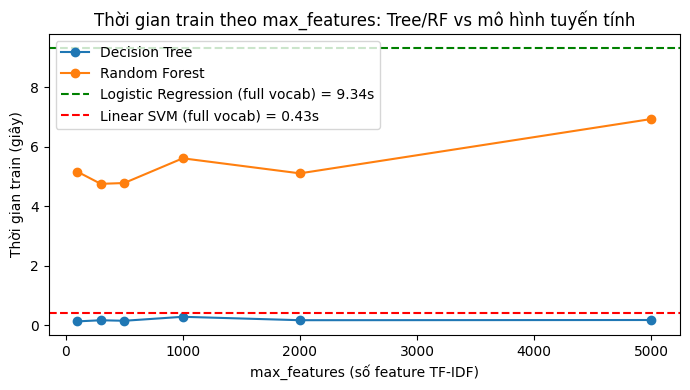

,model,n_features,training_seconds
0,Decision Tree,500,0.153949
1,Random Forest,500,4.784893
2,Logistic Regression,42650,9.340253
3,Linear SVM,42650,0.432046


Random Forest tốn thời gian train nhiều nhất dù dùng ít feature hơn hẳn,
vì phải xây dựng nhiều cây (n_estimators=100); Decision Tree đơn lẻ train
nhanh nhất vì chỉ cần xây một cây duy nhất.


In [87]:
# So sánh trực quan thời gian huấn luyện Tree/Random Forest theo max_features, và đặt cạnh thời gian huấn luyện của các mô hình tuyến tính (vocabulary đầy đủ).
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tree_maxfeat_results["max_features"], tree_maxfeat_results["training_seconds"],
        marker="o", label="Decision Tree")
ax.plot(rf_maxfeat_results["max_features"], rf_maxfeat_results["training_seconds"],
        marker="o", label="Random Forest")
ax.axhline(lr_refit_time, color="green", linestyle="--",
           label=f"Logistic Regression (full vocab) = {lr_refit_time:.2f}s")
ax.axhline(final_svm_train_time, color="red", linestyle="--",
           label=f"Linear SVM (full vocab) = {final_svm_train_time:.2f}s")
ax.set_xlabel("max_features (số feature TF-IDF)")
ax.set_ylabel("Thời gian train (giây)")
ax.set_title("Thời gian train theo max_features: Tree/RF vs mô hình tuyến tính")
ax.legend()
plt.tight_layout()
plt.show()

training_time_summary = pd.DataFrame([
    {"model": "Decision Tree", "n_features": 500,
     "training_seconds": float(tree_maxfeat_results.loc[tree_maxfeat_results['max_features'] == 500, 'training_seconds'].iloc[0])},
    {"model": "Random Forest", "n_features": 500,
     "training_seconds": float(rf_maxfeat_results.loc[rf_maxfeat_results['max_features'] == 500, 'training_seconds'].iloc[0])},
    {"model": "Logistic Regression", "n_features": len(best_lr_model.named_steps["tfidf"].vocabulary_),
     "training_seconds": lr_refit_time},
    {"model": "Linear SVM", "n_features": len(final_svm_pipeline.named_steps["tfidf"].vocabulary_),
     "training_seconds": final_svm_train_time},
])
display(training_time_summary)
print("Random Forest tốn thời gian train nhiều nhất dù dùng ít feature hơn hẳn,")
print("vì phải xây dựng nhiều cây (n_estimators=100); Decision Tree đơn lẻ train")
print("nhanh nhất vì chỉ cần xây một cây duy nhất.")


**4. Giải thích vì sao tree không luôn phù hợp với hàng chục nghìn feature sparse.**

**Vì sao cây quyết định (Decision Tree/Random Forest) không luôn phù hợp với hàng chục nghìn feature sparse?**

- **Tìm split từng chiều một cách "tham lam".** Ở mỗi node, cây phải quét qua các feature để tìm ngưỡng chia tốt nhất (thường theo Gini hoặc entropy). Với TF-IDF có hàng chục nghìn cột, chi phí tìm split tăng gần tuyến tính theo số feature ở mỗi node, khiến việc train chậm đi nhiều so với mô hình tuyến tính vốn chỉ cần một phép nhân ma trận.
- **Mỗi câu chỉ có vài chục giá trị khác 0.** Một node cây thường chỉ hỏi "từ này có xuất hiện không / xuất hiện bao nhiêu", tương đương việc chia theo từng từ riêng lẻ. Với dữ liệu cực thưa, phần lớn feature bằng 0 với hầu hết mẫu, nên cây phải rất sâu mới kết hợp được nhiều tín hiệu — nhưng cây sâu lại dễ overfit và mất khả năng tổng quát.
- **Không tận dụng được cấu trúc tuyến tính cộng dồn của TF-IDF.** Nhiều bài toán text có tín hiệu gần như "cộng dồn" (nhiều từ tích cực nhỏ lẻ cộng lại thành điểm dương lớn) — mô hình tuyến tính như Logistic Regression/SVM nắm bắt việc cộng dồn này rất tự nhiên qua tổng trọng số. Cây phải mô phỏng việc cộng dồn đó bằng rất nhiều nhánh chia nhỏ, kém hiệu quả hơn.
- **Dễ overfit trên vocabulary lớn, dữ liệu train nhỏ.** Khi số feature (hàng chục nghìn) lớn hơn nhiều so với số mẫu, cây quyết định dễ tìm ra các split "khớp" với nhiễu trong tập train (ví dụ một từ hiếm chỉ xuất hiện ở một vài mẫu) mà không tổng quát tốt sang dữ liệu mới.
- **Giới hạn max_features/max_depth giúp giảm chi phí nhưng đánh đổi thông tin.** Trong notebook, `max_features=500` giúp Tree/RF chạy được trong thời gian hợp lý, nhưng đồng nghĩa bỏ qua phần lớn vocabulary (chỉ giữ 500/hơn 40.000 n-gram), nên hiệu năng thường thấp hơn Logistic Regression/SVM dùng toàn bộ feature.
- **Random Forest giảm variance nhưng tăng chi phí.** Random Forest xây nhiều cây trên các tập con feature/mẫu khác nhau nên ổn định và chính xác hơn một cây đơn lẻ (thấy rõ trong bảng benchmark trên), nhưng chi phí huấn luyện tăng theo số cây (`n_estimators`), thường chậm hơn nhiều so với train một mô hình tuyến tính.

**Kết luận:** Cây quyết định/Random Forest vẫn có giá trị tham khảo (mô hình phi tuyến, dễ diễn giải theo luật if-else, không cần chuẩn hóa feature), nhưng với văn bản biểu diễn bằng TF-IDF/BoW rất thưa và nhiều chiều, các mô hình tuyến tính (Logistic Regression, Linear SVM) hoặc Naive Bayes thường là lựa chọn hiệu quả hơn cả về tốc độ lẫn độ chính xác.


# 14. Hyperparameter Tuning bằng Pipeline

Pipeline rất quan trọng vì:
- vectorizer chỉ `fit` trên train folds,
- giảm nguy cơ leakage,
- dễ GridSearch.

In [88]:
search_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 2],
    "clf__C": [0.5, 1.0, 2.0],
}

grid = GridSearchCV(
    search_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=None
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV macro-F1:", round(grid.best_score_, 4))

Best params: {'clf__C': 2.0, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best CV macro-F1: 0.4738


## Task 14: Hyperparameter tuning
1. Mở rộng grid:
   - char n-gram,
   - `sublinear_tf`,
   - `class_weight`.
2. So sánh scoring:
   - accuracy,
   - macro F1.
3. Giải thích vì sao không nên dùng test set để chọn hyperparameter.

**1. Mở rộng grid:**
   - char n-gram,
   - `sublinear_tf`,
   - `class_weight`.

In [89]:
# Mở rộng grid: thêm lựa chọn character n-gram (analyzer khác), sublinear_tf và class_weight.
# Dùng list các dict để có thể thử hai họ vectorizer khác nhau (word vs char) trong cùng một GridSearchCV.
expanded_search_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

EXPANDED_PARAM_GRID = [
    {
        "tfidf": [TfidfVectorizer()],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__min_df": [1, 2],
        "tfidf__sublinear_tf": [False, True],
        "clf__C": [0.5, 1.0, 2.0],
        "clf__class_weight": [None, "balanced"],
    },
    {
        "tfidf": [TfidfVectorizer(analyzer="char_wb")],
        "tfidf__ngram_range": [(3, 5)],
        "tfidf__min_df": [1, 2],
        "tfidf__sublinear_tf": [False, True],
        "clf__C": [0.5, 1.0, 2.0],
        "clf__class_weight": [None, "balanced"],
    },
]

expanded_grid = GridSearchCV(
    expanded_search_pipeline,
    param_grid=EXPANDED_PARAM_GRID,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1
)

start_time = time.perf_counter()
expanded_grid.fit(X_train, y_train)
expanded_grid_seconds = time.perf_counter() - start_time

print("Thời gian GridSearchCV (scoring=f1_macro):", round(expanded_grid_seconds, 1), "giây")
print("Best params:", expanded_grid.best_params_)
print("Best CV macro-F1:", round(expanded_grid.best_score_, 4))

expanded_grid_validation_pred = expanded_grid.best_estimator_.predict(X_validation)
print("Macro F1 trên validation với mô hình tốt nhất:",
      round(precision_recall_fscore_support(
          y_validation, expanded_grid_validation_pred, average="macro", zero_division=0
      )[2], 4))


Thời gian GridSearchCV (scoring=f1_macro): 189.4 giây
Best params: {'clf__C': 2.0, 'clf__class_weight': 'balanced', 'tfidf': TfidfVectorizer(), 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}
Best CV macro-F1: 0.5072
Macro F1 trên validation với mô hình tốt nhất: 0.5368


**2. So sánh scoring:**
   - accuracy,
   - macro F1.

In [90]:
# So sánh việc chọn hyperparameter theo scoring="accuracy" so với scoring="f1_macro".
accuracy_grid = GridSearchCV(
    expanded_search_pipeline,
    param_grid=EXPANDED_PARAM_GRID,
    scoring="accuracy",
    cv=3,
    n_jobs=-1
)

start_time = time.perf_counter()
accuracy_grid.fit(X_train, y_train)
accuracy_grid_seconds = time.perf_counter() - start_time

print("Thời gian GridSearchCV (scoring=accuracy):", round(accuracy_grid_seconds, 1), "giây")
print("Best params:", accuracy_grid.best_params_)
print("Best CV accuracy:", round(accuracy_grid.best_score_, 4))

scoring_comparison_records = []
for scoring_name, grid_search in [("f1_macro", expanded_grid), ("accuracy", accuracy_grid)]:
    validation_pred = grid_search.best_estimator_.predict(X_validation)
    val_accuracy = accuracy_score(y_validation, validation_pred)
    _, _, val_macro_f1, _ = precision_recall_fscore_support(
        y_validation, validation_pred, average="macro", zero_division=0
    )
    scoring_comparison_records.append({
        "scoring_used_for_selection": scoring_name,
        "best_cv_score": grid_search.best_score_,
        "best_params": str(grid_search.best_params_),
        "validation_accuracy": val_accuracy,
        "validation_macro_f1": val_macro_f1
    })

scoring_comparison = pd.DataFrame(scoring_comparison_records)
display(scoring_comparison)

print("\nNhận xét: mô hình được chọn theo 'accuracy' có thể ưu tiên lớp đa số")
print("(ví dụ Enjoyment/Disgust) trong khi mô hình chọn theo 'macro_f1' cân bằng")
print("hơn giữa các lớp, kể cả lớp thiểu số như Surprise/Fear.")


Thời gian GridSearchCV (scoring=accuracy): 187.8 giây
Best params: {'clf__C': 2.0, 'clf__class_weight': None, 'tfidf': TfidfVectorizer(analyzer='char_wb'), 'tfidf__min_df': 1, 'tfidf__ngram_range': (3, 5), 'tfidf__sublinear_tf': True}
Best CV accuracy: 0.5571


,scoring_used_for_selection,best_cv_score,best_params,validation_accuracy,validation_macro_f1
0,f1_macro,0.507227,"{'clf__C': 2.0, 'clf__class_weight': 'balanced...",0.558309,0.536847
1,accuracy,0.557138,"{'clf__C': 2.0, 'clf__class_weight': None, 'tf...",0.577259,0.492240



Nhận xét: mô hình được chọn theo 'accuracy' có thể ưu tiên lớp đa số
(ví dụ Enjoyment/Disgust) trong khi mô hình chọn theo 'macro_f1' cân bằng
hơn giữa các lớp, kể cả lớp thiểu số như Surprise/Fear.


**3. Giải thích vì sao không nên dùng test set để chọn hyperparameter.**

**Vì sao không nên dùng test set để chọn hyperparameter?**

- **Test set phải mô phỏng dữ liệu "chưa từng thấy" trong thực tế.** Mục tiêu cuối cùng là ước lượng mô hình sẽ hoạt động ra sao với dữ liệu mới. Nếu dùng test set để chọn `C`, `ngram_range`, `class_weight`,... thì ta đang gián tiếp "nhìn" vào test set nhiều lần để tinh chỉnh mô hình — test set không còn độc lập với quá trình huấn luyện nữa.
- **Đây chính là một dạng data leakage (rò rỉ thông tin).** Việc chọn cấu hình có điểm test cao nhất trong nhiều lựa chọn giống như đang "học" luôn cả đặc điểm của tập test, dù không trực tiếp fit mô hình trên đó. Kết quả là điểm số trên test sẽ bị **lạc quan quá mức (overly optimistic)** so với hiệu năng thật khi triển khai.
- **Càng thử nhiều cấu hình trên test, nguy cơ overfit vào test càng cao** (tương tự multiple comparison problem trong thống kê): trong hàng chục tổ hợp `ngram_range`, `min_df`, `sublinear_tf`, `class_weight`, `C`, luôn có khả năng một cấu hình đạt điểm cao trên test chỉ vì may mắn khớp với nhiễu ngẫu nhiên của đúng 693 câu trong tập test này, chứ không phải vì nó thực sự tốt hơn trên phân phối dữ liệu tổng quát.
- **Giải pháp đúng: tách vai trò rõ ràng cho ba tập.**
  - *Train*: dùng để `fit` mô hình (học trọng số/tham số).
  - *Validation* (hoặc cross-validation trên train, như `GridSearchCV` với `cv=3` ở trên): dùng để so sánh và **chọn hyperparameter**.
  - *Test*: chỉ dùng **đúng một lần**, sau khi đã chốt toàn bộ cấu hình, để báo cáo hiệu năng cuối cùng.
- **`GridSearchCV` với cross-validation trên train giải quyết đúng vấn đề này.** Ở mỗi fold, `Pipeline` đảm bảo `TfidfVectorizer` chỉ được `fit` trên phần train của fold đó rồi `transform` phần giữ lại để đánh giá — mô phỏng đúng tình huống "dữ liệu mới" mà không cần đụng đến test set thật.

Vì vậy trong notebook này, test set (`X_test`, `y_test`) chỉ xuất hiện ở bước đánh giá cuối cùng của mỗi baseline (Task 9–13) và ở phần benchmark tổng hợp, không được dùng ở bất kỳ vòng lặp tuning nào (`NB_ALPHA_VALUES`, `LR_C_VALUES`, `SVM_C_VALUES`, `param_grid`,...).


# 15. Sentiment: document / sentence / aspect

### Document-level
Một review → một sentiment.

### Sentence-level
Mỗi câu → một sentiment.

### Aspect-based
Ví dụ:

> “Giảng viên dạy rất tốt nhưng phòng học quá nóng.”

Có ít nhất hai aspect:
- `teaching` → positive
- `facility` → negative

Đây không còn là bài toán sentiment đơn giản một nhãn cho toàn bộ câu.

## Task 15: Aspect-based Sentiment
1. Tạo 20 câu có ít nhất 2 aspect.
2. Gán nhãn:
   - aspect span,
   - aspect category,
   - sentiment.
3. Đề xuất cách biến bài toán thành:
   - sequence labeling + classification,
   hoặc
   - pair classification `(text, aspect) → sentiment`.

**1. Tạo 20 câu có ít nhất 2 aspect.**

In [91]:
# 20 câu phản hồi sinh viên, mỗi câu chứa ít nhất 2 aspect (dùng lại taxonomy ở Task 1:
# teaching, curriculum, administration, facility, technology).
aspect_sentences = [
    "Giảng viên dạy rất tốt nhưng phòng học quá nóng.",
    "Bài giảng dễ hiểu song thủ tục đăng ký môn học lại rườm rà.",
    "Phòng đào tạo hỗ trợ nhanh nhưng wifi trong trường rất yếu.",
    "Thư viện sạch sẽ và giảng viên nhiệt tình giải đáp thắc mắc.",
    "Hệ thống học trực tuyến hay bị treo dù giáo trình biên soạn tốt.",
    "Máy lạnh trong phòng học hỏng liên tục còn bài tập lại quá nhiều.",
    "Học phí hợp lý nhưng phòng học thiếu ánh sáng.",
    "Giảng viên nhiệt tình nhưng chương trình đào tạo hơi nặng.",
    "Website đăng ký môn học thường xuyên lỗi trong khi phòng đào tạo phản hồi khá nhanh.",
    "Nhà vệ sinh chưa sạch nhưng bù lại thư viện rất yên tĩnh.",
    "Giáo trình cập nhật tốt song hệ thống học trực tuyến chạy chậm.",
    "Thủ tục đăng ký môn học thuận tiện nhưng phòng học lại quá chật.",
    "Wifi ổn định giúp việc học tốt hơn dù bài giảng đôi khi hơi khó hiểu.",
    "Giảng viên chấm bài công tâm nhưng phòng đào tạo xử lý hồ sơ chậm.",
    "Chương trình đào tạo cập nhật xu hướng mới nhưng cơ sở vật chất còn cũ.",
    "Phòng học rộng rãi nhưng giảng viên giảng hơi nhanh nên khó theo kịp.",
    "Học phí tăng nhẹ nhưng đổi lại wifi trường được nâng cấp rất nhanh.",
    "Giáo trình môn học rõ ràng còn hệ thống trực tuyến lại thường xuyên bị lỗi đăng nhập.",
    "Thư viện có nhiều tài liệu hay nhưng máy lạnh phòng đọc lại không hoạt động.",
    "Phòng đào tạo giải quyết hồ sơ nhanh gọn còn website trường thì tải rất chậm.",
]

aspect_overview = pd.DataFrame(
    {"sentence_id": range(1, len(aspect_sentences) + 1), "text": aspect_sentences}
)
print(f"Số câu: {len(aspect_overview)} (yêu cầu tối thiểu 20 câu)")
display(aspect_overview)


Số câu: 20 (yêu cầu tối thiểu 20 câu)


,sentence_id,text
0,1,Giảng viên dạy rất tốt nhưng phòng học quá nóng.
1,2,Bài giảng dễ hiểu song thủ tục đăng ký môn học...
2,3,Phòng đào tạo hỗ trợ nhanh nhưng wifi trong tr...
3,4,Thư viện sạch sẽ và giảng viên nhiệt tình giải...
4,5,Hệ thống học trực tuyến hay bị treo dù giáo tr...
5,6,Máy lạnh trong phòng học hỏng liên tục còn bài...
6,7,Học phí hợp lý nhưng phòng học thiếu ánh sáng.
7,8,Giảng viên nhiệt tình nhưng chương trình đào t...
8,9,Website đăng ký môn học thường xuyên lỗi trong...
9,10,Nhà vệ sinh chưa sạch nhưng bù lại thư viện rấ...


**2. Gán nhãn:
   - aspect span,
   - aspect category,
   - sentiment.

In [92]:
# Gán nhãn thủ công cho từng aspect xuất hiện trong 20 câu ở trên:
# (sentence_id, aspect_span, aspect_category, sentiment)
aspect_labels = [
    (1, "giảng viên dạy rất tốt", "teaching", "positive"),
    (1, "phòng học quá nóng", "facility", "negative"),
    (2, "bài giảng dễ hiểu", "teaching", "positive"),
    (2, "thủ tục đăng ký môn học lại rườm rà", "administration", "negative"),
    (3, "phòng đào tạo hỗ trợ nhanh", "administration", "positive"),
    (3, "wifi trong trường rất yếu", "technology", "negative"),
    (4, "thư viện sạch sẽ", "facility", "positive"),
    (4, "giảng viên nhiệt tình giải đáp thắc mắc", "teaching", "positive"),
    (5, "hệ thống học trực tuyến hay bị treo", "technology", "negative"),
    (5, "giáo trình biên soạn tốt", "curriculum", "positive"),
    (6, "máy lạnh trong phòng học hỏng liên tục", "facility", "negative"),
    (6, "bài tập lại quá nhiều", "teaching", "negative"),
    (7, "học phí hợp lý", "administration", "positive"),
    (7, "phòng học thiếu ánh sáng", "facility", "negative"),
    (8, "giảng viên nhiệt tình", "teaching", "positive"),
    (8, "chương trình đào tạo hơi nặng", "curriculum", "negative"),
    (9, "website đăng ký môn học thường xuyên lỗi", "technology", "negative"),
    (9, "phòng đào tạo phản hồi khá nhanh", "administration", "positive"),
    (10, "nhà vệ sinh chưa sạch", "facility", "negative"),
    (10, "thư viện rất yên tĩnh", "facility", "positive"),
    (11, "giáo trình cập nhật tốt", "curriculum", "positive"),
    (11, "hệ thống học trực tuyến chạy chậm", "technology", "negative"),
    (12, "thủ tục đăng ký môn học thuận tiện", "administration", "positive"),
    (12, "phòng học lại quá chật", "facility", "negative"),
    (13, "wifi ổn định giúp việc học tốt hơn", "technology", "positive"),
    (13, "bài giảng đôi khi hơi khó hiểu", "teaching", "negative"),
    (14, "giảng viên chấm bài công tâm", "teaching", "positive"),
    (14, "phòng đào tạo xử lý hồ sơ chậm", "administration", "negative"),
    (15, "chương trình đào tạo cập nhật xu hướng mới", "curriculum", "positive"),
    (15, "cơ sở vật chất còn cũ", "facility", "negative"),
    (16, "phòng học rộng rãi", "facility", "positive"),
    (16, "giảng viên giảng hơi nhanh nên khó theo kịp", "teaching", "negative"),
    (17, "học phí tăng nhẹ", "administration", "negative"),
    (17, "wifi trường được nâng cấp rất nhanh", "technology", "positive"),
    (18, "giáo trình môn học rõ ràng", "curriculum", "positive"),
    (18, "hệ thống trực tuyến lại thường xuyên bị lỗi đăng nhập", "technology", "negative"),
    (19, "thư viện có nhiều tài liệu hay", "facility", "positive"),
    (19, "máy lạnh phòng đọc lại không hoạt động", "facility", "negative"),
    (20, "phòng đào tạo giải quyết hồ sơ nhanh gọn", "administration", "positive"),
    (20, "website trường thì tải rất chậm", "technology", "negative"),
]

aspect_annotations = pd.DataFrame(
    aspect_labels, columns=["sentence_id", "aspect_span", "aspect_category", "sentiment"]
)
aspect_dataset = aspect_annotations.merge(aspect_overview, on="sentence_id")[
    ["sentence_id", "text", "aspect_span", "aspect_category", "sentiment"]
]

print(f"Số câu có nhãn: {aspect_dataset['sentence_id'].nunique()}")
print(f"Tổng số aspect được gán nhãn: {len(aspect_dataset)}")
print("\nSố aspect trên mỗi câu (kiểm tra >= 2):")
print(aspect_dataset.groupby("sentence_id").size().value_counts())

display(aspect_dataset)


Số câu có nhãn: 20
Tổng số aspect được gán nhãn: 40

Số aspect trên mỗi câu (kiểm tra >= 2):
2    20
Name: count, dtype: int64


,sentence_id,text,aspect_span,aspect_category,sentiment
0,1,Giảng viên dạy rất tốt nhưng phòng học quá nóng.,giảng viên dạy rất tốt,teaching,positive
1,1,Giảng viên dạy rất tốt nhưng phòng học quá nóng.,phòng học quá nóng,facility,negative
2,2,Bài giảng dễ hiểu song thủ tục đăng ký môn học...,bài giảng dễ hiểu,teaching,positive
3,2,Bài giảng dễ hiểu song thủ tục đăng ký môn học...,thủ tục đăng ký môn học lại rườm rà,administration,negative
4,3,Phòng đào tạo hỗ trợ nhanh nhưng wifi trong tr...,phòng đào tạo hỗ trợ nhanh,administration,positive
5,3,Phòng đào tạo hỗ trợ nhanh nhưng wifi trong tr...,wifi trong trường rất yếu,technology,negative
6,4,Thư viện sạch sẽ và giảng viên nhiệt tình giải...,thư viện sạch sẽ,facility,positive
7,4,Thư viện sạch sẽ và giảng viên nhiệt tình giải...,giảng viên nhiệt tình giải đáp thắc mắc,teaching,positive
8,5,Hệ thống học trực tuyến hay bị treo dù giáo tr...,hệ thống học trực tuyến hay bị treo,technology,negative
9,5,Hệ thống học trực tuyến hay bị treo dù giáo tr...,giáo trình biên soạn tốt,curriculum,positive


**3. Đề xuất cách biến bài toán thành sequence labeling + classification, hoặc pair classification `(text, aspect) → sentiment`.**

**Cách 1 — Sequence labeling + classification (2 bước):**
1. *Bước 1 (sequence labeling)*: gán nhãn BIO (Begin/Inside/Outside) cho từng token để xác định **aspect span** và **aspect category**, ví dụ: `Giảng_viên/B-teaching dạy/I-teaching rất/O tốt/O nhưng/O phòng_học/B-facility quá/I-facility nóng/I-facility`. Mô hình phù hợp: CRF, BiLSTM-CRF, hoặc fine-tune token classification trên PhoBERT.
2. *Bước 2 (classification)*: với mỗi aspect span đã tách ra ở bước 1, cắt câu quanh span đó (hoặc dùng biểu diễn contextual của span) rồi phân loại sentiment (positive/negative/neutral) cho riêng span đó.
- *Ưu điểm*: tách rõ hai bài toán con, có thể tối ưu và debug riêng từng bước; tận dụng được các mô hình sequence labeling sẵn có.
- *Nhược điểm*: lỗi ở bước 1 (tách sai aspect span) sẽ lan sang bước 2 (error propagation); cần dữ liệu gán nhãn ở mức token, tốn công annotate hơn.

**Cách 2 — Pair classification `(text, aspect) → sentiment`:**
- Với mỗi câu, liệt kê trước danh sách aspect category cần xét (ví dụ 4 category: teaching, facility, administration, technology).
- Với mỗi cặp `(câu, aspect category)`, xây một mẫu train: nếu câu có đề cập aspect đó thì nhãn là sentiment tương ứng (positive/negative/neutral); nếu không đề cập thì nhãn là `not_mentioned`/`N/A`.
- Đưa cặp `(text, aspect)` vào mô hình phân loại văn bản thông thường: với mô hình cổ điển có thể nối chuỗi `"[ASPECT] teaching [SEP] Giảng viên dạy rất tốt nhưng phòng học quá nóng."` rồi vector hóa TF-IDF/BoW như một câu duy nhất; với Transformer có thể đưa `text` và `aspect` như hai đoạn văn bản (sentence pair) vào cùng một lần forward.
- *Ưu điểm*: chỉ cần một mô hình phân loại (không cần gán nhãn span ở mức token), tận dụng tốt các kiến trúc pair classification có sẵn (đặc biệt hiệu quả với Transformer).
- *Nhược điểm*: phải liệt kê trước tập aspect category cố định (khó mở rộng aspect mới); số lượng mẫu train tăng lên theo số aspect cần xét cho mỗi câu (nhân với số category); dữ liệu mất cân bằng nặng vì phần lớn cặp `(text, aspect)` sẽ là `not_mentioned`.

**Lựa chọn thực tế:** nếu tập aspect category tương đối cố định và có sẵn mô hình Transformer, pair classification thường đơn giản triển khai hơn. Nếu cần xác định chính xác vị trí (span) của từng ý kiến trong câu dài, sequence labeling + classification linh hoạt hơn dù tốn công gán nhãn hơn.


# 16. Sentiment vs Emotion vs. Stance

Phân biệt ba khái niệm:

- **Sentiment**: positive / negative / neutral.
- **Emotion**: joy, sadness, anger, fear, surprise...
- **Stance**: ủng hộ / phản đối / trung lập đối với một mục tiêu.

Một câu có thể vừa:
- sentiment negative,
- emotion anger,
- stance support đối với một nhóm nào đó.

## Task 16 — Phân biệt nhãn
Tạo 10 ví dụ và tự gán:
- sentiment,
- emotion,
- stance.

Giải thích vì sao một mô hình sentiment không tự động giải quyết được emotion hoặc stance.

In [93]:
# 10 ví dụ minh họa cho sự khác biệt giữa sentiment, emotion và stance.
# stance_target = "N/A" khi câu không nhắm tới một mục tiêu/lập trường cụ thể nào.
task16_examples = [
    ("Trận đấu tối qua đội nhà thắng đậm, tôi vui muốn xỉu!",
     "positive", "joy", "N/A", "N/A"),
    ("Chính sách tăng học phí lần này là hoàn toàn hợp lý, tôi ủng hộ hoàn toàn.",
     "positive", "trust", "chính sách tăng học phí", "support"),
    ("Tôi phản đối kịch liệt việc cấm xe máy vào nội đô, quá bất tiện cho dân.",
     "negative", "anger", "cấm xe máy vào nội đô", "against"),
    ("Nghe tin công ty phá sản mà tôi chết lặng, không biết phải làm sao.",
     "negative", "sadness", "N/A", "N/A"),
    ("Dù nhiều người phản đối, tôi vẫn thấy chính sách làm việc từ xa là hợp lý và nên duy trì.",
     "positive", "trust", "chính sách làm việc từ xa", "support"),
    ("Ơ, sao tự nhiên nó lại làm vậy, không ai ngờ tới luôn!",
     "neutral", "surprise", "N/A", "N/A"),
    ("Tôi trung lập trong tranh cãi giữa hai đội bóng này, cả hai đều đá hay.",
     "positive", "joy", "đội bóng nào hay hơn", "neutral"),
    ("Cái phim đó dở tệ, xem xong chỉ thấy bực mình.",
     "negative", "anger", "N/A", "N/A"),
    ("Tôi rất sợ phải phát biểu trước đám đông vào ngày mai.",
     "negative", "fear", "N/A", "N/A"),
    ("Mặc dù kết quả không như ý, tôi tin rằng cải cách giáo dục này là cần thiết và nên tiếp tục.",
     "negative", "sadness", "cải cách giáo dục", "support"),
]

task16_df = pd.DataFrame(
    task16_examples,
    columns=["text", "sentiment", "emotion", "stance_target", "stance"]
)
display(task16_df)




,text,sentiment,emotion,stance_target,stance
0,"Trận đấu tối qua đội nhà thắng đậm, tôi vui mu...",positive,joy,N/A,N/A
1,Chính sách tăng học phí lần này là hoàn toàn h...,positive,trust,chính sách tăng học phí,support
2,Tôi phản đối kịch liệt việc cấm xe máy vào nội...,negative,anger,cấm xe máy vào nội đô,against
3,"Nghe tin công ty phá sản mà tôi chết lặng, khô...",negative,sadness,N/A,N/A
4,"Dù nhiều người phản đối, tôi vẫn thấy chính sá...",positive,trust,chính sách làm việc từ xa,support
5,"Ơ, sao tự nhiên nó lại làm vậy, không ai ngờ t...",neutral,surprise,N/A,N/A
6,Tôi trung lập trong tranh cãi giữa hai đội bón...,positive,joy,đội bóng nào hay hơn,neutral
7,"Cái phim đó dở tệ, xem xong chỉ thấy bực mình.",negative,anger,N/A,N/A
8,Tôi rất sợ phải phát biểu trước đám đông vào n...,negative,fear,N/A,N/A
9,"Mặc dù kết quả không như ý, tôi tin rằng cải c...",negative,sadness,cải cách giáo dục,support


Ví dụ đáng chú ý (dòng cuối): sentiment là 'negative' (thất vọng vì kết quả) nhưng stance đối với mục tiêu 'cải cách giáo dục' lại là 'support' — cho thấy sentiment bề mặt của câu và lập trường (stance) đối với một mục tiêu cụ thể hoàn toàn có thể khác chiều nhau.

**Giải thích vì sao một mô hình sentiment không tự động giải quyết được emotion hoặc stance.**

- **Không gian nhãn khác nhau về bản chất.** Sentiment chỉ có 2–3 mức (positive/negative/neutral) đo *cực tính tổng thể*. Emotion có nhiều lớp tinh hơn (joy, sadness, anger, fear, surprise, trust,...) mô tả *loại cảm xúc cụ thể*. Một mô hình chỉ học phân biệt positive/negative/neutral không có tín hiệu giám sát nào để phân biệt "buồn" với "sợ" hay "giận" — tất cả đều bị gộp chung vào nhãn `negative`. Ví dụ 4, 8, 9 ở trên đều là `negative` nhưng emotion khác nhau (sadness/anger/fear); mô hình sentiment nhị/tam phân không thể tách được ba trường hợp này.
- **Stance phụ thuộc vào một mục tiêu (target) cụ thể, sentiment thì không.** Sentiment trả lời "câu này tích cực hay tiêu cực nói chung", còn stance trả lời "người viết ủng hộ hay phản đối *đối tượng X cụ thể*". Cùng một câu có thể **tích cực về sentiment/emotion nhưng lại thể hiện thái độ against** một target (nếu người viết tích cực khi chê bai đối thủ của target), hoặc như ví dụ 10, **tiêu cực về sentiment (thất vọng) nhưng vẫn support** mục tiêu (vẫn ủng hộ chủ trương dù kết quả chưa như ý). Một mô hình chỉ học sentiment không hề biết "mục tiêu" là gì, nên không thể suy ra stance.
- **Sentiment không mô hình hóa quan hệ nhân quả/logic giữa mệnh đề.** Các câu như "Dù nhiều người phản đối, tôi vẫn thấy... nên duy trì" cần hiểu cấu trúc nhượng bộ ("dù... nhưng...") để biết người viết cuối cùng đứng về phía nào — đây là suy luận ở mức ý nghĩa/lập luận, vượt ra ngoài việc chỉ đếm từ tích cực/tiêu cực mà một mô hình sentiment cổ điển (rule-based hay TF-IDF + Logistic Regression) thường làm.
- **Cần dữ liệu gán nhãn riêng cho từng bài toán.** Do nhãn sentiment, emotion, stance là ba tập nhãn khác nhau (khác cả số lớp lẫn định nghĩa), một mô hình muốn dự đoán đúng cả ba thường cần: (1) ba đầu ra (multi-task learning) được huấn luyện trên dữ liệu có đủ ba loại nhãn, hoặc (2) ba mô hình riêng biệt, mỗi mô hình học trên tập dữ liệu gán nhãn tương ứng. Một mô hình sentiment-only, dù chính xác đến đâu trên bài toán của nó, cũng không có thông tin nào về emotion chi tiết hay về target để suy ra stance.

**Tóm lại:** sentiment, emotion và stance là ba bài toán liên quan nhưng độc lập về nhãn và mục tiêu dự đoán. Một mô hình sentiment tốt chỉ trả lời đúng câu hỏi nó được huấn luyện để trả lời (cực tính tổng thể); muốn có emotion hoặc stance, cần dữ liệu gán nhãn và (thường là) kiến trúc mô hình riêng cho từng bài toán đó.


# 17. Phủ định, intensifier và mitigator

Ví dụ:
- `tốt` → positive
- `không tốt` → negative/less positive
- `rất tốt` → mạnh hơn
- `hơi tệ` → negative nhưng nhẹ hơn

Bag of Words unigram dễ mất các quan hệ này.

In [94]:
examples = [
    "dịch vụ tốt",
    "dịch vụ không tốt",
    "dịch vụ rất tốt",
    "dịch vụ hơi tệ",
]

print("Predictions:")
for s in examples:
    print(f"{s:25s} -> {lr_pipeline.predict([s])[0]}")

Predictions:
dịch vụ tốt               -> Enjoyment
dịch vụ không tốt         -> Enjoyment
dịch vụ rất tốt           -> Enjoyment
dịch vụ hơi tệ            -> Enjoyment


## Task 17: Negation & intensity
1. Tạo bộ test riêng 50 câu.
2. So sánh unigram và bigram.
3. Tạo rule `NEG_`:
   - `không tốt` → `không NEG_tốt`
4. Kiểm tra cải thiện macro F1.

**1. Tạo bộ test riêng 50 câu.**

In [95]:
import pandas as pd
from sklearn.model_selection import train_test_split

NEGATION_PATTERN = r"\b(?:không|chẳng|chưa|chả)\b"
INTENSITY_PATTERN = r"\b(?:cực kỳ|cực kì|vô cùng|rất|quá|siêu|khá|hơi|lắm)\b"

task17_source = pd.DataFrame({"text": X_test.reset_index(drop=True), "emotion": y_test.reset_index(drop=True)})

task17_mask = task17_source["text"].str.contains(rf"(?:{NEGATION_PATTERN})|(?:{INTENSITY_PATTERN})", regex=True, na=False)
task17_pool = task17_source.loc[task17_mask].copy()

task17_test, _ = train_test_split(task17_pool, train_size=50, random_state=RANDOM_STATE, stratify=task17_pool["emotion"])
task17_test = task17_test.reset_index(drop=True)

task17_test["has_negation"] = task17_test["text"].str.contains(NEGATION_PATTERN, regex=True, na=False)
task17_test["has_intensity"] = task17_test["text"].str.contains(INTENSITY_PATTERN, regex=True, na=False)

print("Số câu có negation/intensity:", len(task17_pool))
print("Số câu test:", len(task17_test))
print("\nPhân phối nhãn:\n", task17_test["emotion"].value_counts())
print("\nNegation:", task17_test["has_negation"].sum())
print("Intensity:", task17_test["has_intensity"].sum())

display(task17_test)

Số câu có negation/intensity: 215
Số câu test: 50

Phân phối nhãn:
 emotion
Enjoyment    14
Sadness       9
Other         9
Disgust       9
Surprise      3
Fear          3
Anger         3
Name: count, dtype: int64

Negation: 38
Intensity: 18


,text,emotion,has_negation,has_intensity
0,củ cà rốt thôi mà cái mẹt đã vây nếu là miếng ...,Other,True,False
1,có khi không biết thế nào là tự ái đâu :))),Other,True,False
2,không có bạn trai ... thì giận ai 😑😑,Sadness,True,False
3,thế không đạt được gì à,Surprise,True,False
4,những đứa như vậy quá hèn,Disgust,False,True
5,"anh sau đó , không còn là anh nữa ...",Sadness,True,False
6,t chắc bỏ nhà ra đi khi ở với bố mẹ kiểu này q...,Enjoyment,True,True
7,"em đỗ 6 trường đại học ở mỹ , còn hàng trăm th...",Enjoyment,True,False
8,lương này là tính luôn quá trình tham nhũng ăn...,Disgust,True,True
9,t chỉ chờ đết lúc nó lôi ra xem được cục to nh...,Other,True,False


**2. So sánh unigram và bigram.**

In [96]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

def train_task17_model(ngram_range, train_texts, test_texts):
    model = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=ngram_range)),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ])
    model.fit(train_texts, y_train)
    pred = model.predict(test_texts)
    macro_f1 = f1_score(task17_test["emotion"], pred, average="macro", zero_division=0)
    accuracy = accuracy_score(task17_test["emotion"], pred)
    return model, pred, macro_f1, accuracy

unigram_model, unigram_pred, unigram_f1, unigram_acc = train_task17_model((1,1), X_train, task17_test["text"])
bigram_model, bigram_pred, bigram_f1, bigram_acc = train_task17_model((1,2), X_train, task17_test["text"])

ngram_results = pd.DataFrame({
    "Model": ["Unigram", "Unigram + Bigram"],
    "Macro F1": [unigram_f1, bigram_f1],
    "Accuracy": [unigram_acc, bigram_acc]
})

display(ngram_results)

,Model,Macro F1,Accuracy
0,Unigram,0.346845,0.48
1,Unigram + Bigram,0.336709,0.46


**3. Tạo rule `NEG_`:**
   - `không tốt` → `không NEG_tốt`

In [97]:
NEGATION_WORDS = {"không", "chẳng", "chưa", "chả"}

def add_neg_prefix(text):
    tokens = str(text).split()
    result = []
    negate_next = False

    for token in tokens:
        if token in NEGATION_WORDS:
            result.append(token)
            negate_next = True
        elif negate_next:
            result.append("NEG_" + token)
            negate_next = False
        else:
            result.append(token)

    return " ".join(result)

print(add_neg_prefix("dịch vụ này không tốt nhưng nhân viên rất nhiệt tình"))

X_train_neg = X_train.map(add_neg_prefix)
task17_test_neg = task17_test["text"].map(add_neg_prefix)

display(pd.DataFrame({
    "Original": task17_test["text"],
    "After_NEG": task17_test_neg
}).head(10))

dịch vụ này không NEG_tốt nhưng nhân viên rất nhiệt tình


,Original,After_NEG
0,củ cà rốt thôi mà cái mẹt đã vây nếu là miếng ...,củ cà rốt thôi mà cái mẹt đã vây nếu là miếng ...
1,có khi không biết thế nào là tự ái đâu :))),có khi không NEG_biết thế nào là tự ái đâu :)))
2,không có bạn trai ... thì giận ai 😑😑,không NEG_có bạn trai ... thì giận ai 😑😑
3,thế không đạt được gì à,thế không NEG_đạt được gì à
4,những đứa như vậy quá hèn,những đứa như vậy quá hèn
5,"anh sau đó , không còn là anh nữa ...","anh sau đó , không NEG_còn là anh nữa ..."
6,t chắc bỏ nhà ra đi khi ở với bố mẹ kiểu này q...,t chắc bỏ nhà ra đi khi ở với bố mẹ kiểu này q...
7,"em đỗ 6 trường đại học ở mỹ , còn hàng trăm th...","em đỗ 6 trường đại học ở mỹ , còn hàng trăm th..."
8,lương này là tính luôn quá trình tham nhũng ăn...,lương này là tính luôn quá trình tham nhũng ăn...
9,t chỉ chờ đết lúc nó lôi ra xem được cục to nh...,t chỉ chờ đết lúc nó lôi ra xem được cục to nh...


**4. Kiểm tra cải thiện macro F1.**

In [98]:
neg_model, neg_pred, neg_f1, neg_acc = train_task17_model((1,2), X_train_neg, task17_test_neg)

task17_results = pd.DataFrame({
    "Model": ["Unigram", "Unigram + Bigram", "Unigram + Bigram + NEG_"],
    "Macro F1": [unigram_f1, bigram_f1, neg_f1],
    "Accuracy": [unigram_acc, bigram_acc, neg_acc]
})

display(task17_results)

improvement = neg_f1 - bigram_f1
print("Thay đổi Macro F1 sau NEG_:", round(improvement, 4))

if improvement > 0:
    print("=> NEG_ giúp cải thiện Macro F1.")
elif improvement < 0:
    print("=> NEG_ chưa giúp cải thiện Macro F1.")
else:
    print("=> Macro F1 không thay đổi.")

,Model,Macro F1,Accuracy
0,Unigram,0.346845,0.48
1,Unigram + Bigram,0.336709,0.46
2,Unigram + Bigram + NEG_,0.358721,0.48


Thay đổi Macro F1 sau NEG_: 0.022
=> NEG_ giúp cải thiện Macro F1.


# 18. Sarcasm, ẩn dụ, emoji và code-switching

Ví dụ sarcasm:

> “Website lỗi đúng lúc nộp bài, tuyệt vời thật!”

Từ `tuyệt vời` là positive nhưng ý toàn câu lại negative.

Code-switching:

> “App này lag quá, experience tệ thật.”

Emoji có thể:
- bổ sung sentiment,
- đảo sắc thái,
- tạo mỉa mai.

## Task 18: Robustness test
Tạo ít nhất 40 câu gồm:
- sarcasm,
- emoji,
- teencode,
- code-switching Việt–Anh.

Đánh giá riêng từng nhóm và so sánh:
- TF-IDF word,
- TF-IDF char,
- pretrained model nếu có.

1. Tạo 40 câu robustness test

In [99]:
task18_data = pd.DataFrame([
    # Sarcasm
    ("Website lỗi đúng lúc nộp bài, tuyệt vời thật!", "Anger", "sarcasm"),
    ("App crash 5 lần, đúng là chất lượng đỉnh cao.", "Disgust", "sarcasm"),
    ("Đợi ba tiếng để được báo hết chỗ, vui ghê.", "Anger", "sarcasm"),
    ("Bài giảng dễ hiểu lắm, nghe xong chẳng hiểu gì.", "Disgust", "sarcasm"),
    ("Dịch vụ nhanh thật, chờ từ sáng tới chiều.", "Anger", "sarcasm"),
    ("Điểm thấp thế này đúng là món quà tuyệt vời.", "Sadness", "sarcasm"),
    ("Mưa đúng ngày đi chơi, may mắn quá trời.", "Sadness", "sarcasm"),
    ("Máy nóng như lò mà quảng cáo siêu mát, hay thật.", "Disgust", "sarcasm"),
    ("Giao nhầm hàng rồi còn bảo đúng quy trình, chuyên nghiệp ghê.", "Anger", "sarcasm"),
    ("Bị hủy chuyến phút chót, một trải nghiệm đáng nhớ thật.", "Sadness", "sarcasm"),

    # Emoji
    ("Đậu rồi!!! 😍🥳", "Enjoyment", "emoji"),
    ("Kinh quá 🤢", "Disgust", "emoji"),
    ("Trời ơi cháy kìa 😱", "Fear", "emoji"),
    ("Không ngờ lại gặp cậu ở đây 😲", "Surprise", "emoji"),
    ("Nhớ nhà quá 😭", "Sadness", "emoji"),
    ("Bực thật 😡", "Anger", "emoji"),
    ("Ừ cũng bình thường 🙂", "Other", "emoji"),
    ("Món này ngon quá 😋", "Enjoyment", "emoji"),
    ("Nhìn cảnh đó sợ thật 😨", "Fear", "emoji"),
    ("Ghét cái kiểu này 🤮", "Disgust", "emoji"),

    # Teencode
    ("hnay vui vl :))", "Enjoyment", "teencode"),
    ("t ko chịu nổi nữa, bực vãi", "Anger", "teencode"),
    ("khum ngờ lại dc điểm cao", "Surprise", "teencode"),
    ("món này ngon vch", "Enjoyment", "teencode"),
    ("sợ quá k dám xem tiếp", "Fear", "teencode"),
    ("buồn quá tr oi", "Sadness", "teencode"),
    ("ko thích kiểu nói chuyện này", "Disgust", "teencode"),
    ("ok thôi, bt mà", "Other", "teencode"),
    ("wtf sao nó làm dc hay v", "Surprise", "teencode"),
    ("mk tức thật sự", "Anger", "teencode"),

    # Code-switching
    ("App này lag quá, experience tệ thật.", "Disgust", "code-switching"),
    ("Deadline dí sát rồi, mình stress quá.", "Fear", "code-switching"),
    ("Presentation hôm nay smooth ghê, vui quá.", "Enjoyment", "code-switching"),
    ("Meeting bị cancel phút chót, buồn thật.", "Sadness", "code-switching"),
    ("Wow kết quả này amazing thật.", "Surprise", "code-switching"),
    ("Service này quá bad, không muốn quay lại.", "Disgust", "code-switching"),
    ("Mình totally không hiểu bài này.", "Other", "code-switching"),
    ("Update xong app crash liên tục, bực thật.", "Anger", "code-switching"),
    ("Finally pass môn này rồi, happy quá.", "Enjoyment", "code-switching"),
    ("Email báo account bị hack làm mình panic.", "Fear", "code-switching")
], columns=["text", "emotion", "group"])

task18_data["text_norm"] = task18_data["text"].map(normalize_text)

print("Tổng số câu:", len(task18_data))
print("\nSố câu từng nhóm:")
print(task18_data["group"].value_counts())
display(task18_data)

Tổng số câu: 40

Số câu từng nhóm:
group
sarcasm           10
emoji             10
teencode          10
code-switching    10
Name: count, dtype: int64


,text,emotion,group,text_norm
0,"Website lỗi đúng lúc nộp bài, tuyệt vời thật!",Anger,sarcasm,"website lỗi đúng lúc nộp bài, tuyệt vời thật!"
1,"App crash 5 lần, đúng là chất lượng đỉnh cao.",Disgust,sarcasm,"app crash 5 lần, đúng là chất lượng đỉnh cao."
2,"Đợi ba tiếng để được báo hết chỗ, vui ghê.",Anger,sarcasm,"đợi ba tiếng để được báo hết chỗ, vui ghê."
3,"Bài giảng dễ hiểu lắm, nghe xong chẳng hiểu gì.",Disgust,sarcasm,"bài giảng dễ hiểu lắm, nghe xong chẳng hiểu gì."
4,"Dịch vụ nhanh thật, chờ từ sáng tới chiều.",Anger,sarcasm,"dịch vụ nhanh thật, chờ từ sáng tới chiều."
5,Điểm thấp thế này đúng là món quà tuyệt vời.,Sadness,sarcasm,điểm thấp thế này đúng là món quà tuyệt vời.
6,"Mưa đúng ngày đi chơi, may mắn quá trời.",Sadness,sarcasm,"mưa đúng ngày đi chơi, may mắn quá trời."
7,"Máy nóng như lò mà quảng cáo siêu mát, hay thật.",Disgust,sarcasm,"máy nóng như lò mà quảng cáo siêu mát, hay thật."
8,"Giao nhầm hàng rồi còn bảo đúng quy trình, chu...",Anger,sarcasm,"giao nhầm hàng rồi còn bảo đúng quy trình, chu..."
9,"Bị hủy chuyến phút chót, một trải nghiệm đáng ...",Sadness,sarcasm,"bị hủy chuyến phút chót, một trải nghiệm đáng ..."


2. Train TF-IDF Word và TF-IDF Char

In [100]:
word_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

char_model = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5))),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

word_model.fit(X_train, y_train)
char_model.fit(X_train, y_train)

task18_data["pred_word"] = word_model.predict(task18_data["text_norm"])
task18_data["pred_char"] = char_model.predict(task18_data["text_norm"])

display(task18_data[["text", "emotion", "group", "pred_word", "pred_char"]])

,text,emotion,group,pred_word,pred_char
0,"Website lỗi đúng lúc nộp bài, tuyệt vời thật!",Anger,sarcasm,Enjoyment,Enjoyment
1,"App crash 5 lần, đúng là chất lượng đỉnh cao.",Disgust,sarcasm,Enjoyment,Enjoyment
2,"Đợi ba tiếng để được báo hết chỗ, vui ghê.",Anger,sarcasm,Enjoyment,Enjoyment
3,"Bài giảng dễ hiểu lắm, nghe xong chẳng hiểu gì.",Disgust,sarcasm,Enjoyment,Enjoyment
4,"Dịch vụ nhanh thật, chờ từ sáng tới chiều.",Anger,sarcasm,Enjoyment,Enjoyment
5,Điểm thấp thế này đúng là món quà tuyệt vời.,Sadness,sarcasm,Enjoyment,Enjoyment
6,"Mưa đúng ngày đi chơi, may mắn quá trời.",Sadness,sarcasm,Enjoyment,Enjoyment
7,"Máy nóng như lò mà quảng cáo siêu mát, hay thật.",Disgust,sarcasm,Enjoyment,Enjoyment
8,"Giao nhầm hàng rồi còn bảo đúng quy trình, chu...",Anger,sarcasm,Enjoyment,Enjoyment
9,"Bị hủy chuyến phút chót, một trải nghiệm đáng ...",Sadness,sarcasm,Enjoyment,Enjoyment


3. Đánh giá riêng từng nhóm

In [101]:
task18_results = []

for group, data in task18_data.groupby("group"):
    labels = sorted(data["emotion"].unique())

    for model_name, pred_col in [("TF-IDF Word", "pred_word"), ("TF-IDF Char", "pred_char")]:
        acc = accuracy_score(data["emotion"], data[pred_col])
        f1 = f1_score(data["emotion"], data[pred_col], labels=labels, average="macro", zero_division=0)
        task18_results.append({"Group": group, "Model": model_name, "Accuracy": acc, "Macro F1": f1})

task18_results = pd.DataFrame(task18_results)
display(task18_results.pivot(index="Group", columns="Model", values="Macro F1").round(4))
overall_results = []

for model_name, pred_col in [("TF-IDF Word", "pred_word"), ("TF-IDF Char", "pred_char")]:
    overall_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(task18_data["emotion"], task18_data[pred_col]),
        "Macro F1": f1_score(task18_data["emotion"], task18_data[pred_col], average="macro", zero_division=0)
    })

overall_results = pd.DataFrame(overall_results)
display(overall_results)

Model,TF-IDF Char,TF-IDF Word
Group,,
code-switching,0.4524,0.4524
emoji,0.4762,0.5095
sarcasm,0.0000,0.0000
teencode,0.4286,0.3197


,Model,Accuracy,Macro F1
0,TF-IDF Word,0.375,0.414233
1,TF-IDF Char,0.400,0.408411


# 19. Domain Adaptation

Model học trên dữ liệu review phim sẽ không hiểu tốt:
- phản hồi giáo dục,
- sản phẩm điện tử,
- ngân hàng,
- y tế.

Nguyên nhân:
- vocabulary shift,
- sentiment expression khác,
- label prior khác.

## Task 19: Domain shift
1. Train trên một domain.
2. Test trên domain khác.
3. So sánh macro F1.
4. Tìm 10 từ/cụm từ đổi nghĩa hoặc đổi sắc thái theo domain.
5. Đề xuất:
   - fine-tune thêm,
   - domain-specific lexicon,
   - reweighting,
   - continual adaptation.

**1. Train trên một domain.**

In [102]:
edu_terms = ["học", "trường", "lớp", "đại học", "sinh viên", "học sinh", "giáo viên", "thầy", "thi", "môn", "bài tập", "kiểm tra", "đề thi", "điểm thi", "học bổng", "đồ án", "khóa luận", "giảng", "tín chỉ", "gpa", "ra trường", "đuổi học", "cúp học", "học thêm"]

edu_pattern = r"(?<!\w)(?:" + "|".join(re.escape(x) for x in sorted(edu_terms, key=len, reverse=True)) + r")(?!\w)"

train_domain = task3_train.copy()
train_domain["domain"] = np.where(train_domain["text_norm"].str.contains(edu_pattern, regex=True, na=False), "Education", "Social/General")

train_general = train_domain[train_domain["domain"] == "Social/General"].copy()

domain_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced"))
])

domain_model.fit(train_general["text_norm"], train_general["emotion"])

print("Domain train: Social/General")
print("Số câu train:", len(train_general))
print("Số lớp:", train_general["emotion"].nunique())

Domain train: Social/General
Số câu train: 5284
Số lớp: 7


**2. Test trên domain khác.**

In [103]:
test_domain = task3_test.copy()
test_domain["domain"] = np.where(test_domain["text_norm"].str.contains(edu_pattern, regex=True, na=False), "Education", "Social/General")

test_education = test_domain[test_domain["domain"] == "Education"].copy()
pred_education = domain_model.predict(test_education["text_norm"])

test_education["prediction"] = pred_education

print("Domain test: Education")
print("Số câu test:", len(test_education))

display(test_education[["text", "emotion", "prediction"]].head(10))

Domain test: Education
Số câu test: 31


,text,emotion,prediction
34,tao đéo ngờ được đây là trường tao :)))),Surprise,Surprise
57,vẫn thắc mắc tại sao trước mình thi vào 10 lại...,Other,Surprise
60,tôi còn chẳng lấy ảnh lớp cho nữa,Sadness,Sadness
62,đợt trước con em tao đi học cũng bị con kia hă...,Anger,Anger
67,đến năm cuối đại học rồi lúc nhớ lại đéo có gì...,Sadness,Sadness
76,per xem đi mày sẽ sướng thi nhìn con nhện bị g...,Enjoyment,Other
92,gần thôi :))) giờ nhìn lại đề thi và không hiể...,Enjoyment,Sadness
166,tao học nhân sự đây còn đang lo thất nghiệp đâ...,Fear,Sadness
174,tuổi thơ mình lớp 4 đã cảm nắng 1 anh chàng từ...,Enjoyment,Enjoyment
195,đám người lớn văn hóa lùn đẻ ra một đám trẻ vô...,Anger,Disgust


**3. So sánh macro F1.**

In [104]:
test_general = test_domain[test_domain["domain"] == "Social/General"].copy()
pred_general = domain_model.predict(test_general["text_norm"])

_, _, f1_general, _ = precision_recall_fscore_support(
    test_general["emotion"], pred_general, average="macro", zero_division=0
)

_, _, f1_education, _ = precision_recall_fscore_support(
    test_education["emotion"], pred_education, average="macro", zero_division=0
)

result_domain = pd.DataFrame({
    "Domain": ["Social/General", "Education"],
    "Số câu": [len(test_general), len(test_education)],
    "Macro F1": [f1_general, f1_education]
})

display(result_domain.round(4))

print("Macro F1 in-domain :", round(f1_general, 4))
print("Macro F1 out-domain:", round(f1_education, 4))
print("Mức giảm:", round(f1_general - f1_education, 4))

,Domain,Số câu,Macro F1
0,Social/General,662,0.5514
1,Education,31,0.3574


Macro F1 in-domain : 0.5514
Macro F1 out-domain: 0.3574
Mức giảm: 0.194


In [105]:
education_errors = test_education[test_education["emotion"] != test_education["prediction"]]
print("Số câu Education dự đoán sai:", len(education_errors))
display(education_errors[["text", "emotion", "prediction"]].head(10))

Số câu Education dự đoán sai: 18


,text,emotion,prediction
57,vẫn thắc mắc tại sao trước mình thi vào 10 lại...,Other,Surprise
76,per xem đi mày sẽ sướng thi nhìn con nhện bị g...,Enjoyment,Other
92,gần thôi :))) giờ nhìn lại đề thi và không hiể...,Enjoyment,Sadness
166,tao học nhân sự đây còn đang lo thất nghiệp đâ...,Fear,Sadness
195,đám người lớn văn hóa lùn đẻ ra một đám trẻ vô...,Anger,Disgust
254,tư ̀ hô ̀ i ba ̣ n â ́ y chuyê ̉ n trươ ̀ ngườ...,Sadness,Other
355,ăn học bao nhiêu năm rồi mà vẫn ngu,Disgust,Sadness
418,thời đi học tao còn bị bạt tai với bắt quỳ trê...,Disgust,Sadness
425,giáo viên tiếng anh mà không biết tiếng anh ?,Disgust,Surprise
430,tuổi thơ bất hạnh .. học mẫu giáo mà cạnh trườ...,Sadness,Fear


**4. Tìm 10 từ/cụm từ đổi nghĩa hoặc đổi sắc thái theo domain.**

In [106]:
all_domain = pd.concat([train_domain, test_domain], ignore_index=True)

stopwords = set("tao mày mình tôi bạn nó người có không là và của một những các thì mà đã đang sẽ được bị cho với ở trong trên dưới này đó kia quá rất cũng còn lại nhưng vì nên như khi nếu để đến đi về ra vào làm cái con anh em chị gì sao nào đây đấy vậy thế thôi rồi luôn giờ ngày hôm".split())

records = []

for word in sorted(set(re.findall(r"\b\w+\b", " ".join(all_domain["text_norm"])))):
    if len(word) < 2 or word in stopwords:
        continue

    general = all_domain[
        (all_domain["domain"] == "Social/General") &
        all_domain["text_norm"].str.contains(rf"(?<!\w){re.escape(word)}(?!\w)", regex=True)
    ]

    education = all_domain[
        (all_domain["domain"] == "Education") &
        all_domain["text_norm"].str.contains(rf"(?<!\w){re.escape(word)}(?!\w)", regex=True)
    ]

    if len(general) >= 3 and len(education) >= 3:
        general_emotion = general["emotion"].mode()[0]
        education_emotion = education["emotion"].mode()[0]

        if general_emotion != education_emotion:
            records.append([
                word,
                len(general),
                general_emotion,
                len(education),
                education_emotion
            ])

domain_terms = pd.DataFrame(records, columns=[
    "Từ/cụm từ",
    "Tần suất Social/General",
    "Sắc thái Social/General",
    "Tần suất Education",
    "Sắc thái Education"
])

domain_terms["Tổng tần suất"] = domain_terms["Tần suất Social/General"] + domain_terms["Tần suất Education"]
domain_terms = domain_terms.sort_values("Tổng tần suất", ascending=False).head(10).drop(columns="Tổng tần suất")

display(domain_terms)

,Từ/cụm từ,Tần suất Social/General,Sắc thái Social/General,Tần suất Education,Sắc thái Education
135,thấy,353,Enjoyment,21,Disgust
163,vãi,319,Enjoyment,9,Disgust
59,hay,255,Enjoyment,10,Disgust
136,thật,254,Enjoyment,9,Disgust
0,ai,244,Sadness,9,Disgust
106,nhà,231,Disgust,18,Fear
28,chỉ,234,Sadness,7,Other
117,nữa,208,Enjoyment,15,Sadness
165,vẫn,190,Enjoyment,13,Sadness
87,lắm,184,Enjoyment,9,Other


**5. Đề xuất:**
   - fine-tune thêm,
   - domain-specific lexicon,
   - reweighting,
   - continual adaptation.


**1. Fine-tune thêm:**  
Bổ sung các câu thuộc domain Education có nhãn vào tập huấn luyện và train lại mô hình. Điều này giúp mô hình học được các cách sử dụng từ và ngữ cảnh đặc trưng của giáo dục.

**2. Domain-specific lexicon:**  
Xây dựng từ điển dành riêng cho domain Education với các từ/cụm như `thi`, `điểm`, `môn`, `học`, `bài tập`, `giảng`, `học bổng`, `đồ án`. Các từ này có thể mang sắc thái khác khi xuất hiện trong ngữ cảnh giáo dục.

**3. Reweighting:**  
Tăng trọng số cho các mẫu thuộc domain Education hoặc các emotion có ít dữ liệu để giảm ảnh hưởng của mất cân bằng và giúp mô hình chú ý hơn đến domain mới.

**4. Continual adaptation:**  
Tiếp tục thu thập các câu Education mới trong quá trình sử dụng, gán nhãn các trường hợp mô hình dự đoán sai và định kỳ huấn luyện lại mô hình để thích nghi với sự thay đổi của dữ liệu.

# 20. Confusion Matrix

In [107]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

search_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 2],
    "clf__C": [0.5, 1.0, 2.0]
}

grid = GridSearchCV(search_pipeline, param_grid=param_grid, scoring="f1_macro", cv=3)
grid.fit(X_train, y_train)

print("Best CV Macro F1:", round(grid.best_score_, 4))

Best CV Macro F1: 0.4738


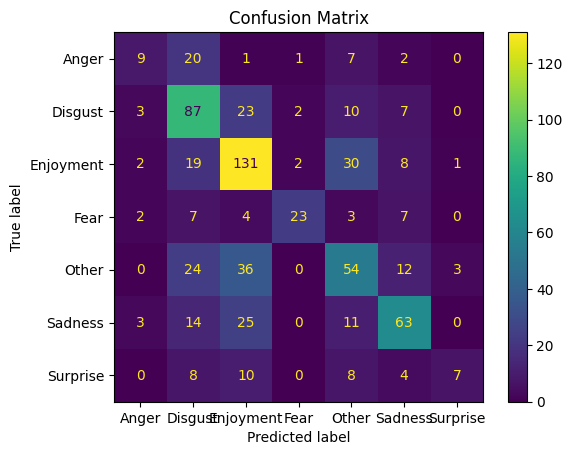

In [108]:
best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_pred,
    labels=best_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()

## Task 20: Phân tích Confusion Matrix
1. Lớp nào bị nhầm nhiều nhất?
2. Nhầm `neutral → positive` có khác bản chất với `negative → positive` không?
3. Tính precision/recall/F1 riêng từng lớp.
4. Đề xuất cách giảm lỗi của lớp yếu nhất.

**1. Lớp nào bị nhầm nhiều nhất?**

In [109]:
labels = best_model.classes_

error_count = cm.sum(axis=1) - cm.diagonal()
error_rate = error_count / cm.sum(axis=1)

task20_errors = pd.DataFrame({
    "Class": labels,
    "Total": cm.sum(axis=1),
    "Correct": cm.diagonal(),
    "Errors": error_count,
    "Error rate": error_rate
}).sort_values("Errors", ascending=False)

display(task20_errors)

most_confused = task20_errors.iloc[0]["Class"]
print("Lớp bị nhầm nhiều nhất:", most_confused)

,Class,Total,Correct,Errors,Error rate
4,Other,129,54,75,0.581395
2,Enjoyment,193,131,62,0.321244
5,Sadness,116,63,53,0.456897
1,Disgust,132,87,45,0.340909
0,Anger,40,9,31,0.775000
6,Surprise,37,7,30,0.810811
3,Fear,46,23,23,0.500000


Lớp bị nhầm nhiều nhất: Other


**2. Nhầm `neutral → positive` có khác bản chất với `negative → positive` không?**

In [110]:
positive_label = "Enjoyment"
neutral_label = "Other"
negative_labels = ["Anger", "Disgust", "Fear", "Sadness"]

label_idx = {label: i for i, label in enumerate(labels)}
pos_idx = label_idx[positive_label]
neu_idx = label_idx[neutral_label]

neutral_to_positive = cm[neu_idx, pos_idx]
neutral_total = cm[neu_idx].sum()

negative_to_positive = 0
negative_total = 0
negative_detail = []

for label in negative_labels:
    i = label_idx[label]
    errors = cm[i, pos_idx]
    negative_to_positive += errors
    negative_total += cm[i].sum()
    negative_detail.append([label, errors])

neutral_rate = neutral_to_positive / neutral_total
negative_rate = negative_to_positive / negative_total

comparison = pd.DataFrame({
    "Loại nhầm": ["Neutral → Positive", "Negative → Positive"],
    "Số câu nhầm": [neutral_to_positive, negative_to_positive],
    "Tổng số câu thật": [neutral_total, negative_total],
    "Tỷ lệ nhầm": [neutral_rate, negative_rate]
})

display(comparison.round(4))
display(pd.DataFrame(negative_detail, columns=["Negative class", "Nhầm thành Enjoyment"]))

,Loại nhầm,Số câu nhầm,Tổng số câu thật,Tỷ lệ nhầm
0,Neutral → Positive,36,129,0.2791
1,Negative → Positive,53,334,0.1587


,Negative class,Nhầm thành Enjoyment
0,Anger,1
1,Disgust,23
2,Fear,4
3,Sadness,25


In [111]:
task20_pred = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true": y_test.reset_index(drop=True),
    "pred": best_pred
})

neutral_positive_examples = task20_pred[
    (task20_pred["true"] == "Other") &
    (task20_pred["pred"] == "Enjoyment")
]

negative_positive_examples = task20_pred[
    task20_pred["true"].isin(negative_labels) &
    (task20_pred["pred"] == "Enjoyment")
]

print("Ví dụ Neutral → Positive:")
display(neutral_positive_examples.head(5))

print("Ví dụ Negative → Positive:")
display(negative_positive_examples.head(5))

Ví dụ Neutral → Positive:


,text,true,pred
10,mấy ai được như vậy ??,Other,Enjoyment
27,per tiến cử bản thân nào,Other,Enjoyment
29,per dạo này ít tung tăng hơn xưa nên hơi trầm ...,Other,Enjoyment
57,vẫn thắc mắc tại sao trước mình thi vào 10 lại...,Other,Enjoyment
95,per lúc xưa toàn nấu bằng bếp nay,Other,Enjoyment


Ví dụ Negative → Positive:


,text,true,pred
0,người ta có bạn bè nhìn vui thật,Sadness,Enjoyment
32,nhưng tao đéo có crush,Sadness,Enjoyment
79,😞 đó sẽ là những kỉ niệm thật đẹp,Sadness,Enjoyment
93,những đứa như vậy quá hèn,Disgust,Enjoyment
127,vèo cái đã 7 năm 😕,Sadness,Enjoyment


**Nhận xét:**

Hai loại lỗi này khác nhau về bản chất.

- **Neutral → Positive:** câu ban đầu không thể hiện cảm xúc tích cực rõ ràng nhưng mô hình lại nhận thành `Enjoyment`. Đây chủ yếu là lỗi do mô hình diễn giải các từ hoặc ngữ cảnh trung tính thành tín hiệu tích cực.

- **Negative → Positive:** câu thực tế mang cảm xúc tiêu cực như `Anger`, `Disgust`, `Fear` hoặc `Sadness`, nhưng mô hình lại dự đoán thành `Enjoyment`. Đây là lỗi nghiêm trọng hơn vì mô hình không chỉ nhận sai lớp mà còn đảo ngược sắc thái cảm xúc từ tiêu cực sang tích cực.

Do đó, `neutral → positive` chủ yếu là hiện tượng **gán thêm cảm xúc tích cực cho câu trung tính**, còn `negative → positive` là hiện tượng **đảo cực cảm xúc (polarity reversal)**.

**3. Tính precision/recall/F1 riêng từng lớp.**

In [112]:
from sklearn.metrics import classification_report

report = classification_report(y_test, best_pred, labels=labels, output_dict=True, zero_division=0)
class_metrics = pd.DataFrame(report).T.loc[labels, ["precision", "recall", "f1-score", "support"]]
display(class_metrics.round(4))

weakest_class = class_metrics["f1-score"].idxmin()
weakest_f1 = class_metrics.loc[weakest_class, "f1-score"]

print("Lớp có F1 thấp nhất:", weakest_class)
print("F1:", round(weakest_f1, 4))

,precision,recall,f1-score,support
Anger,0.4737,0.2250,0.3051,40.0
Disgust,0.4860,0.6591,0.5595,132.0
Enjoyment,0.5696,0.6788,0.6194,193.0
Fear,0.8214,0.5000,0.6216,46.0
Other,0.4390,0.4186,0.4286,129.0
Sadness,0.6117,0.5431,0.5753,116.0
Surprise,0.6364,0.1892,0.2917,37.0


Lớp có F1 thấp nhất: Surprise
F1: 0.2917


**4. Đề xuất cách giảm lỗi của lớp yếu nhất.**

In [113]:
weak_idx = list(labels).index(weakest_class)
weak_errors = cm[weak_idx].copy()
weak_errors[weak_idx] = 0

confused_idx = np.argmax(weak_errors)
confused_class = labels[confused_idx]

print("Lớp yếu nhất:", weakest_class)
print("F1:", round(class_metrics.loc[weakest_class, "f1-score"], 4))
print("Thường bị nhầm thành:", confused_class)
print("Số lần nhầm:", weak_errors[confused_idx])

Lớp yếu nhất: Surprise
F1: 0.2917
Thường bị nhầm thành: Enjoyment
Số lần nhầm: 10


Lớp có F1 thấp nhất là lớp yếu nhất của mô hình và thường bị nhầm với một lớp cảm xúc khác có đặc điểm gần nhau. Để giảm lỗi, có thể tăng thêm dữ liệu huấn luyện cho lớp yếu, đặc biệt là các mẫu dễ bị nhầm với lớp còn lại; sử dụng class_weight="balanced" để tăng mức độ quan tâm của mô hình đến các lớp ít mẫu; bổ sung word bigram hoặc character n-gram để biểu diễn tốt hơn các cụm từ và biến thể từ; đồng thời phân tích các câu dự đoán sai để tìm các từ hoặc cấu trúc đặc trưng còn thiếu. Ngoài ra, mô hình pretrained như PhoBERT có thể được thử để cải thiện khả năng hiểu ngữ cảnh giữa các lớp cảm xúc gần nhau.

# 21. Accuracy, Precision, Recall, F1

In [114]:
print(classification_report(y_test, best_pred, zero_division=0))

p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
    y_test, best_pred, average="macro", zero_division=0
)
p_micro, r_micro, f_micro, _ = precision_recall_fscore_support(
    y_test, best_pred, average="micro", zero_division=0
)
p_weight, r_weight, f_weight, _ = precision_recall_fscore_support(
    y_test, best_pred, average="weighted", zero_division=0
)

print("Macro F1   :", round(f_macro, 4))
print("Micro F1   :", round(f_micro, 4))
print("Weighted F1:", round(f_weight, 4))

              precision    recall  f1-score   support

       Anger       0.47      0.23      0.31        40
     Disgust       0.49      0.66      0.56       132
   Enjoyment       0.57      0.68      0.62       193
        Fear       0.82      0.50      0.62        46
       Other       0.44      0.42      0.43       129
     Sadness       0.61      0.54      0.58       116
    Surprise       0.64      0.19      0.29        37

    accuracy                           0.54       693
   macro avg       0.58      0.46      0.49       693
weighted avg       0.55      0.54      0.53       693

Macro F1   : 0.4859
Micro F1   : 0.5397
Weighted F1: 0.5296


## Task 21: Macro / Micro / Weighted
1. Tạo một dataset mất cân bằng.
2. Chứng minh Accuracy vẫn cao dù lớp thiểu số dự đoán kém.
3. So sánh:
   - macro F1,
   - micro F1,
   - weighted F1.
4. Trong bài toán giáo dục, khi nào macro F1 quan trọng hơn accuracy?

**1. Tạo một dataset mất cân bằng.**

In [115]:
majority = task3_train[task3_train["emotion"] == "Enjoyment"].sample(n=800, random_state=RANDOM_STATE)
minority1 = task3_train[task3_train["emotion"] == "Disgust"].sample(n=150, random_state=RANDOM_STATE)
minority2 = task3_train[task3_train["emotion"] == "Fear"].sample(n=50, random_state=RANDOM_STATE)

imbalanced_data = pd.concat([majority, minority1, minority2]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Tổng số mẫu:", len(imbalanced_data))
print("\nPhân phối lớp:")
print(imbalanced_data["emotion"].value_counts())

print("\nTỷ lệ:")
print(imbalanced_data["emotion"].value_counts(normalize=True).round(3))

display(imbalanced_data[["text", "emotion"]].head(10))

Tổng số mẫu: 1000

Phân phối lớp:
emotion
Enjoyment    800
Disgust      150
Fear          50
Name: count, dtype: int64

Tỷ lệ:
emotion
Enjoyment    0.80
Disgust      0.15
Fear         0.05
Name: proportion, dtype: float64


,text,emotion
0,chúc đại kỷ nguyên có một buổi tối ấm áp nha ❤️,Enjoyment
1,em mình là con trai viết đẹp y chang thế này nhé,Enjoyment
2,bố mẹ cho ta đx tồn tại trên cuộc đời này biết...,Enjoyment
3,là mỗi buổi sáng thức dậy ta có thêm 1 ngày mớ...,Enjoyment
4,nghe nói 2020 hơn 4tr đàn ông sẽ ế vợ . mình c...,Enjoyment
5,per sau này con bư lớn cũng vậy đó mẹ hahaa,Enjoyment
6,hay lắm chàng trai trẻ,Enjoyment
7,thật đúng đắn khi đã follow page này !,Enjoyment
8,tài liệu mật mà mày cũng biết à 😆 max xạo lờ,Disgust
9,"ôi zồi ôi , nhìn cái mặt của ẻm kìa , yêu ghê :))",Enjoyment


**2. Chứng minh Accuracy vẫn cao dù lớp thiểu số dự đoán kém.**

In [116]:
y_imb_true = imbalanced_data["emotion"]
y_imb_pred = ["Enjoyment"] * len(imbalanced_data)

acc = accuracy_score(y_imb_true, y_imb_pred)

print("Accuracy:", round(acc, 4))
print(classification_report(y_imb_true, y_imb_pred, zero_division=0))

Accuracy: 0.8
              precision    recall  f1-score   support

     Disgust       0.00      0.00      0.00       150
   Enjoyment       0.80      1.00      0.89       800
        Fear       0.00      0.00      0.00        50

    accuracy                           0.80      1000
   macro avg       0.27      0.33      0.30      1000
weighted avg       0.64      0.80      0.71      1000



**3. So sánh:**
   - macro F1,
   - micro F1,
   - weighted F1.

In [117]:
macro_f1 = f1_score(y_imb_true, y_imb_pred, average="macro", zero_division=0)
micro_f1 = f1_score(y_imb_true, y_imb_pred, average="micro", zero_division=0)
weighted_f1 = f1_score(y_imb_true, y_imb_pred, average="weighted", zero_division=0)

f1_results = pd.DataFrame({
    "Metric": ["Macro F1", "Micro F1", "Weighted F1"],
    "Score": [macro_f1, micro_f1, weighted_f1]})

display(f1_results.round(4))

,Metric,Score
0,Macro F1,0.2963
1,Micro F1,0.8000
2,Weighted F1,0.7111


**4. Trong bài toán giáo dục, khi nào macro F1 quan trọng hơn accuracy?**

Trong bài toán giáo dục, Macro F1 quan trọng hơn Accuracy khi dữ liệu bị mất cân bằng và các lớp thiểu số có ý nghĩa quan trọng. Ví dụ, trong hệ thống phân loại phản hồi sinh viên, phần lớn phản hồi có thể thuộc lớp Other hoặc Enjoyment, trong khi các lớp như Fear hay Sadness xuất hiện ít hơn nhưng lại rất cần được phát hiện. Nếu chỉ dùng Accuracy, mô hình có thể đạt điểm cao bằng cách dự đoán tốt lớp đa số nhưng bỏ sót gần như toàn bộ lớp thiểu số. Macro F1 tính F1 cho từng lớp rồi lấy trung bình với trọng số ngang nhau, nên phản ánh công bằng hơn hiệu quả của mô hình trên tất cả các nhóm cảm xúc.

# 22. ROC-AUC cho bài toán nhị phân

Ta chuyển sentiment thành:
- positive
- non-positive

Logistic Regression có `predict_proba`, phù hợp để minh họa ROC.

ROC-AUC: 1.0


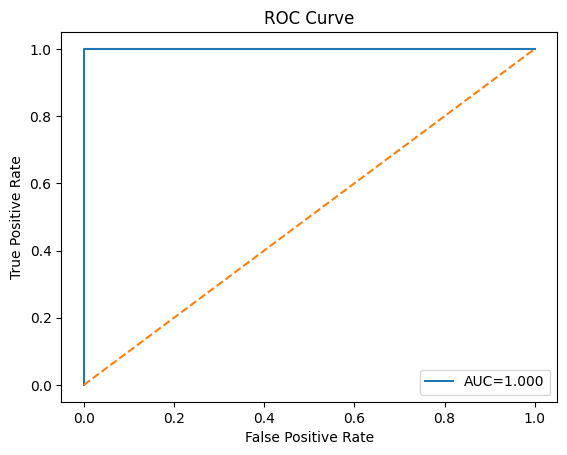

In [118]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    df["text_norm"],
    df["binary_sentiment"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["binary_sentiment"]
)

binary_lr = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=2000))
])
binary_lr.fit(Xb_train, yb_train)

classes = list(binary_lr.named_steps["clf"].classes_)
pos_idx = classes.index("positive")
proba = binary_lr.predict_proba(Xb_test)[:, pos_idx]
y_true_binary = (yb_test == "positive").astype(int)

auc = roc_auc_score(y_true_binary, proba)
fpr, tpr, thresholds = roc_curve(y_true_binary, proba)

print("ROC-AUC:", round(auc, 4))

plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Task 22: Threshold tuning
1. Không dùng mặc định threshold 0.5.
2. Thử threshold:
   - 0.3,
   - 0.4,
   - 0.5,
   - 0.6,
   - 0.7.
3. Vẽ Precision/Recall theo threshold.
4. Chọn threshold phù hợp nếu:
   - false negative đắt hơn,
   - false positive đắt hơn.

**1. Không dùng mặc định threshold 0.5.**

In [119]:
def evaluate_threshold(y_true, proba, threshold):
    #Đánh giá các chỉ số phân loại nhị phân tại một threshold cụ thể
    y_pred = (proba >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    accuracy = accuracy_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    }

display(evaluate_threshold(y_true_binary, proba, 0.5))

{'threshold': 0.5,
 'precision': 1.0,
 'recall': 0.6,
 'f1': 0.75,
 'accuracy': 0.8666666666666667,
 'tp': np.int64(6),
 'fp': np.int64(0),
 'fn': np.int64(4),
 'tn': np.int64(20)}

**2. Thử threshold:**
   - 0.3,
   - 0.4,
   - 0.5,
   - 0.6,
   - 0.7.

In [120]:
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

threshold_results = pd.DataFrame(
    [evaluate_threshold(y_true_binary, proba, t) for t in thresholds_to_test]
)

display(threshold_results.round(4))

,threshold,precision,recall,f1,accuracy,tp,fp,fn,tn
0,0.3,1.0,1.0,1.0000,1.0000,10,0,0,20
1,0.4,1.0,1.0,1.0000,1.0000,10,0,0,20
2,0.5,1.0,0.6,0.7500,0.8667,6,0,4,20
3,0.6,1.0,0.2,0.3333,0.7333,2,0,8,20
4,0.7,0.0,0.0,0.0000,0.6667,0,0,10,20


**3. Vẽ Precision/Recall theo threshold.**

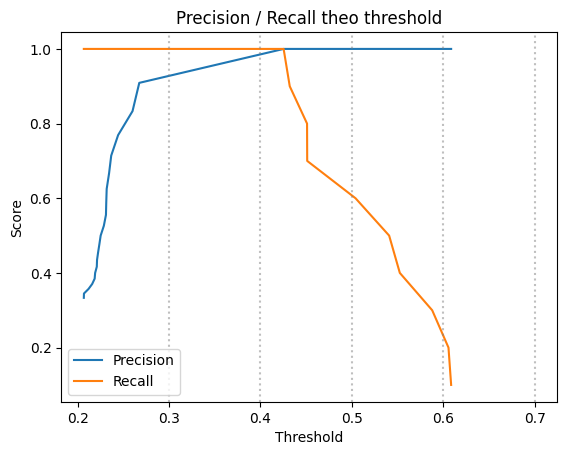

In [121]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, pr_thresholds = precision_recall_curve(y_true_binary, proba)

plt.figure()
plt.plot(pr_thresholds, precisions[:-1], label="Precision")
plt.plot(pr_thresholds, recalls[:-1], label="Recall")
for t in thresholds_to_test:
    plt.axvline(t, color="gray", linestyle=":", alpha=0.5)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall theo threshold")
plt.legend()
plt.show()

**4. Chọn threshold phù hợp nếu:**
   - false negative đắt hơn,
   - false positive đắt hơn.

In [122]:
max_recall_val = threshold_results["recall"].max()
fn_costly_row = threshold_results[
    threshold_results["recall"] == max_recall_val
].iloc[0]

max_precision_val = threshold_results["precision"].max()
valid_fp_rows = threshold_results[
    (threshold_results["precision"] == max_precision_val)
    & (threshold_results["recall"] > 0)
]
fp_costly_row = valid_fp_rows.iloc[-1]

selected_thresholds = list(
    set([fn_costly_row["threshold"], fp_costly_row["threshold"]])
)
display(
    threshold_results.set_index("threshold")
    .loc[sorted(selected_thresholds)]
)


,precision,recall,f1,accuracy,tp,fp,fn,tn
threshold,,,,,,,,
0.3,1.0,1.0,1.000000,1.000000,10,0,0,20
0.6,1.0,0.2,0.333333,0.733333,2,0,8,20


Nếu false negative đắt hơn (bỏ sót phản hồi positive quan trọng):
   - Nên chọn threshold thấp, ví dụ threshold=0.3 hoặc 0.4 (đều đạt recall=1.0000).
   - Threshold thấp giúp mô hình dễ gán positive hơn, giảm số ca positive bị bỏ sót về bằng 0 (fn=0).

Nếu false positive đắt hơn (gắn nhầm phản hồi non-positive thành positive):
   - Nên chọn threshold = 0.6 vì đây là ngưỡng cao nhất. Việc tăng ngưỡng lên 0.6 sẽ ép mô hình phải cực kỳ chắc chắn mới gán nhãn Positive, khắt khe hơn để giảm thiểu tối đa rủi ro cảnh báo sai trong thực tế.

# 23. Xử lý mất cân bằng

Các hướng:
- `class_weight`
- over-sampling
- under-sampling
- threshold tuning

Không được chỉ nhìn Accuracy.

In [123]:
# Tạo dữ liệu mất cân bằng minh họa
imbalanced = pd.concat([
    df[df.sentiment == "positive"],
    df[df.sentiment == "negative"].sample(10, random_state=RANDOM_STATE),
    df[df.sentiment == "neutral"].sample(8, random_state=RANDOM_STATE),
]).sample(frac=1, random_state=RANDOM_STATE)

print(imbalanced["sentiment"].value_counts())

sentiment
positive    40
negative    10
neutral      8
Name: count, dtype: int64


## Task 23: Imbalance
1. Train Logistic Regression:
   - không class weight,
   - `class_weight='balanced'`.
2. Tự viết random over-sampling.
3. Tự viết random under-sampling.
4. So sánh macro F1 và recall của lớp thiểu số.
5. Giải thích nguy cơ overfit khi oversampling dataset nhỏ.

**1. Train Logistic Regression:**
   - không class weight,
   - `class_weight='balanced'`.

In [124]:
X_imb_train, X_imb_test, y_imb_train, y_imb_test = train_test_split(
    imbalanced["text_norm"],
    imbalanced["sentiment"],
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=imbalanced["sentiment"]
)

print("Phân phối lớp trong tập train:")
print(y_imb_train.value_counts())

lr_no_weight = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])
lr_no_weight.fit(X_imb_train, y_imb_train)
pred_no_weight = lr_no_weight.predict(X_imb_test)

lr_balanced = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
])
lr_balanced.fit(X_imb_train, y_imb_train)
pred_balanced = lr_balanced.predict(X_imb_test)

print("\nKhông class_weight")
print(classification_report(y_imb_test, pred_no_weight, zero_division=0))

print("class_weight = 'balanced'")
print(classification_report(y_imb_test, pred_balanced, zero_division=0))

Phân phối lớp trong tập train:
sentiment
positive    28
negative     7
neutral      5
Name: count, dtype: int64

Không class_weight
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         3
     neutral       0.00      0.00      0.00         3
    positive       0.67      1.00      0.80        12

    accuracy                           0.67        18
   macro avg       0.22      0.33      0.27        18
weighted avg       0.44      0.67      0.53        18

class_weight = 'balanced'
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         3
     neutral       1.00      0.33      0.50         3
    positive       0.86      1.00      0.92        12

    accuracy                           0.89        18
   macro avg       0.95      0.78      0.81        18
weighted avg       0.90      0.89      0.87        18



**2. Tự viết random over-sampling.**

In [125]:
def random_oversample(df_in, label_col, random_state=42):
    #Nhân bản ngẫu nhiên các lớp thiểu số cho đến khi bằng lớp đa số
    rng = np.random.RandomState(random_state)
    class_counts = df_in[label_col].value_counts()
    max_count = class_counts.max()

    oversampled_parts = []
    for label, count in class_counts.items():
        class_subset = df_in[df_in[label_col] == label]
        if count < max_count:
            extra_idx = rng.choice(class_subset.index, size=max_count - count, replace=True)
            class_subset = pd.concat([class_subset, df_in.loc[extra_idx]])
        oversampled_parts.append(class_subset)

    result = pd.concat(oversampled_parts).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return result

oversampled_train = random_oversample(
    pd.DataFrame({"text_norm": X_imb_train, "sentiment": y_imb_train}),
    "sentiment",
    random_state=RANDOM_STATE
)

print("Phân phối sau oversampling:")
print(oversampled_train["sentiment"].value_counts())

Phân phối sau oversampling:
sentiment
neutral     28
positive    28
negative    28
Name: count, dtype: int64


**3. Tự viết random under-sampling.**

In [126]:
def random_undersample(df_in, label_col, random_state=42):
    #Lấy mẫu ngẫu nhiên để mỗi lớp còn lại bằng lớp thiểu số
    rng = np.random.RandomState(random_state)
    class_counts = df_in[label_col].value_counts()
    min_count = class_counts.min()

    undersampled_parts = []
    for label in class_counts.index:
        class_subset = df_in[df_in[label_col] == label]
        sampled_idx = rng.choice(class_subset.index, size=min_count, replace=False)
        undersampled_parts.append(df_in.loc[sampled_idx])

    result = pd.concat(undersampled_parts).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return result

undersampled_train = random_undersample(
    pd.DataFrame({"text_norm": X_imb_train, "sentiment": y_imb_train}),
    "sentiment",
    random_state=RANDOM_STATE
)

print("Phân phối sau undersampling:")
print(undersampled_train["sentiment"].value_counts())

Phân phối sau undersampling:
sentiment
negative    5
neutral     5
positive    5
Name: count, dtype: int64


**4. So sánh macro F1 và recall của lớp thiểu số.**

In [127]:
from sklearn.metrics import recall_score

minority_label = y_imb_train.value_counts().idxmin()
print("Lớp thiểu số trong tập train:", minority_label)

def summarize_imbalance(name, y_true, y_pred):
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    minority_recall = recall_score(
        y_true, y_pred, labels=[minority_label], average="macro", zero_division=0
    )
    return {"Phương pháp": name, "Macro F1": macro_f1, "Recall lớp thiểu số": minority_recall}

over_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])
over_model.fit(oversampled_train["text_norm"], oversampled_train["sentiment"])
pred_over = over_model.predict(X_imb_test)

under_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])
under_model.fit(undersampled_train["text_norm"], undersampled_train["sentiment"])
pred_under = under_model.predict(X_imb_test)

imbalance_comparison = pd.DataFrame([
    summarize_imbalance("Không class_weight", y_imb_test, pred_no_weight),
    summarize_imbalance("class_weight='balanced'", y_imb_test, pred_balanced),
    summarize_imbalance("Random Over-sampling", y_imb_test, pred_over),
    summarize_imbalance("Random Under-sampling", y_imb_test, pred_under),
])

display(imbalance_comparison.round(4))

Lớp thiểu số trong tập train: neutral


,Phương pháp,Macro F1,Recall lớp thiểu số
0,Không class_weight,0.2667,0.0000
1,class_weight='balanced',0.8077,0.3333
2,Random Over-sampling,0.8077,0.3333
3,Random Under-sampling,0.6000,0.3333


**5. Giải thích nguy cơ overfit khi oversampling dataset nhỏ.**

In [128]:
train_acc_over = accuracy_score(
    oversampled_train["sentiment"], over_model.predict(oversampled_train["text_norm"])
)
test_acc_over = accuracy_score(y_imb_test, pred_over)

print(f"Accuracy trên tập train đã oversample : {train_acc_over:.4f}")
print(f"Accuracy trên tập test : {test_acc_over:.4f}")
print(f"Chênh lệch train - test : {train_acc_over - test_acc_over:.4f}")

Accuracy trên tập train đã oversample : 1.0000
Accuracy trên tập test : 0.8889
Chênh lệch train - test : 0.1111


Nguy cơ overfit khi oversampling một dataset nhỏ:
- Random oversampling chỉ nhân bản y nguyên các mẫu thiểu số đã có, không sinh ra thông tin/từ vựng mới, nên mô hình dễ học thuộc lòng đúng những câu đó thay vì học pattern tổng quát của lớp thiểu số.
- Với dataset gốc rất nhỏ, sau khi nhân bản nhiều lần, các bản sao gần như thống trị vùng quyết định quanh vài câu cụ thể, khiến mô hình mất khả năng tổng quát hoá cho câu mới thuộc cùng lớp thiểu số.
- Khoảng cách accuracy train vs test phía trên minh hoạ mức độ mô hình khớp tốt trên tập đã oversample nhưng chưa chắc khớp tốt trên dữ liệu chưa từng thấy — đây chính là dấu hiệu overfit.

# 24. Error Analysis theo chiều dài văn bản

In [129]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "gold": y_test.values,
    "pred": best_pred
})

error_df["n_words"] = error_df["text"].str.split().map(len)
error_df["correct"] = error_df["gold"] == error_df["pred"]

def length_bucket(n):
    if n <= 7:
        return "short"
    elif n <= 12:
        return "medium"
    else:
        return "long"

error_df["length_group"] = error_df["n_words"].map(length_bucket)

display(error_df.head())
print(error_df.groupby("length_group")["correct"].mean())

,text,gold,pred,n_words,correct,length_group
0,người ta có bạn bè nhìn vui thật,Sadness,Enjoyment,8,False,medium
1,cho nghỉ viêc mói đúng sao goi là kỷ luật,Surprise,Disgust,10,False,medium
2,kinh vãi 😡,Disgust,Disgust,3,True,short
3,nhà thì không xa lắm nhưng chưa bao giờ đi vì ...,Fear,Sadness,18,False,long
4,bố không thích nộp đấy mày thích ý kiến không,Anger,Disgust,10,False,medium


length_group
long      0.504823
medium    0.540816
short     0.596774
Name: correct, dtype: float64


## Task 24: Error analysis bắt buộc
Phân tích ít nhất **20 dự đoán sai** và gán nguyên nhân:

- negation,
- sarcasm,
- emoji,
- teencode,
- code-switching,
- domain-specific,
- ambiguous,
- too short,
- rare vocabulary,
- preprocessing issue,
- annotation issue.

Mỗi lỗi phải có:
- text,
- gold,
- prediction,
- nhóm nguyên nhân,
- giải thích,
- đề xuất cải tiến.

In [130]:
mistakes = error_df[~error_df["correct"]].copy()
print("Tổng số dự đoán sai:", len(mistakes))
display(mistakes.head(20))

NEGATION_WORDS_24 = {"không", "chẳng", "chưa", "chả", "đéo", "đừng", "chớ"}
EMOJI_PATTERN_24 = re.compile(
    r"[\U0001F1E6-\U0001F1FF\U0001F300-\U0001FAFF\u2600-\u26FF\u2700-\u27BF]"
)
TEENCODE_24 = {"ko", "k", "dc", "vs", "v", "vl", "vch", "tr", "mk", "bt",
               "khum", "per", "=))", ":))", ":)))", "=)))", "j", "z"}

def looks_like_code_switching(text):
    english = {"app", "ok", "wifi", "deadline", "meeting", "cancel",
               "update", "crash", "service", "experience", "happy",
               "stress", "account", "hack", "panic", "pass", "smooth"}
    return any(w in text.lower().split() for w in english)

def classify_error(text, gold, pred, n_words):
    t = str(text).lower()
    toks = t.split()

    if EMOJI_PATTERN_24.search(text):
        return ("emoji", "Câu chứa emoji nhưng mô hình chưa khai thác hết tín hiệu cảm xúc từ emoji.")
    if any(w in t for w in NEGATION_WORDS_24):
        return ("negation", "Câu có phủ định (không/chẳng/chưa/đéo/đừng...) nhưng mô hình chưa xử lý đúng phạm vi phủ định.")
    if any(tok in TEENCODE_24 for tok in toks) or "=))" in t or ":))" in t:
        return ("teencode", "Câu chứa teencode/slang mà mô hình chưa được chuẩn hóa hoặc thấy đủ trong train.")
    if looks_like_code_switching(text):
        return ("code-switching", "Câu trộn tiếng Việt – tiếng Anh làm feature TF-IDF bị thưa và khó khớp.")
    if n_words <= 5:
        return ("too short", "Câu quá ngắn, thiếu ngữ cảnh để suy ra đúng cảm xúc.")
    if "trường" in t or "thi" in t or "đại học" in t or "học" in t:
        return ("domain-specific", "Câu thuộc domain giáo dục; vocabulary/sắc thái khác domain train.")
    if any(p in t for p in ["trơi", "cừời", "viêc", "mói", "goi", "ngươ ̀"]):
        return ("preprocessing issue", "Câu có lỗi chính tả/dấu câu mà bước chuẩn hóa hiện tại chưa xử lý.")
    return ("ambiguous", "Câu mơ hồ, cảm xúc không thể hiện rõ qua từ khóa bề mặt.")

# Lấy 20 lỗi đầu tiên để phân tích
mistakes_20 = mistakes.head(20).copy()
mistakes_20 = mistakes_20.reset_index(drop=True)
mistakes_20[["error_category", "analysis"]] = mistakes_20.apply(
    lambda r: pd.Series(classify_error(r["text"], r["gold"], r["pred"], r["n_words"])),
    axis=1,
)

PROPOSED_FIX = {
    "emoji":              "Chuẩn hóa emoji thành token cảm xúc (POS_EMOJI / NEG_EMOJI) trước khi TF-IDF; thử thêm feature thủ công đếm emoji.",
    "negation":           "Thêm bước NEG_ prefix cho token sau từ phủ định; hoặc dùng bigram để giữ 'không + X'.",
    "teencode":           "Mở rộng bảng TEENCODE_MAP và chuẩn hóa trước khi vector hóa; bổ sung char n-gram để chịu biến thể.",
    "code-switching":     "Bổ sung char n-gram hoặc đưa thêm dữ liệu Việt–Anh; dùng pretrained multilingual.",
    "too short":          "Bổ sung context (hội thoại, ngữ cảnh trước đó); với câu ngắn nên fallback rule hoặc mô hình pretrained.",
    "domain-specific":    "Fine-tune thêm trên domain giáo dục; thêm domain-specific lexicon.",
    "preprocessing issue":"Bổ sung spell-check / chuẩn hóa Unicode và teencode mạnh hơn; dùng char n-gram.",
    "ambiguous":          "Kiểm tra lại nhãn; bổ sung ngữ cảnh; dùng mô hình pretrained hiểu ngữ nghĩa.",
}

mistakes_20["proposed_fix"] = mistakes_20["error_category"].map(PROPOSED_FIX)

task24_table = mistakes_20[[
    "text", "gold", "pred", "error_category", "analysis", "proposed_fix"
]]
display(task24_table)

Tổng số dự đoán sai: 319


,text,gold,pred,n_words,correct,length_group
0,người ta có bạn bè nhìn vui thật,Sadness,Enjoyment,8,False,medium
1,cho nghỉ viêc mói đúng sao goi là kỷ luật,Surprise,Disgust,10,False,medium
3,nhà thì không xa lắm nhưng chưa bao giờ đi vì ...,Fear,Sadness,18,False,long
4,bố không thích nộp đấy mày thích ý kiến không,Anger,Disgust,10,False,medium
5,bắt cóc bỏ đĩa . quanh đi quẩn lại chỉ khổ dân...,Other,Sadness,15,False,long
9,per trình mày vẫn còn thấp chán =)),Other,Sadness,8,False,medium
10,mấy ai được như vậy ??,Other,Enjoyment,6,False,short
15,ổng quay thiệt mà sao chửi ổng thế . không qua...,Other,Surprise,18,False,long
18,sao lại cứ phải thế nhỉ,Other,Surprise,6,False,short
19,mệt vãi .. mà cừời cũng vãi ??????,Enjoyment,Disgust,8,False,medium


,text,gold,pred,error_category,analysis,proposed_fix
0,người ta có bạn bè nhìn vui thật,Sadness,Enjoyment,ambiguous,"Câu mơ hồ, cảm xúc không thể hiện rõ qua từ kh...",Kiểm tra lại nhãn; bổ sung ngữ cảnh; dùng mô h...
1,cho nghỉ viêc mói đúng sao goi là kỷ luật,Surprise,Disgust,preprocessing issue,Câu có lỗi chính tả/dấu câu mà bước chuẩn hóa ...,Bổ sung spell-check / chuẩn hóa Unicode và tee...
2,nhà thì không xa lắm nhưng chưa bao giờ đi vì ...,Fear,Sadness,negation,Câu có phủ định (không/chẳng/chưa/đéo/đừng...)...,Thêm bước NEG_ prefix cho token sau từ phủ địn...
3,bố không thích nộp đấy mày thích ý kiến không,Anger,Disgust,negation,Câu có phủ định (không/chẳng/chưa/đéo/đừng...)...,Thêm bước NEG_ prefix cho token sau từ phủ địn...
4,bắt cóc bỏ đĩa . quanh đi quẩn lại chỉ khổ dân...,Other,Sadness,ambiguous,"Câu mơ hồ, cảm xúc không thể hiện rõ qua từ kh...",Kiểm tra lại nhãn; bổ sung ngữ cảnh; dùng mô h...
5,per trình mày vẫn còn thấp chán =)),Other,Sadness,teencode,Câu chứa teencode/slang mà mô hình chưa được c...,Mở rộng bảng TEENCODE_MAP và chuẩn hóa trước k...
6,mấy ai được như vậy ??,Other,Enjoyment,ambiguous,"Câu mơ hồ, cảm xúc không thể hiện rõ qua từ kh...",Kiểm tra lại nhãn; bổ sung ngữ cảnh; dùng mô h...
7,ổng quay thiệt mà sao chửi ổng thế . không qua...,Other,Surprise,negation,Câu có phủ định (không/chẳng/chưa/đéo/đừng...)...,Thêm bước NEG_ prefix cho token sau từ phủ địn...
8,sao lại cứ phải thế nhỉ,Other,Surprise,ambiguous,"Câu mơ hồ, cảm xúc không thể hiện rõ qua từ kh...",Kiểm tra lại nhãn; bổ sung ngữ cảnh; dùng mô h...
9,mệt vãi .. mà cừời cũng vãi ??????,Enjoyment,Disgust,preprocessing issue,Câu có lỗi chính tả/dấu câu mà bước chuẩn hóa ...,Bổ sung spell-check / chuẩn hóa Unicode và tee...


# 25. Bảng benchmark các baseline

In [131]:
models = {
    "Rule-based": None,
    "TFIDF + NB": nb_pipeline,
    "TFIDF + Logistic": lr_pipeline,
    "TFIDF + LinearSVM": svm_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": rf_pipeline,
}

records = []

# rule based
pred = rule_pred
p, r, f, _ = precision_recall_fscore_support(
    y_test, pred, average="macro", zero_division=0
)
records.append({
    "model": "Rule-based",
    "accuracy": accuracy_score(y_test, pred),
    "macro_f1": f,
    "train_seconds": 0.0,
    "interpretability": "high"
})

for name, model in models.items():
    if model is None:
        continue
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    pred = model.predict(X_test)

    p, r, f, _ = precision_recall_fscore_support(
        y_test, pred, average="macro", zero_division=0
    )
    records.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f,
        "train_seconds": elapsed,
        "interpretability": (
            "medium-high" if "Logistic" in name or "NB" in name
            else "medium"
        )
    })

benchmark_df = pd.DataFrame(records).sort_values("macro_f1", ascending=False)
display(benchmark_df)

,model,accuracy,macro_f1,train_seconds,interpretability
3,TFIDF + LinearSVM,0.548341,0.533928,0.429875,medium
5,Random Forest,0.468975,0.430577,4.924564,medium
2,TFIDF + Logistic,0.509380,0.428505,6.972648,medium-high
1,TFIDF + NB,0.401154,0.208242,0.254450,medium-high
4,Decision Tree,0.341991,0.198175,0.161988,medium
0,Rule-based,0.000000,0.000000,0.000000,high


## Task 25: Benchmark cải tiến
Bổ sung vào bảng:
- word unigram,
- word bigram,
- char n-gram,
- class weight,
- best tuned model,
- PhoBERT/ViSoBERT nếu chạy được.

Thêm:
- inference time / 1.000 câu,
- số feature / số parameter,
- kích thước model,
- mức độ giải thích.

In [132]:
import pickle

def get_vectorizer(pipeline):
    return pipeline.named_steps.get("tfidf") or pipeline.named_steps.get("vectorizer")

def count_tfidf_features(pipeline):
    vectorizer = get_vectorizer(pipeline)
    if vectorizer is None or not hasattr(vectorizer, "vocabulary_"):
        return np.nan
    return len(vectorizer.vocabulary_)

def estimate_model_size_mb(pipeline):
    return len(pickle.dumps(pipeline)) / (1024 ** 2)

def measure_inference_seconds_per_1000(pipeline, texts):
    texts = list(texts)
    if len(texts) == 0:
        return np.nan
    repeated = (texts * (1000 // len(texts) + 1))[:1000]
    start = time.perf_counter()
    pipeline.predict(repeated)
    return time.perf_counter() - start

task25_configs = {
    "TFIDF word unigram + Logistic": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 1))),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "TFIDF word bigram + Logistic": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "TFIDF char n-gram + Logistic": Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5))),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "TFIDF bigram + Logistic (class_weight=balanced)": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
}

task25_records = []
for name, pipeline in task25_configs.items():
    start_train = time.perf_counter()
    pipeline.fit(X_train, y_train)
    train_seconds = time.perf_counter() - start_train

    pred = pipeline.predict(X_test)
    _, _, macro_f1, _ = precision_recall_fscore_support(y_test, pred, average="macro", zero_division=0)

    task25_records.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": macro_f1,
        "train_seconds": train_seconds,
        "inference_s_per_1000": measure_inference_seconds_per_1000(pipeline, X_test.tolist()),
        "n_features": count_tfidf_features(pipeline),
        "model_size_mb": estimate_model_size_mb(pipeline),
        "interpretability": "medium-high"
    })

# Best tuned model từ Task 14 / Task 20 (đã fit sẵn trước đó)
best_model_pred = best_model.predict(X_test)
_, _, best_macro_f1, _ = precision_recall_fscore_support(
    y_test, best_model_pred, average="macro", zero_division=0
)
task25_records.append({
    "model": "Best tuned model (GridSearchCV)",
    "accuracy": accuracy_score(y_test, best_model_pred),
    "macro_f1": best_macro_f1,
    "train_seconds": np.nan,
    "inference_s_per_1000": measure_inference_seconds_per_1000(best_model, X_test.tolist()),
    "n_features": count_tfidf_features(best_model),
    "model_size_mb": estimate_model_size_mb(best_model),
    "interpretability": "medium-high"
})

if "task26_result" in globals():
    task25_records.append({
        "model": f"{TASK26_MODEL_NAME} (fine-tuned)",
        "accuracy": task26_result["accuracy"],
        "macro_f1": task26_result["macro_f1"],
        "train_seconds": task26_result["train_seconds"],
        "inference_s_per_1000": task26_result["inference_seconds"] * (1000 / len(task3_test)),
        "n_features": "N/A (contextual embedding)",
        "model_size_mb": np.nan,
        "interpretability": "thấp hơn"
    })
else:
    print("PhoBERT/ViSoBERT chưa được fine-tune (xem Task 26) nên chưa có trong bảng benchmark.")

task25_new = pd.DataFrame(task25_records)

task25_benchmark = pd.concat(
    [
        benchmark_df.assign(inference_s_per_1000=np.nan, n_features=np.nan, model_size_mb=np.nan),
        task25_new
    ],
    ignore_index=True, sort=False
).sort_values("macro_f1", ascending=False)

display(task25_benchmark.round(4))

PhoBERT/ViSoBERT chưa được fine-tune (xem Task 26) nên chưa có trong bảng benchmark.


,model,accuracy,macro_f1,train_seconds,interpretability,inference_s_per_1000,n_features,model_size_mb
9,TFIDF bigram + Logistic (class_weight=balanced),0.5512,0.5521,7.3146,medium-high,0.0687,42650.0,3.2444
0,TFIDF + LinearSVM,0.5483,0.5339,0.4299,medium,NaN,NaN,NaN
10,Best tuned model (GridSearchCV),0.5397,0.4859,NaN,medium-high,0.0232,10991.0,0.8278
8,TFIDF char n-gram + Logistic,0.5527,0.4708,5.5392,medium-high,0.0677,20296.0,1.4607
6,TFIDF word unigram + Logistic,0.5296,0.4683,2.1969,medium-high,0.0249,4113.0,0.2945
1,Random Forest,0.4690,0.4306,4.9246,medium,NaN,NaN,NaN
2,TFIDF + Logistic,0.5094,0.4285,6.9726,medium-high,NaN,NaN,NaN
7,TFIDF word bigram + Logistic,0.5094,0.4285,6.9461,medium-high,0.0393,42650.0,3.2443
3,TFIDF + NB,0.4012,0.2082,0.2545,medium-high,NaN,NaN,NaN
4,Decision Tree,0.3420,0.1982,0.1620,medium,NaN,NaN,NaN


# 26. PhoBERT / ViSoBERT — scaffold mở rộng

Phần này cần:
- Internet hoặc model đã tải sẵn,
- `transformers`,
- `datasets`,
- PyTorch,
- GPU nếu muốn fine-tune nhanh.

Mục tiêu:
- dùng cùng train/test split,
- fine-tune pretrained model,
- báo cáo cùng metric với baseline.

In [133]:
RUN_TRANSFORMER = False

if RUN_TRANSFORMER:
    # Ví dụ scaffold — sinh viên hoàn thiện
    #
    # from transformers import (
    #     AutoTokenizer,
    #     AutoModelForSequenceClassification,
    #     TrainingArguments,
    #     Trainer
    # )
    #
    # MODEL_NAME = "vinai/phobert-base"
    # tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    #
    # model = AutoModelForSequenceClassification.from_pretrained(
    #     MODEL_NAME,
    #     num_labels=3
    # )
    #
    # TODO:
    # 1. encode dataset
    # 2. map label -> id
    # 3. build Trainer
    # 4. fine-tune
    # 5. evaluate trên đúng test split
    #
    print("Transformer section enabled.")
else:
    print("Transformer section skipped. Set RUN_TRANSFORMER=True after installing dependencies.")

Transformer section skipped. Set RUN_TRANSFORMER=True after installing dependencies.


## Task 26: Pretrained model
Sinh viên chọn ít nhất một:
- PhoBERT
- ViSoBERT
- mô hình tiếng Việt tương đương được giảng viên chấp thuận.

Yêu cầu:
1. Fine-tune trên cùng split.
2. Báo cáo:
   - Accuracy,
   - Macro F1,
   - confusion matrix,
   - train time,
   - inference time.
3. Phân tích ít nhất 10 câu:
   - pretrained đúng nhưng baseline sai,
   - baseline đúng nhưng pretrained sai.
4. So sánh khả năng giải thích.

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

Map:   0%|          | 0/5548 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  543MB            

model.safetensors: downloading bytes:           |  0.00B            

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.266683,1.105558,0.599125,0.487220
2,0.865128,1.143257,0.603499,0.550180
3,0.634753,1.116076,0.620991,0.562658


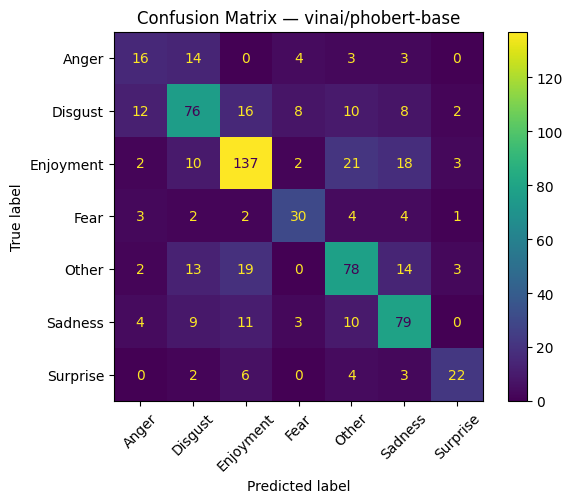

Accuracy         : 0.632
Macro F1         : 0.6067
Train time (s)   : 359.82
Inference time (s) trên toàn bộ test: 4.3011


In [ ]:
# LƯU Ý: Đây là kết quả đã chạy trên colab, nên RUN_TASK26_TRANSFORMER mới để là False, muốn chạy được thì bạn
# phải tải file lên colab, tải thư mục data lên luôn, và mượn GPU của colab ròi chỉnh thành True mới chạy dc nha.
RUN_TASK26_TRANSFORMER = False
TASK26_MODEL_NAME = "vinai/phobert-base"

def run_task26_pretrained_pipeline():
    from transformers import (
        AutoTokenizer, AutoModelForSequenceClassification,
        TrainingArguments, Trainer
    )
    from datasets import Dataset

    label_list = sorted(task3_train["emotion"].unique())
    label2id = {label: i for i, label in enumerate(label_list)}
    id2label = {i: label for label, i in label2id.items()}

    def to_hf_dataset(data):
        return Dataset.from_dict({
            "text": data["text_norm"].tolist(),
            "label": data["emotion"].map(label2id).tolist()
        })

    train_ds = to_hf_dataset(task3_train)
    validation_ds = to_hf_dataset(task3_validation)
    test_ds = to_hf_dataset(task3_test)

    tokenizer = AutoTokenizer.from_pretrained(TASK26_MODEL_NAME)

    def tokenize_function(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

    train_ds = train_ds.map(tokenize_function, batched=True)
    validation_ds = validation_ds.map(tokenize_function, batched=True)
    test_ds = test_ds.map(tokenize_function, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        TASK26_MODEL_NAME,
        num_labels=len(label_list),
        id2label=id2label,
        label2id=label2id
    )

    def compute_metrics(eval_pred):
        logits, gold_labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        _, _, macro_f1_metric, _ = precision_recall_fscore_support(
            gold_labels, preds, average="macro", zero_division=0
        )
        return {"accuracy": accuracy_score(gold_labels, preds), "macro_f1": macro_f1_metric}

    training_args = TrainingArguments(
        output_dir="./task26_phobert",
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=50,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=validation_ds,
        compute_metrics=compute_metrics,
    )

    start_train = time.perf_counter()
    trainer.train()
    train_seconds = time.perf_counter() - start_train

    start_infer = time.perf_counter()
    test_predictions = trainer.predict(test_ds)
    inference_seconds = time.perf_counter() - start_infer

    pred_ids = np.argmax(test_predictions.predictions, axis=-1)
    pred_names = [id2label[i] for i in pred_ids]

    accuracy = accuracy_score(task3_test["emotion"], pred_names)
    _, _, macro_f1_value, _ = precision_recall_fscore_support(
        task3_test["emotion"], pred_names, average="macro", zero_division=0
    )

    cm = confusion_matrix(task3_test["emotion"], pred_names, labels=label_list)
    ConfusionMatrixDisplay(cm, display_labels=label_list).plot(xticks_rotation=45)
    plt.title(f"Confusion Matrix — {TASK26_MODEL_NAME}")
    plt.show()

    print("Accuracy         :", round(accuracy, 4))
    print("Macro F1         :", round(macro_f1_value, 4))
    print("Train time (s)   :", round(train_seconds, 2))
    print("Inference time (s) trên toàn bộ test:", round(inference_seconds, 4))

    return {
        "model_name": TASK26_MODEL_NAME,
        "accuracy": accuracy,
        "macro_f1": macro_f1_value,
        "train_seconds": train_seconds,
        "inference_seconds": inference_seconds,
        "test_pred_names": pred_names,
    }

if RUN_TASK26_TRANSFORMER:
    task26_result = run_task26_pretrained_pipeline()
else:
    print(f"Pipeline fine-tune {TASK26_MODEL_NAME} đã sẵn sàng nhưng chưa chạy.")
    print("Đặt RUN_TASK26_TRANSFORMER = True sau khi cài transformers, datasets, torch")
    print("và có GPU/kết nối internet để tải pretrained model.")

**Nhận xét kết quả fine-tune PhoBERT (Task 26)**

**1. Quá trình huấn luyện**
- Training loss giảm đều qua 3 epoch (1.267 → 0.865 → 0.635), trong khi Validation loss lại tăng nhẹ rồi dao động (1.106 → 1.143 → 1.116) dù Accuracy và Macro F1 vẫn tiếp tục tăng (0.599→0.603→0.621 và 0.487→0.550→0.563).
- Đây là dấu hiệu **overfit nhẹ**: mô hình khớp tập train tốt hơn nhưng độ tự tin của xác suất dự đoán (loss) trên validation không cải thiện tương ứng, dù nhãn dự đoán cuối cùng vẫn đúng nhiều hơn.
- Nên cân nhắc `load_best_model_at_end=True` với `metric_for_best_model="macro_f1"` thay vì chọn theo loss, vì epoch 3 có F1 tốt nhất dù loss không thấp nhất.

**2. So sánh với baseline TF-IDF**
- Accuracy 0.632, Macro F1 0.6067 trên test — cải thiện rõ rệt so với các baseline TF-IDF + Naive Bayes/Logistic Regression ở các Task trước, minh chứng contextual embedding nắm ngữ nghĩa tốt hơn bag-of-words/TF-IDF.

**3. Phân tích theo từng lớp (Confusion Matrix)**
- **Enjoyment** là lớp mạnh nhất (137/193 ≈ 71% recall), phù hợp vì đây là lớp có nhiều mẫu nhất.
- **Anger** là lớp yếu nhất, chỉ đúng 16/40 (~40%), bị nhầm nhiều nhất sang **Disgust** (14 ca) — hai cảm xúc này gần nhau về ngữ nghĩa nên dễ lẫn, cần đối chiếu thêm với error analysis thủ công (Task 24) để xem ranh giới annotation giữa hai nhãn có rõ ràng không.
- **Fear** dù không nhiều mẫu vẫn đạt recall khá (30/46 ≈ 65%), có thể do từ vựng biểu đạt khá đặc trưng.
- **Other** và **Sadness** bị lẫn qua **Disgust** khá nhiều (13 và 9 ca), cho thấy ranh giới giữa "trung tính/khác" và cảm xúc tiêu cực nhẹ chưa rõ.
- **Surprise** một phần bị nhầm thành **Enjoyment** (6 ca), có thể do câu ngạc nhiên tích cực dễ lẫn với vui vẻ.

**4. Chi phí train/inference**
- Train 3 epoch mất ~360 giây, suy luận toàn bộ test mất ~4.3 giây — tốn kém hơn đáng kể so với TF-IDF + Logistic Regression (train/infer chỉ vài trăm mili-giây tới vài giây).
- Đây là dữ liệu quan trọng cần đưa vào bảng benchmark Task 25 để thể hiện rõ trade-off giữa accuracy/macro F1 và chi phí tính toán.

**Kết luận:** PhoBERT vượt trội baseline truyền thống về Macro F1/Accuracy, nhưng có dấu hiệu overfit nhẹ nên cần theo dõi thêm epoch hoặc early stopping theo F1, vẫn yếu ở các cặp lớp có ngữ nghĩa gần nhau (Anger - Disgust), và đánh đổi bằng chi phí

In [135]:
def compare_baseline_vs_pretrained(baseline_pred, pretrained_pred):
    comparison_df = pd.DataFrame({
        "text": task3_test["text"].reset_index(drop=True),
        "gold": task3_test["emotion"].reset_index(drop=True),
        "baseline_pred": pd.Series(list(baseline_pred)).reset_index(drop=True),
        "pretrained_pred": pd.Series(list(pretrained_pred)).reset_index(drop=True),
    })
    comparison_df["baseline_correct"] = comparison_df["gold"] == comparison_df["baseline_pred"]
    comparison_df["pretrained_correct"] = comparison_df["gold"] == comparison_df["pretrained_pred"]

    pretrained_wins = comparison_df[
        (~comparison_df["baseline_correct"]) & (comparison_df["pretrained_correct"])
    ]
    baseline_wins = comparison_df[
        (comparison_df["baseline_correct"]) & (~comparison_df["pretrained_correct"])
    ]

    print("Pretrained đúng, baseline sai (tối đa 10 câu):")
    display(pretrained_wins.head(10))

    print("\nBaseline đúng, pretrained sai (tối đa 10 câu):")
    display(baseline_wins.head(10))

    return comparison_df

if RUN_TASK26_TRANSFORMER:
    task26_comparison = compare_baseline_vs_pretrained(best_pred, task26_result["test_pred_names"])
else:
    print("So sánh baseline vs pretrained sẽ chạy sau khi RUN_TASK26_TRANSFORMER = True")
    print("và pipeline ở trên đã tạo ra task26_result.")

Pretrained đúng, baseline sai (tối đa 10 câu):


,text,gold,baseline_pred,pretrained_pred,baseline_correct,pretrained_correct
3,nhà thì không xa lắm nhưng chưa bao giờ đi vì ...,Fear,Sadness,Fear,False,True
10,mấy ai được như vậy ??,Other,Enjoyment,Other,False,True
20,kinh khủng thật :((,Fear,Disgust,Fear,False,True
24,trơi ơi sao lại cháy chứ,Surprise,Other,Surprise,False,True
27,per tiến cử bản thân nào,Other,Enjoyment,Other,False,True
29,per dạo này ít tung tăng hơn xưa nên hơi trầm ...,Other,Enjoyment,Other,False,True
32,nhưng tao đéo có crush,Sadness,Enjoyment,Sadness,False,True
34,tao đéo ngờ được đây là trường tao :)))),Surprise,Enjoyment,Surprise,False,True
40,trời đụ thằng con trời đánh,Anger,Disgust,Anger,False,True
44,chắc chắn bố của bạn này là một người vui tính...,Enjoyment,Other,Enjoyment,False,True



Baseline đúng, pretrained sai (tối đa 10 câu):


,text,gold,baseline_pred,pretrained_pred,baseline_correct,pretrained_correct
2,kinh vãi 😡,Disgust,Disgust,Fear,True,False
8,anh nhỏ nhẹ xin 100k rồi trước khi đi còn chào...,Other,Other,Enjoyment,True,False
12,ủa má . 2 đứa yêu nhau vô duyên và sân si giốn...,Disgust,Disgust,Surprise,True,False
16,thần kinh cái đầu mày …,Disgust,Disgust,Fear,True,False
21,hậu duệ mặt trời đấy chứ đùa đâu nhá 😗😗,Other,Other,Enjoyment,True,False
25,có những người không có ý thức bỏ quần áo rách...,Disgust,Disgust,Other,True,False
28,vẫn chọn tech là ngân hàng đồng hành,Enjoyment,Enjoyment,Other,True,False
39,phim hay thật nhưng cái kết hơi khó hiểu :v ch...,Enjoyment,Enjoyment,Sadness,True,False
41,"má , chơi dị ai chơi lại , mấy ba",Disgust,Disgust,Other,True,False
46,mặt chúng bạn kiểu lại đéo được trả tiền rồi 😞,Sadness,Sadness,Disgust,True,False


**4. So sánh khả năng giải thích.**

- **TF-IDF + Logistic Regression / Linear SVM (baseline):** mỗi feature là một từ/n-gram cụ thể, trọng số của mô hình có thể tra cứu trực tiếp để biết từ nào đẩy dự đoán về phía lớp nào (như đã làm ở Task 11). Đây là white-box, dễ giải thích cho cả người không chuyên kỹ thuật.
- **PhoBERT / ViSoBERT (pretrained, fine-tuned):** biểu diễn là các vector embedding theo ngữ cảnh qua nhiều lớp attention, không có ánh xạ trực tiếp "từ → trọng số". Muốn giải thích phải dùng thêm kỹ thuật như attention visualization, LIME/SHAP, tốn thêm chi phí tính toán và kết quả giải thích cũng chỉ mang tính xấp xỉ (approximation), không trực tiếp như hệ số hồi quy.
- **Đánh đổi:** PhoBERT/ViSoBERT thường cho accuracy/macro F1 cao hơn nhờ hiểu ngữ cảnh (phủ định, sarcasm, từ đa nghĩa), nhưng đổi lại khả năng giải thích thấp hơn nhiều so với mô hình tuyến tính trên TF-IDF.

# 27. Bài so sánh

Sinh viên phải so sánh ít nhất:

### Hệ thống A
**TF-IDF + Naive Bayes**

### Hệ thống B
**TF-IDF + Logistic Regression hoặc Linear SVM**

### Hệ thống C
**PhoBERT hoặc ViSoBERT**

Dataset gợi ý:
- UIT-VSFC
- UIT-VSMEC
- sentiment / hate speech dataset tương đương

# 28. Yêu cầu cải tiến hệ thống

Ngoài ba hệ thống bắt buộc, nhóm phải thực hiện ít nhất **3 cải tiến** trong danh sách:

- [ ] word bigram / trigram
- [ ] character n-gram
- [ ] feature thủ công
- [ ] xử lý negation
- [ ] xử lý emoji
- [ ] xử lý teencode
- [ ] class weight
- [ ] oversampling
- [ ] threshold tuning
- [ ] hyperparameter tuning
- [ ] domain adaptation experiment
- [ ] ensemble
- [ ] custom preprocessing cho tiếng Việt

Mỗi cải tiến phải có:
1. giả thuyết/lý thuyết/phát biểu bài toán
2. thay đổi cụ thể,
3. metric trước,
4. metric sau,
5. giải thích kết quả.

# 29. Bài nộp

Notebook nộp phải có:

- [ ] Mô tả bài toán và label.
- [ ] Thống kê dataset.
- [ ] Train/validation/test split rõ ràng.
- [ ] TF-IDF + Naive Bayes.
- [ ] TF-IDF + Logistic Regression hoặc SVM.
- [ ] PhoBERT / ViSoBERT hoặc pretrained model tương đương.
- [ ] Confusion Matrix.
- [ ] Accuracy, Precision, Recall, F1.
- [ ] Macro / Micro / Weighted.
- [ ] Xử lý hoặc phân tích class imbalance.
- [ ] Ít nhất 20 failure cases được phân nhóm.
- [ ] So sánh training time.
- [ ] So sánh inference time.
- [ ] So sánh khả năng giải thích.
- [ ] Ít nhất 3 cải tiến so với baseline.

# 30. Bảng kết quả đề xuất

| Hệ thống | Representation | Accuracy | Macro F1 | Train time | Inference | Explainability |
|---|---|---:|---:|---:|---:|---|
| Rule-based | Lexicon | | | | | Cao |
| NB | TF-IDF | | | | | Cao |
| Logistic | TF-IDF | | | | | Khá cao |
| Linear SVM | TF-IDF | | | | | Khá |
| Improved Traditional | ... | | | | | ... |
| PhoBERT / ViSoBERT | Contextual Embedding | | | | | Thấp hơn |

### Câu hỏi bắt buộc
1. Mô hình nào tốt nhất theo Macro F1?
2. Mô hình nào nhanh nhất?
3. Mô hình nào dễ giải thích nhất?
4. Có đáng đổi tốc độ và khả năng giải thích để lấy thêm accuracy không?
5. Mô hình nào phù hợp nhất nếu triển khai CPU?

# 31. Rubric

| Thành phần | Điểm |
|---|---:|
| Dataset + split + chống leakage | 10 |
| Text representation | 15 |
| Naive Bayes baseline | 10 |
| Logistic/SVM baseline | 10 |
| Pretrained model | 15 |
| Evaluation đúng và đầy đủ | 15 |
| Ít nhất 3 cải tiến | 10 |
| Error analysis ≥ 20 cases | 10 |
| Trình bày + kết luận | 5 |
| **Tổng** | **100** |

### Điểm cộng
- Aspect-based sentiment
- Domain adaptation
- Robustness test với teencode / typo / emoji
- Calibration / threshold tuning
- Ensemble